# 0. 라이브러리 설치 및 호출

### 0-1. 폰트 설치

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


### 0-2. 라이브러리 설치

In [ ]:
!pip install -q geopandas pyogrio shapely fiona

### 0-3. 라이브러리 호출

In [ ]:
import os
import re
import time
import requests
import warnings
from typing import Dict, List


import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm.auto import tqdm

from google.colab import drive

warnings.filterwarnings("ignore")

### 0-4. 기본 설정

##### 0-4-1. 시각화 설정

In [ ]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

!fc-cache -fv > /dev/null 2>&1

font_paths = fm.findSystemFonts(fontpaths=None, fontext="ttf")
nanum_fonts = [f for f in font_paths if "Nanum" in f or "nanum" in f]

if nanum_fonts:
    font_name = fm.FontProperties(fname=nanum_fonts[0]).get_name()
    plt.rc("font", family=font_name)
    print(f"적용된 한글 폰트: {font_name}")
else:
    print("나눔 폰트를 찾지 못했습니다. 런타임 재시작 후 다시 실행해보세요.")

plt.rcParams["axes.unicode_minus"] = False

적용된 한글 폰트: NanumSquare


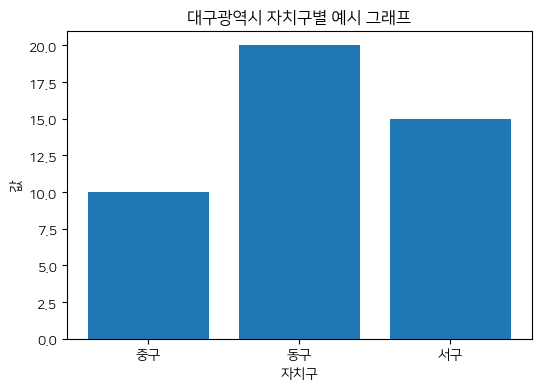

In [ ]:
plt.figure(figsize=(6, 4))
plt.title("대구광역시 자치구별 예시 그래프")
plt.bar(["중구", "동구", "서구"], [10, 20, 15])
plt.xlabel("자치구")
plt.ylabel("값")
plt.show()

##### 0-4-2. 기본 설정

In [ ]:
# 연도 목록
YEARS = list(range(2019, 2025))

# 대구 자치구 코드/이름
DAEGU_SIG_MAP = {
    "27110": "중구",
    "27140": "동구",
    "27170": "서구",
    "27200": "남구",
    "27230": "북구",
    "27260": "수성구",
    "27290": "달서구",
    "27710": "달성군",
    "27720": "군위군",
}

# 장기 비교(2019~2024)에서는 군위군 제외
DAEGU_SIG_MAP_LONG = {
    "27110": "중구",
    "27140": "동구",
    "27170": "서구",
    "27200": "남구",
    "27230": "북구",
    "27260": "수성구",
    "27290": "달서구",
    "27710": "달성군",
}

DAEGU_GU_LIST = list(DAEGU_SIG_MAP.values())
DAEGU_GU_LIST_LONG = list(DAEGU_SIG_MAP_LONG.values())

# 1. 데이터 로드

### 1-1. Google Drive 연결 및 경로 설정

In [ ]:
drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/Colab_Notebooks/data/대구"

population_path = os.path.join(base_path, "population")
crime_path = os.path.join(base_path, "crime")
cctv_path = os.path.join(base_path, "cctv")
landuse_path = os.path.join(base_path, "land")
geo_path = os.path.join(base_path, "geo")

output_path = "/content/drive/MyDrive/Colab_Notebooks/data/outputs"
os.makedirs(output_path, exist_ok=True)

print("기본 경로 설정 완료")
print("base_path:", base_path)
print("output_path:", output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
기본 경로 설정 완료
base_path: /content/drive/MyDrive/Colab_Notebooks/data/대구
output_path: /content/drive/MyDrive/Colab_Notebooks/data/outputs


### 1-2. 공통 유틸 함수

In [ ]:
def safe_read_csv(file_path: str, encodings: List[str] = None) -> pd.DataFrame:
    """
    인코딩 이슈가 있을 수 있는 CSV를 안전하게 읽기 위한 함수
    """
    if encodings is None:
        encodings = [None, "utf-8", "utf-8-sig", "cp949", "euc-kr"]

    errors = []

    for enc in encodings:
        try:
            if enc is None:
                return pd.read_csv(file_path)
            else:
                return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError as e:
            errors.append((enc, type(e).__name__, str(e)[:120]))
        except pd.errors.ParserError as e:
            errors.append((enc, type(e).__name__, str(e)[:120]))
        except Exception as e:
            errors.append((enc, type(e).__name__, str(e)[:120]))

    raise ValueError(f"파일을 읽을 수 없습니다: {file_path}\n시도 결과: {errors}")


def print_shape_summary(name: str, data_dict: Dict):
    print(f"\n[{name}]")
    for k, v in data_dict.items():
        print(f"{k}: {v.shape}")


def extract_yearly_population_columns(df: pd.DataFrame, year: int) -> List[str]:
    """
    해당 연도의 월별 총인구수 컬럼만 추출
    예: 2024년01월_총인구수 ~ 2024년12월_총인구수
    """
    pattern = rf"^{year}년\d{{2}}월_총인구수$"
    return [col for col in df.columns if re.match(pattern, col)]


def extract_admin_name(text: str) -> str:
    """
    예: '대구광역시 중구 (2711000000)' -> '중구'
    예: '대구광역시  (2700000000)' -> '대구광역시'
    """
    if pd.isna(text):
        return np.nan

    text = str(text).strip()

    if text.startswith("대구광역시 ") and "(" in text:
        core = text.split("(")[0].strip()
        core = core.replace("대구광역시", "").strip()
        return core if core else "대구광역시"

    return text

### 1-3. 인구 데이터 로드

In [ ]:
population_dfs = {}
for year in YEARS:
    file_name = f"{year}01_{year}12_주민등록인구및세대현황_월간.csv"
    file_path = os.path.join(population_path, file_name)
    population_dfs[year] = safe_read_csv(file_path, encodings=["cp949", "utf-8-sig", "utf-8"])

print_shape_summary("인구 데이터", population_dfs)


[인구 데이터]
2019: (9, 73)
2020: (9, 73)
2021: (9, 73)
2022: (9, 73)
2023: (10, 73)
2024: (10, 73)


### 1-4. 범죄 데이터 로드

In [ ]:
crime_dfs = {}
for year in YEARS:
    file_name = f"범죄발생지_{year}.csv"
    file_path = os.path.join(crime_path, file_name)
    crime_dfs[year] = safe_read_csv(file_path, encodings=["cp949", "utf-8-sig", "utf-8"])

print_shape_summary("범죄 데이터", crime_dfs)


[범죄 데이터]
2019: (50, 11)
2020: (50, 11)
2021: (50, 11)
2022: (50, 11)
2023: (50, 12)
2024: (50, 12)


### 1-5. CCTV 데이터 로드

In [ ]:
cctv_origin_path = os.path.join(base_path, "cctv_origin")

cctv_origin_files = {
    "중구":   "대구_중구.xlsx",
    "동구":   "대구_동구.xlsx",
    "서구":   "CCTV정보_대구서구.csv",
    "남구":   "대구_남구.xlsx",
    "북구":   "대구_북구.xlsx",
    "수성구": "CCTV정보_대구수성구.csv",
    "달서구": "대구_달서구.csv",
    "달성군": "대구_달성군.xlsx",
    "군위군": "대구_군위군.xlsx",
}

def read_csv_safe(file_path: str) -> pd.DataFrame:
    encodings = [None, "utf-8", "utf-8-sig", "cp949", "euc-kr"]
    errors = []

    for enc in encodings:
        try:
            if enc is None:
                return pd.read_csv(file_path)
            return pd.read_csv(file_path, encoding=enc)
        except Exception as e:
            errors.append((enc, type(e).__name__, str(e)[:120]))

    raise ValueError(f"CSV 파일을 읽을 수 없습니다: {file_path}\n시도 결과: {errors}")

def read_excel_safe(file_path: str) -> pd.DataFrame:
    try:
        return pd.read_excel(file_path)
    except Exception as e:
        raise ValueError(f"Excel 파일을 읽을 수 없습니다: {file_path}\n에러: {e}")

def load_cctv_origin(file_path: str) -> pd.DataFrame:
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        return read_csv_safe(file_path)
    elif ext in [".xlsx", ".xls"]:
        return read_excel_safe(file_path)
    else:
        raise ValueError(f"지원하지 않는 파일 형식입니다: {file_path}")

# 원본 CCTV 로드
cctv_origin_dfs = {}
for gu, file_name in cctv_origin_files.items():
    file_path = os.path.join(cctv_origin_path, file_name)
    cctv_origin_dfs[gu] = load_cctv_origin(file_path)

# 이후 기존 코드와 호환되도록 cctv_dfs에 덮어쓰기
cctv_dfs = cctv_origin_dfs.copy()

print("[CCTV 원본 데이터 shape]")
for gu, df in cctv_dfs.items():
    print(f"{gu}: {df.shape}")

[CCTV 원본 데이터 shape]
중구: (2280, 4)
동구: (2910, 4)
서구: (5249, 16)
남구: (2424, 12)
북구: (2706, 13)
수성구: (3017, 16)
달서구: (2900, 14)
달성군: (2556, 10)
군위군: (443, 3)


### 1-6. 용도지역 데이터 로드

In [ ]:
landuse_dfs = {}
for year in YEARS:
    file_name = f"대구 용도지역 현황_{year}.csv"
    file_path = os.path.join(landuse_path, file_name)
    landuse_dfs[year] = safe_read_csv(file_path, encodings=["cp949", "utf-8-sig", "utf-8"])

print_shape_summary("용도지역 데이터", landuse_dfs)


[용도지역 데이터]
2019: (21, 11)
2020: (21, 11)
2021: (21, 11)
2022: (21, 11)
2023: (22, 12)
2024: (21, 12)


### 1-7. 법정구역 경계 데이터 로드

In [ ]:
geo_file_map = {
    2019: "AL_00_D001_20191207/AL_00_D001_20191207(SIG)/AL_00_D001_20191207(SIG).shp",
    2020: "AL_00_D001_20201205/AL_00_D001_20201205(SIG)/AL_00_D001_20201205(SIG).shp",
    2021: "AL_00_D001_20211204/AL_00_D001_20211204(SIG)/AL_00_D001_20211204(SIG).shp",
    2022: "AL_00_D001_20221203/AL_00_D001_20221203(SIG)/AL_00_D001_20221203(SIG).shp",
    2023: "AL_D001_00_20231204/AL_D001_00_20231204(SIG)/AL_D001_00_20231204(SIG).shp",
    2024: "AL_D001_00_20241204/AL_D001_00_20241204(SIG)/AL_D001_00_20241204(SIG).shp",
}

geo_dfs = {}
for year, rel_path in geo_file_map.items():
    file_path = os.path.join(geo_path, rel_path)
    geo_dfs[year] = gpd.read_file(file_path, encoding="cp949")

print_shape_summary("법정구역 경계 데이터", geo_dfs)


[법정구역 경계 데이터]
2019: (257, 5)
2020: (281, 5)
2021: (252, 5)
2022: (252, 5)
2023: (250, 6)
2024: (282, 6)


### 1-8. 편의용 별칭(핵심 분석 중심 연도: 2024)

In [ ]:
pop = population_dfs[2024]
crime = crime_dfs[2024]
landuse = landuse_dfs[2024]
shp2024 = geo_dfs[2024]

print("2024년 대표 데이터 별칭 생성 완료")

2024년 대표 데이터 별칭 생성 완료


# 2. 데이터 탐색

### 2-1. 전체 구조 확인

##### 2-1-1. 데이터 탐색

In [ ]:
print("\n[인구 데이터 2024]")
display(pop.head())

print("\n[범죄 데이터 2024]")
display(crime.head(10))

print("\n[CCTV 데이터 - 중구 예시]")
display(cctv_dfs["중구"].head())

print("\n[용도지역 데이터 2024]")
display(landuse.head())

print("\n[법정경계 데이터 2024]")
display(shp2024.head())


[인구 데이터 2024]


,행정구역,2024년01월_총인구수,2024년01월_세대수,2024년01월_세대당 인구,2024년01월_남자 인구수,2024년01월_여자 인구수,2024년01월_남여 비율,2024년02월_총인구수,2024년02월_세대수,2024년02월_세대당 인구,2024년02월_남자 인구수,2024년02월_여자 인구수,2024년02월_남여 비율,2024년03월_총인구수,2024년03월_세대수,2024년03월_세대당 인구,2024년03월_남자 인구수,2024년03월_여자 인구수,2024년03월_남여 비율,2024년04월_총인구수,2024년04월_세대수,2024년04월_세대당 인구,2024년04월_남자 인구수,2024년04월_여자 인구수,2024년04월_남여 비율,2024년05월_총인구수,2024년05월_세대수,2024년05월_세대당 인구,2024년05월_남자 인구수,2024년05월_여자 인구수,2024년05월_남여 비율,2024년06월_총인구수,2024년06월_세대수,2024년06월_세대당 인구,2024년06월_남자 인구수,2024년06월_여자 인구수,2024년06월_남여 비율,2024년07월_총인구수,2024년07월_세대수,2024년07월_세대당 인구,2024년07월_남자 인구수,2024년07월_여자 인구수,2024년07월_남여 비율,2024년08월_총인구수,2024년08월_세대수,2024년08월_세대당 인구,2024년08월_남자 인구수,2024년08월_여자 인구수,2024년08월_남여 비율,2024년09월_총인구수,2024년09월_세대수,2024년09월_세대당 인구,2024년09월_남자 인구수,2024년09월_여자 인구수,2024년09월_남여 비율,2024년10월_총인구수,2024년10월_세대수,2024년10월_세대당 인구,2024년10월_남자 인구수,2024년10월_여자 인구수,2024년10월_남여 비율,2024년11월_총인구수,2024년11월_세대수,2024년11월_세대당 인구,2024년11월_남자 인구수,2024년11월_여자 인구수,2024년11월_남여 비율,2024년12월_총인구수,2024년12월_세대수,2024년12월_세대당 인구,2024년12월_남자 인구수,2024년12월_여자 인구수,2024년12월_남여 비율
0,대구광역시 (2700000000),"2,373,844","1,094,529",2.17,"1,166,110","1,207,734",0.97,"2,372,008","1,095,812",2.16,"1,165,024","1,206,984",0.97,"2,369,962","1,097,169",2.16,"1,163,911","1,206,051",0.97,"2,368,670","1,098,201",2.16,"1,163,001","1,205,669",0.96,"2,367,803","1,099,465",2.15,"1,162,463","1,205,340",0.96,"2,367,183","1,100,317",2.15,"1,162,046","1,205,137",0.96,"2,366,660","1,101,110",2.15,"1,161,549","1,205,111",0.96,"2,366,033","1,101,929",2.15,"1,161,164","1,204,869",0.96,"2,365,523","1,102,902",2.14,"1,160,812","1,204,711",0.96,"2,364,892","1,103,045",2.14,"1,160,429","1,204,463",0.96,"2,364,334","1,103,350",2.14,"1,160,074","1,204,260",0.96,"2,363,629","1,104,130",2.14,"1,159,601","1,204,028",0.96
1,대구광역시 중구 (2711000000),"89,685","45,209",1.98,"42,950","46,735",0.92,"90,242","45,516",1.98,"43,241","47,001",0.92,"90,561","45,765",1.98,"43,346","47,215",0.92,"90,953","45,964",1.98,"43,522","47,431",0.92,"91,902","46,352",1.98,"43,983","47,919",0.92,"92,659","46,666",1.99,"44,349","48,310",0.92,"93,338","46,963",1.99,"44,677","48,661",0.92,"94,087","47,259",1.99,"45,046","49,041",0.92,"94,808","47,578",1.99,"45,385","49,423",0.92,"95,749","47,940",2.00,"45,830","49,919",0.92,"96,757","48,345",2.00,"46,349","50,408",0.92,"97,711","48,786",2.00,"46,789","50,922",0.92
2,대구광역시 동구 (2714000000),"342,703","162,840",2.10,"167,899","174,804",0.96,"342,161","162,923",2.10,"167,601","174,560",0.96,"341,918","162,995",2.10,"167,481","174,437",0.96,"342,302","163,393",2.09,"167,637","174,665",0.96,"342,874","163,943",2.09,"167,932","174,942",0.96,"343,248","164,334",2.09,"168,160","175,088",0.96,"343,392","164,495",2.09,"168,181","175,211",0.96,"343,463","164,783",2.08,"168,153","175,310",0.96,"343,398","164,950",2.08,"168,106","175,292",0.96,"343,137","164,867",2.08,"167,914","175,223",0.96,"342,777","164,776",2.08,"167,704","175,073",0.96,"342,339","164,806",2.08,"167,438","174,901",0.96
3,대구광역시 서구 (2717000000),"164,513","84,189",1.95,"81,686","82,827",0.99,"164,734","84,366",1.95,"81,758","82,976",0.99,"164,457","84,361",1.95,"81,595","82,862",0.98,"164,069","84,251",1.95,"81,387","82,682",0.98,"163,606","84,125",1.94,"81,196","82,410",0.99,"163,359","84,068",1.94,"81,083","82,276",0.99,"162,903","83,913",1.94,"80,819","82,084",0.98,"162,557","83,813",1.94,"80,676","81,881",0.99,"163,463","84,290",1.94,"81,131","82,332",0.99,"163,741","84,448",1.94,"81,225","82,516",0.98,"163,545","84,393",1.94,"81,103","82,442",0.98,"163,135","84,268",1.94,"80,882","82,253",0.98
4,대구광역시 남구 (2720000000),"138,806","75,729",1.83,"66,319","72,487",0.91,"138,480","75,685",1.83,"66,148","72,332",0.91,"138,140","75,669",1.83,"65,948","72,192",0.91,"137,566","75,443",1.82,"65,656","71,910",0.91,"137,147","75,333",1.82,"65,471","71,676",0.91,"136,893","75,300",1.82,"65,312","71,581",0.91,"136,582","75,213",1.82,"65,175","71,407",0.91,"136,311","75,101",1.82,"65,055","71,256",0.91,"135,957"


[범죄 데이터 2024]


,범죄별(1),범죄별(2),범죄별(3),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군,군위군
2,형법범,재산범죄,절도,1188,1272,1025,681,1553,991,1963,911,93
3,형법범,재산범죄,장물,1,-,-,-,3,3,3,2,-
4,형법범,재산범죄,사기,1234,2657,1396,1412,3051,3586,4309,1277,99
5,형법범,재산범죄,횡령,337,661,237,176,349,417,423,230,11
6,형법범,재산범죄,배임,14,24,12,6,10,27,28,21,2
7,형법범,재산범죄,손괴,199,387,218,190,326,308,420,150,20
8,형법범,강력범죄(흉악),살인,2,4,3,-,4,8,8,4,-
9,형법범,강력범죄(흉악),강도,1,10,2,-,2,-,1,-,-



[CCTV 데이터 - 중구 예시]


,순번,부서명,목적,카메라 설치위치
0,1,안전총괄과,생활안전,동성로2길 45
1,2,안전총괄과,생활안전,공평로 31
2,3,안전총괄과,생활안전,동성로3길 84
3,4,안전총괄과,생활안전,달구벌대로447길 72-1
4,5,안전총괄과,생활안전,남성로 50



[용도지역 데이터 2024]


,구분,상세구분,대구(m2),중구(m2),동구(m2),서구(m2),남구(m2),북구(m2),수성구(m2),달서구(m2),달성군(m2),군위군(m2)
0,주거지역,제1종전용주거지역,289865.0,0,102290.0,0,0,164911,0,2648.0,20016.0,0
1,주거지역,제2종전용주거지역,276532.0,0,20748.0,0,0,43981,0,0.0,211803.0,0
2,주거지역,제1종일반주거지역,26918358.6,66328,4632745.0,177890,2032844,3322957,6788687,4362594.6,4843067.0,691246
3,주거지역,제2종일반주거지역,46317078.3,1323249,5336087.3,5404557,4889507,7999853,5757164,7278161.0,8049418.0,279082
4,주거지역,제3종일반주거지역,33552608.4,1550257,5531515.0,1542806,1142114,6980795,5463191,7967975.4,3373955.0,0



[법정경계 데이터 2024]


,A0,A1,A2,A3,A4,geometry
0,57613,11110,종로구,2024-12-01,11110,"POLYGON ((197747.184 559404.315, 197816.14 559398.618, 197831.621 559391.145, 197898.659 559371.19, 197871.867 559310.198, 197836.176 559157.274, 197861.275 559070.751, 197969.531 559077.49, 19816..."
1,57288,11140,중구,2024-12-01,11140,"POLYGON ((199180.554 552312.131, 199200.913 552313.258, 199227.577 552316.478, 199265.63 552320.578, 199264.69 552306.199, 199268.46 552306.731, 199268.311 552321.107, 199299.183 552325.035, 19932..."
2,57292,11170,용산구,2024-12-01,11170,"POLYGON ((195172.982 548501.4, 195174.938 548504.694, 195182.727 548517.376, 195186.982 548524.414, 195190.908 548530.82, 195196.617 548540.195, 195201.741 548548.62, 195204.044 548552.349, 195204..."
3,56974,11200,성동구,2024-12-01,11200,"POLYGON ((202436.417 551969.825, 202411.174 551971.005, 202391.183 551971.997, 202369.625 551973.012, 202349.761 551973.924, 202330.781 551974.783, 202310.761 551975.774, 202289.753 551976.791, 20..."
4,40654,11215,광진구,2024-12-01,11215,"POLYGON ((206870.48 547252.451, 206638.541 547291.297, 206438.005 547352.089, 206138.601 547402.408, 206031.846 547482.832, 205852.93 547533.795, 205638.657 547635.899, 205401.311 547752.004, 2051..."


##### 2-1-2. 칼럼명 확인

In [ ]:
print("\n[인구 컬럼]")
print(pop.columns.tolist())

print("\n[범죄 컬럼]")
print(crime.columns.tolist())

print("\n[CCTV 중구 컬럼]")
print(cctv_dfs["중구"].columns.tolist())

print("\n[용도지역 컬럼]")
print(landuse.columns.tolist())

print("\n[법정경계 컬럼]")
print(shp2024.columns.tolist())


[인구 컬럼]
['행정구역', '2024년01월_총인구수', '2024년01월_세대수', '2024년01월_세대당 인구', '2024년01월_남자 인구수', '2024년01월_여자 인구수', '2024년01월_남여 비율', '2024년02월_총인구수', '2024년02월_세대수', '2024년02월_세대당 인구', '2024년02월_남자 인구수', '2024년02월_여자 인구수', '2024년02월_남여 비율', '2024년03월_총인구수', '2024년03월_세대수', '2024년03월_세대당 인구', '2024년03월_남자 인구수', '2024년03월_여자 인구수', '2024년03월_남여 비율', '2024년04월_총인구수', '2024년04월_세대수', '2024년04월_세대당 인구', '2024년04월_남자 인구수', '2024년04월_여자 인구수', '2024년04월_남여 비율', '2024년05월_총인구수', '2024년05월_세대수', '2024년05월_세대당 인구', '2024년05월_남자 인구수', '2024년05월_여자 인구수', '2024년05월_남여 비율', '2024년06월_총인구수', '2024년06월_세대수', '2024년06월_세대당 인구', '2024년06월_남자 인구수', '2024년06월_여자 인구수', '2024년06월_남여 비율', '2024년07월_총인구수', '2024년07월_세대수', '2024년07월_세대당 인구', '2024년07월_남자 인구수', '2024년07월_여자 인구수', '2024년07월_남여 비율', '2024년08월_총인구수', '2024년08월_세대수', '2024년08월_세대당 인구', '2024년08월_남자 인구수', '2024년08월_여자 인구수', '2024년08월_남여 비율', '2024년09월_총인구수', '2024년09월_세대수', '2024년09월_세대당 인구', '2024년09월_남자 인구수', '2024년09월_여자 인구수', '2024년09월_남여 비율', '2024년10월_

### 2-2. 인구 데이터 탐색

##### 2-2-1. 인구 데이터 탐색

In [ ]:
for year in YEARS:
    temp = population_dfs[year].copy()
    temp["행정구역_정리"] = temp["행정구역"].apply(extract_admin_name)
    pop_cols = extract_yearly_population_columns(temp, year)

    print(f"\n===== 인구 데이터 점검: {year} =====")
    print("shape:", temp.shape)
    print("행정구역 예시:", temp["행정구역"].head(10).tolist())
    print("정리된 행정구역 예시:", temp["행정구역_정리"].head(10).tolist())
    print("월별 총인구수 컬럼 수:", len(pop_cols))
    print("월별 총인구수 컬럼:", pop_cols[:3], "...", pop_cols[-3:] if len(pop_cols) >= 3 else pop_cols)


===== 인구 데이터 점검: 2019 =====
shape: (9, 74)
행정구역 예시: ['대구광역시  (2700000000)', '대구광역시 중구 (2711000000)', '대구광역시 동구 (2714000000)', '대구광역시 서구 (2717000000)', '대구광역시 남구 (2720000000)', '대구광역시 북구 (2723000000)', '대구광역시 수성구 (2726000000)', '대구광역시 달서구 (2729000000)', '대구광역시 달성군 (2771000000)']
정리된 행정구역 예시: ['대구광역시', '중구', '동구', '서구', '남구', '북구', '수성구', '달서구', '달성군']
월별 총인구수 컬럼 수: 12
월별 총인구수 컬럼: ['2019년01월_총인구수', '2019년02월_총인구수', '2019년03월_총인구수'] ... ['2019년10월_총인구수', '2019년11월_총인구수', '2019년12월_총인구수']

===== 인구 데이터 점검: 2020 =====
shape: (9, 74)
행정구역 예시: ['대구광역시  (2700000000)', '대구광역시 중구 (2711000000)', '대구광역시 동구 (2714000000)', '대구광역시 서구 (2717000000)', '대구광역시 남구 (2720000000)', '대구광역시 북구 (2723000000)', '대구광역시 수성구 (2726000000)', '대구광역시 달서구 (2729000000)', '대구광역시 달성군 (2771000000)']
정리된 행정구역 예시: ['대구광역시', '중구', '동구', '서구', '남구', '북구', '수성구', '달서구', '달성군']
월별 총인구수 컬럼 수: 12
월별 총인구수 컬럼: ['2020년01월_총인구수', '2020년02월_총인구수', '2020년03월_총인구수'] ... ['2020년10월_총인구수', '2020년11월_총인구수', '2020년12월_총인구수']

===== 인구 데이터 점검: 

##### 2-2-2. 2024년 인구 데이터에서 대구 전체/자치구 확인

In [ ]:
pop_2024_check = pop.copy()
pop_2024_check["행정구역_정리"] = pop_2024_check["행정구역"].apply(extract_admin_name)

print("\n[2024 인구 데이터 - 정리된 행정구역 목록]")
display(pop_2024_check[["행정구역", "행정구역_정리"]].head(15))


[2024 인구 데이터 - 정리된 행정구역 목록]


,행정구역,행정구역_정리
0,대구광역시 (2700000000),대구광역시
1,대구광역시 중구 (2711000000),중구
2,대구광역시 동구 (2714000000),동구
3,대구광역시 서구 (2717000000),서구
4,대구광역시 남구 (2720000000),남구
5,대구광역시 북구 (2723000000),북구
6,대구광역시 수성구 (2726000000),수성구
7,대구광역시 달서구 (2729000000),달서구
8,대구광역시 달성군 (2771000000),달성군
9,대구광역시 군위군 (2772000000),군위군


##### 2-2-3. 2024년 월별 총인구수 칼럼 확인 및 숫자형 변환 가능성 탐색

In [ ]:
pop_2024_total_cols = extract_yearly_population_columns(pop, 2024)
print("2024 총인구수 컬럼:", pop_2024_total_cols)

pop_numeric_preview = pop[["행정구역"] + pop_2024_total_cols[:3]].copy()
display(pop_numeric_preview.head())

for col in pop_2024_total_cols[:3]:
    print(f"{col} dtype:", pop[col].dtype)

2024 총인구수 컬럼: ['2024년01월_총인구수', '2024년02월_총인구수', '2024년03월_총인구수', '2024년04월_총인구수', '2024년05월_총인구수', '2024년06월_총인구수', '2024년07월_총인구수', '2024년08월_총인구수', '2024년09월_총인구수', '2024년10월_총인구수', '2024년11월_총인구수', '2024년12월_총인구수']


,행정구역,2024년01월_총인구수,2024년02월_총인구수,2024년03월_총인구수
0,대구광역시 (2700000000),"2,373,844","2,372,008","2,369,962"
1,대구광역시 중구 (2711000000),"89,685","90,242","90,561"
2,대구광역시 동구 (2714000000),"342,703","342,161","341,918"
3,대구광역시 서구 (2717000000),"164,513","164,734","164,457"
4,대구광역시 남구 (2720000000),"138,806","138,480","138,140"


2024년01월_총인구수 dtype: object
2024년02월_총인구수 dtype: object
2024년03월_총인구수 dtype: object


### 2-3. 범죄 데이터 탐색

##### 2-3-1. 범죄 데이터 탐색

In [ ]:
for year in YEARS:
    temp = crime_dfs[year]
    print(f"\n===== 범죄 데이터 점검: {year} =====")
    print("shape:", temp.shape)
    display(temp.head(5))


===== 범죄 데이터 점검: 2019 =====
shape: (50, 11)


,범죄별(1),범죄별(2),범죄별(3),2019,2019.1,2019.2,2019.3,2019.4,2019.5,2019.6,2019.7
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군
2,형법범,재산범죄,절도,1482,1265,689,726,1340,1099,2058,631
3,형법범,재산범죄,장물,4,3,-,1,1,1,5,3
4,형법범,재산범죄,사기,1192,2322,1223,1125,2328,2695,3541,821



===== 범죄 데이터 점검: 2020 =====
shape: (50, 11)


,범죄별(1),범죄별(2),범죄별(3),2020,2020.1,2020.2,2020.3,2020.4,2020.5,2020.6,2020.7
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군
2,형법범,재산범죄,절도,1214,1224,747,679,1439,1008,1867,524
3,형법범,재산범죄,장물,3,2,2,4,6,2,2,1
4,형법범,재산범죄,사기,1344,2553,1291,1184,2293,2967,4362,1140



===== 범죄 데이터 점검: 2021 =====
shape: (50, 11)


...

,범죄별(1),범죄별(2),범죄별(3),2022,2022.1,2022.2,2022.3,2022.4,2022.5,2022.6,2022.7
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군
2,형법범,재산범죄,절도,1223,1150,1279,699,1531,1166,2030,748
3,형법범,재산범죄,장물,1,4,1,1,2,4,-,1
4,형법범,재산범죄,사기,1194,2605,930,913,2241,2240,3703,1175



===== 범죄 데이터 점검: 2023 =====
shape: (50, 12)


,범죄별(1),범죄별(2),범죄별(3),2023,2023.1,2023.2,2023.3,2023.4,2023.5,2023.6,2023.7,2023.8
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군,군위군
2,형법범,재산범죄,절도,1235,1543,867,656,1641,1142,2064,713,16
3,형법범,재산범죄,장물,2,1,1,1,1,-,2,-,-
4,형법범,재산범죄,사기,1198,2465,1386,950,2656,2545,4012,1130,35



===== 범죄 데이터 점검: 2024 =====
shape: (50, 12)


,범죄별(1),범죄별(2),범죄별(3),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군,군위군
2,형법범,재산범죄,절도,1188,1272,1025,681,1553,991,1963,911,93
3,형법범,재산범죄,장물,1,-,-,-,3,3,3,2,-
4,형법범,재산범죄,사기,1234,2657,1396,1412,3051,3586,4309,1277,99


##### 2-3-2. 2024 범죄 데이터의 상단 구조 확인

In [ ]:
print("\n[범죄 데이터 상단 구조 확인]")
display(crime.iloc[:10, :12])


[범죄 데이터 상단 구조 확인]


,범죄별(1),범죄별(2),범죄별(3),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구,대구
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군,군위군
2,형법범,재산범죄,절도,1188,1272,1025,681,1553,991,1963,911,93
3,형법범,재산범죄,장물,1,-,-,-,3,3,3,2,-
4,형법범,재산범죄,사기,1234,2657,1396,1412,3051,3586,4309,1277,99
5,형법범,재산범죄,횡령,337,661,237,176,349,417,423,230,11
6,형법범,재산범죄,배임,14,24,12,6,10,27,28,21,2
7,형법범,재산범죄,손괴,199,387,218,190,326,308,420,150,20
8,형법범,강력범죄(흉악),살인,2,4,3,-,4,8,8,4,-
9,형법범,강력범죄(흉악),강도,1,10,2,-,2,-,1,-,-


##### 2-3-3. 2024 범죄 데이터에서 첫 두 행 별도 확인

In [ ]:
print("\n[범죄 데이터 1행]")
display(crime.iloc[[0]])

print("\n[범죄 데이터 2행]")
display(crime.iloc[[1]])


[범죄 데이터 1행]


,범죄별(1),범죄별(2),범죄별(3),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8
0,범죄별(1),범죄별(2),범죄별(3),대구,대구,대구,대구,대구,대구,대구,대구,대구



[범죄 데이터 2행]


,범죄별(1),범죄별(2),범죄별(3),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8
1,범죄별(1),범죄별(2),범죄별(3),중구,동구,서구,남구,북구,수성,달서,달성군,군위군


##### 2-3-4. 2024 범죄 데이터에서 자치구 헤더 후보 확인

In [ ]:
print("\n[범죄 데이터 2024 - 컬럼별 상위 3행 확인]")
crime_header_check = pd.DataFrame({
    "col_name": crime.columns,
    "row0": crime.iloc[0].values,
    "row1": crime.iloc[1].values,
})
display(crime_header_check)


[범죄 데이터 2024 - 컬럼별 상위 3행 확인]


,col_name,row0,row1
0,범죄별(1),범죄별(1),범죄별(1)
1,범죄별(2),범죄별(2),범죄별(2)
2,범죄별(3),범죄별(3),범죄별(3)
3,2024,대구,중구
4,2024.1,대구,동구
5,2024.2,대구,서구
6,2024.3,대구,남구
7,2024.4,대구,북구
8,2024.5,대구,수성
9,2024.6,대구,달서


##### 2-3-5. 범죄 소분류(범죄별(3)) 후보 확인

In [ ]:
third_col = crime.columns[2]
print("3번째 컬럼명:", third_col)
print("\n[범죄 소분류 예시]")
display(crime[[crime.columns[0], crime.columns[1], crime.columns[2]]].head(30))

3번째 컬럼명: 범죄별(3)

[범죄 소분류 예시]


,범죄별(1),범죄별(2),범죄별(3)
0,범죄별(1),범죄별(2),범죄별(3)
1,범죄별(1),범죄별(2),범죄별(3)
2,형법범,재산범죄,절도
3,형법범,재산범죄,장물
4,형법범,재산범죄,사기
5,형법범,재산범죄,횡령
6,형법범,재산범죄,배임
7,형법범,재산범죄,손괴
8,형법범,강력범죄(흉악),살인
9,형법범,강력범죄(흉악),강도


### 2-4. CCTV 데이터 탐색

##### 2-4-0. 보조 함수 및 칼럼 후보 정의

In [ ]:
def clean_numeric_series(series: pd.Series) -> pd.Series:
    """
    문자열/숫자 혼합 컬럼을 안전하게 숫자형으로 변환
    """
    s = series.copy()
    s = s.astype("string").str.strip()
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA,
        "-": pd.NA
    })
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def extract_install_year(series: pd.Series) -> pd.Series:
    """
    설치연도/설치일/설치년월 등에서 연도만 추출
    """
    s = series.astype("string").str.strip()
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA,
        "-": pd.NA
    })

    # 1차: 숫자형 그대로 시도
    num = pd.to_numeric(s, errors="coerce")
    year_num = num.where(num.between(1900, 2100), pd.NA)

    # 2차: 문자열 내 4자리 연도 추출
    year_str = s.str.extract(r"(19\d{2}|20\d{2})", expand=False)
    year_str = pd.to_numeric(year_str, errors="coerce")

    return year_num.fillna(year_str)

def normalize_text_series(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA,
        "-": pd.NA
    })
    return s

def find_existing_cols(df: pd.DataFrame, candidates: list[str]) -> list[str]:
    return [c for c in candidates if c in df.columns]

def coalesce_series(df: pd.DataFrame, candidates: list[str]) -> pd.Series:
    """
    여러 후보 컬럼 중 존재하는 컬럼을 왼쪽부터 우선 사용
    """
    found = [c for c in candidates if c in df.columns]

    if not found:
        return pd.Series([pd.NA] * len(df), index=df.index, dtype="object")

    out = df[found[0]].copy()
    for c in found[1:]:
        out = out.where(out.notna() & (out.astype("string").str.strip() != ""), df[c])

    return out

CCTV_FIELD_CANDIDATES = {
    "소재지": [
        "카메라 설치위치",
        "설치장소(도로명주소)",
        "소재지도로명주소",
        "소재지지번주소",
        "카메라 설치위치 ",
        "주소",
    ],
    "설치목적구분": [
        "설치목적구분", "설치목적", "설치 목적", "설치목적", "목적", "용도"
    ],
    "카메라수": [
        "카메라수", "카메라대수", "카메라 대수"
    ],
    "설치연도": [
        "설치연도", "설치년도", "설치연월", "설치년월", "설치일자", "설치일", "설치년", "설치연월"
    ],
    "위도": [
        "위도", "WGS84위도", "Latitude", "latitude", "lat"
    ],
    "경도": [
        "경도", "WGS84경도", "Longitude", "longitude", "lon", "lng"
    ],
}

##### 2-4-1. 자치구별 CCTV 데이터 기본 구조 확인

In [ ]:
for gu, df in cctv_dfs.items():
    print(f"\n===== CCTV 데이터 점검: {gu} =====")
    print("shape:", df.shape)
    display(df.head(3))


===== CCTV 데이터 점검: 중구 =====
shape: (2280, 4)


,순번,부서명,목적,카메라 설치위치
0,1,안전총괄과,생활안전,동성로2길 45
1,2,안전총괄과,생활안전,공평로 31
2,3,안전총괄과,생활안전,동성로3길 84



===== CCTV 데이터 점검: 동구 =====
shape: (2910, 4)


,설치목적,설치장소(도로명주소),설치연도,시스템 설치장소
0,청사방호,건물옆 주차장,2008,가족지원과
1,청사방호,건물옆 주차장,2008,가족지원과
2,청사방호,지하1층 서편 출입구 외벽,2008,가족지원과



===== CCTV 데이터 점검: 서구 =====
shape: (5249, 16)


...

,위도,경도,관리기관명,소재지도로명주소,소재지지번주소,설치목적구분,카메라대수,카메라화소수,촬영방면정보,보관일수,설치연도,관리기관전화번호,관리부서,기준일자
0,35.857225,128.571289,대구광역시 달서구청,대구광역시 달서구 두류남길 60,대구광역시 달서구 두류동 804-141,생활안전,1,200,회전,30,2015,053-667-3900,디지털정보과,2025-05-27
1,35.839547,128.529792,대구광역시 달서구청,대구광역시 달서구 본리서3길 5,대구광역시 달서구 본리동 1210-1,생활안전,1,200,회전,30,2015,053-667-3900,디지털정보과,2025-05-27
2,35.851494,128.488028,대구광역시 달서구청,대구광역시 달서구 호산동로36북길 60,대구광역시 달서구 호산동 357-41,생활안전,1,200,회전,30,2023,053-667-3900,디지털정보과,2025-05-27



===== CCTV 데이터 점검: 달성군 =====
shape: (2556, 10)


,연번,CCTV No,구군,부서명,설치년도,설치일,용도,화소수\n(단위: 만 화소),카메라 설치위치,관제 여부
0,1,80001.0,달성군,정보통신과,2016,11.25,차번,280.0,가창면 삼산리 281-2,O
1,2,80002.0,달성군,정보통신과,2016,11.25,차번,280.0,가창면 삼산리 281-2,O
2,3,80003.0,달성군,정보통신과,2023,5,차번,200.0,가창면 용계리 27-9,O



===== CCTV 데이터 점검: 군위군 =====
shape: (443, 3)


,설치목적구분,주소,카메라대수
0,차량방범,대구광역시 군위군 군위읍 무성리 1064-5,1
1,차량방범,대구광역시 군위군 군위읍 정리 1143-7,1
2,차량방범,대구광역시 군위군 군위읍 동부리 106-8,2


##### 2-4-2. CCTV 칼럼 비교

In [ ]:
cctv_col_summary = pd.DataFrame({
    gu: pd.Series(df.columns.tolist()) for gu, df in cctv_dfs.items()
})

print("[CCTV 원본 자치구별 컬럼 비교]")
display(cctv_col_summary)

[CCTV 원본 자치구별 컬럼 비교]


,중구,동구,서구,남구,북구,수성구,달서구,달성군,군위군
0,순번,설치목적,개방자치단체코드,연번,연번,개방자치단체코드,위도,연번,설치목적구분
1,부서명,설치장소(도로명주소),관리번호,CCTV No,부서명,관리번호,경도,CCTV No,주소
2,목적,설치연도,관리기관명,구군,설치연도,관리기관명,관리기관명,구군,카메라대수
3,카메라 설치위치,시스템 설치장소,소재지도로명주소,부서명,설치일자,소재지도로명주소,소재지도로명주소,부서명,NaN
4,NaN,NaN,소재지지번주소,설치년도,용도,소재지지번주소,소재지지번주소,설치년도,NaN
5,NaN,NaN,설치목적구분,용도,화소수,설치목적구분,설치목적구분,설치일,NaN
6,NaN,NaN,카메라대수,화소수,전송회선,카메라대수,카메라대수,용도,NaN
7,NaN,NaN,카메라화소수,전송회선,카메라 설치위치,카메라화소수,카메라화소수,화소수\n(단위: 만 화소),NaN
8,NaN,NaN,촬영방면정보,카메라 설치위치,Unnamed: 8,촬영방면정보,촬영방면정보,카메라 설치위치,NaN
9,NaN,NaN,보관일수,시스템 설치장소,촬영범위,보관일수,보관일수,관제 여부,NaN


##### 2-4-3. CCTV 핵심 칼럼 존재 여부 확인

In [ ]:
mapping_rows = []

for gu, df in cctv_dfs.items():
    row = {"자치구": gu, "shape": df.shape}
    for std_col, candidates in CCTV_FIELD_CANDIDATES.items():
        found = find_existing_cols(df, candidates)
        row[std_col] = ", ".join(found) if found else None
    mapping_rows.append(row)

cctv_mapping_summary_df = pd.DataFrame(mapping_rows)

print("[CCTV 의미 기준 컬럼 매핑 요약]")
display(cctv_mapping_summary_df)

[CCTV 의미 기준 컬럼 매핑 요약]


,자치구,shape,소재지,설치목적구분,카메라수,설치연도,위도,경도
0,중구,"(2280, 4)",카메라 설치위치,목적,None,None,None,None
1,동구,"(2910, 4)",설치장소(도로명주소),"설치목적, 설치목적",None,설치연도,None,None
2,서구,"(5249, 16)","소재지도로명주소, 소재지지번주소",설치목적구분,카메라대수,"설치연월, 설치연월",WGS84위도,WGS84경도
3,남구,"(2424, 12)",카메라 설치위치,용도,None,설치년도,None,None
4,북구,"(2706, 13)",카메라 설치위치,용도,None,"설치연도, 설치일자",None,None
5,수성구,"(3017, 16)","소재지도로명주소, 소재지지번주소",설치목적구분,카메라대수,"설치연월, 설치연월",WGS84위도,WGS84경도
6,달서구,"(2900, 14)","소재지도로명주소, 소재지지번주소",설치목적구분,카메라대수,설치연도,위도,경도
7,달성군,"(2556, 10)",카메라 설치위치,용도,None,"설치년도, 설치일",None,None
8,군위군,"(443, 3)",주소,설치목적구분,카메라대수,None,None,None


##### 2-4-4. CCTV 설치목적구분 고유값 확인

In [ ]:
purpose_rows = []

for gu, df in cctv_dfs.items():
    purpose_raw = coalesce_series(df, CCTV_FIELD_CANDIDATES["설치목적구분"])
    purpose_raw = normalize_text_series(purpose_raw)

    unique_values = sorted(
        purpose_raw.dropna().astype(str).unique().tolist()
    )

    purpose_rows.append({
        "자치구": gu,
        "설치목적개수": len(unique_values),
        "설치목적목록": unique_values
    })

cctv_origin_purpose_unique_df = pd.DataFrame(purpose_rows)

print("[CCTV 원본 설치목적 고유값]")
display(cctv_origin_purpose_unique_df)

[CCTV 원본 설치목적 고유값]


,자치구,설치목적개수,설치목적목록
0,중구,13,"[교통단속, 교통정보수집, 도시공원놀이터, 문화재관리, 생활안전, 시설물관리, 쓰레기투기감시, 어린이보호, 재난재해(급경사지), 재난재해(배수불량지, 재난재해(지하차도), 재난재해(하천), 청사방호]"
1,동구,13,"[교통관리, 도시공원, 문화재관리, 생활안전, 시설물관리, 쓰레기투기, 어린이보호, 재난재해(도로결빙), 재난재해(산불), 재난재해(침수), 재난재해(터널), 재난재해(하천), 청사방호]"
2,서구,6,"[기타, 생활방범, 시설물관리, 어린이보호, 재난재해, 차량방범]"
3,남구,10,"[교통관리, 도시공원놀이터, 방범, 시설물관리, 시설물관리(주차장), 쓰레기투기감시, 어린이보호구역, 재난재해(도로 결빙), 재난재해(하천), 청사방호]"
4,북구,23,"[교통단속, 도시공원, 동 주민센터 공용주차장 관리, 동 청사 방호 등, 문화재관리, 문화회관 보안용, 민원실 안전한 환경조성, 생활안전, 시설물 관리, 시설물관리, 시설물보호 및 \n안전사고 예방, 시설안전 및 화재 예방용, 쓰레기투기, 안전사고 예방, 안전사고 예방 및 시설물 보호, 어린이보호, 영유아 안전및보안, 재난재해, 주민자치센터 안전관리..."
5,수성구,8,"[교통단속, 기타, 생활방범, 시설물관리, 쓰레기단속, 어린이보호, 재난재해, 차량방범]"
6,달서구,3,"[도시공원, 생활안전, 어린이보호]"
7,달성군,25,"[교통관리, 다목적, 도시공원놀이터, 둔치주차장 관제, 무단투기단속, 문화재관리, 방범, 불법쓰레기투기, 불법주정차 단속, 불법투기 방지, 불법투기감시, 생활안전, 시설물관리, 쓰레기투기, 쓰레기투기 감시, 어린이보호구역, 재난안전, 재난재해, 재난재해(둔치주차장 관제 등), 재난재해(산불감시), 재난재해(하천감시), 차번, 차번동영상, 청사 및 민..."
8,군위군,6,"[기타, 생활방범, 쓰레기단속, 어린이보호, 재난재해, 차량방범]"


##### 2-4-5. CCTV 설치연도 품질 점검

In [ ]:
year_quality_rows = []

for gu, df in cctv_dfs.items():
    year_raw = coalesce_series(df, CCTV_FIELD_CANDIDATES["설치연도"])
    year_num = extract_install_year(year_raw)

    total_n = len(df)
    exist_n = year_num.notna().sum()
    miss_n = year_num.isna().sum()

    year_quality_rows.append({
        "자치구": gu,
        "전체행수": total_n,
        "설치연도존재행수": int(exist_n),
        "설치연도결측행수": int(miss_n),
        "설치연도존재비율": round(exist_n / total_n, 4) if total_n > 0 else np.nan
    })

cctv_origin_year_quality_df = (
    pd.DataFrame(year_quality_rows)
    .sort_values("자치구")
    .reset_index(drop=True)
)

print("[CCTV 원본 설치연도 품질 점검]")
display(cctv_origin_year_quality_df)

[CCTV 원본 설치연도 품질 점검]


,자치구,전체행수,설치연도존재행수,설치연도결측행수,설치연도존재비율
0,군위군,443,0,443,0.0000
1,남구,2424,2424,0,1.0000
2,달서구,2900,2900,0,1.0000
3,달성군,2556,2554,2,0.9992
4,동구,2910,2910,0,1.0000
5,북구,2706,2706,0,1.0000
6,서구,5249,1300,3949,0.2477
7,수성구,3017,0,3017,0.0000
8,중구,2280,0,2280,0.0000


##### 2-4-6. CCTV 카메라수 품질 점검

In [ ]:
camera_quality_rows = []

for gu, df in cctv_dfs.items():
    cam_raw = coalesce_series(df, CCTV_FIELD_CANDIDATES["카메라수"])
    cam_num = clean_numeric_series(cam_raw)

    total_n = len(df)
    exist_n = cam_num.notna().sum()
    miss_n = cam_num.isna().sum()

    camera_quality_rows.append({
        "자치구": gu,
        "전체행수": total_n,
        "카메라수존재행수": int(exist_n),
        "카메라수결측행수": int(miss_n),
        "카메라수존재비율": round(exist_n / total_n, 4) if total_n > 0 else np.nan
    })

cctv_origin_camera_quality_df = (
    pd.DataFrame(camera_quality_rows)
    .sort_values("자치구")
    .reset_index(drop=True)
)

print("[CCTV 원본 카메라수 품질 점검]")
display(cctv_origin_camera_quality_df)

[CCTV 원본 카메라수 품질 점검]


,자치구,전체행수,카메라수존재행수,카메라수결측행수,카메라수존재비율
0,군위군,443,443,0,1.0
1,남구,2424,0,2424,0.0
2,달서구,2900,2900,0,1.0
3,달성군,2556,0,2556,0.0
4,동구,2910,0,2910,0.0
5,북구,2706,0,2706,0.0
6,서구,5249,5249,0,1.0
7,수성구,3017,3017,0,1.0
8,중구,2280,0,2280,0.0


##### 2-4-7. CCTV 좌표 결측 점검

In [ ]:
coord_quality_rows = []

for gu, df in cctv_dfs.items():
    lat_raw = coalesce_series(df, CCTV_FIELD_CANDIDATES["위도"])
    lon_raw = coalesce_series(df, CCTV_FIELD_CANDIDATES["경도"])

    lat_num = clean_numeric_series(lat_raw)
    lon_num = clean_numeric_series(lon_raw)

    total_n = len(df)
    coord_exist_n = (lat_num.notna() & lon_num.notna()).sum()
    coord_miss_n = total_n - coord_exist_n

    coord_quality_rows.append({
        "자치구": gu,
        "전체행수": total_n,
        "좌표존재행수": int(coord_exist_n),
        "좌표결측행수": int(coord_miss_n),
        "좌표존재비율": round(coord_exist_n / total_n, 4) if total_n > 0 else np.nan
    })

cctv_origin_coord_quality_df = (
    pd.DataFrame(coord_quality_rows)
    .sort_values("자치구")
    .reset_index(drop=True)
)

print("[CCTV 원본 좌표 품질 점검]")
display(cctv_origin_coord_quality_df)

[CCTV 원본 좌표 품질 점검]


,자치구,전체행수,좌표존재행수,좌표결측행수,좌표존재비율
0,군위군,443,0,443,0.0
1,남구,2424,0,2424,0.0
2,달서구,2900,2900,0,1.0
3,달성군,2556,0,2556,0.0
4,동구,2910,0,2910,0.0
5,북구,2706,0,2706,0.0
6,서구,5249,5249,0,1.0
7,수성구,3017,3017,0,1.0
8,중구,2280,0,2280,0.0


##### 2-4-8. CCTV 공통 의미 칼럼 기준으로 1차 통합

In [ ]:
cctv_origin_unified_list = []

for gu, df in cctv_dfs.items():
    temp = df.copy()
    temp.columns = [str(c).strip() for c in temp.columns]

    unified = pd.DataFrame({
        "자치구": gu,
        "소재지_raw": normalize_text_series(coalesce_series(temp, CCTV_FIELD_CANDIDATES["소재지"])),
        "설치목적구분_raw": normalize_text_series(coalesce_series(temp, CCTV_FIELD_CANDIDATES["설치목적구분"])),
        "카메라수_raw": coalesce_series(temp, CCTV_FIELD_CANDIDATES["카메라수"]),
        "설치연도_raw": coalesce_series(temp, CCTV_FIELD_CANDIDATES["설치연도"]),
        "위도_raw": coalesce_series(temp, CCTV_FIELD_CANDIDATES["위도"]),
        "경도_raw": coalesce_series(temp, CCTV_FIELD_CANDIDATES["경도"]),
    })

    cctv_origin_unified_list.append(unified)

cctv_origin_unified_df = pd.concat(cctv_origin_unified_list, ignore_index=True)

print("[cctv_origin_unified_df]")
display(cctv_origin_unified_df.head(20))

print("\n[cctv_origin_unified_df shape]")
print(cctv_origin_unified_df.shape)

[cctv_origin_unified_df]


,자치구,소재지_raw,설치목적구분_raw,카메라수_raw,설치연도_raw,위도_raw,경도_raw
0,중구,동성로2길 45,생활안전,<NA>,NaN,NaN,NaN
1,중구,공평로 31,생활안전,<NA>,NaN,NaN,NaN
2,중구,동성로3길 84,생활안전,<NA>,NaN,NaN,NaN
3,중구,달구벌대로447길 72-1,생활안전,<NA>,NaN,NaN,NaN
4,중구,남성로 50,생활안전,<NA>,NaN,NaN,NaN
5,중구,달구벌대로 2109-31,생활안전,<NA>,NaN,NaN,NaN
6,중구,교동길 13-6,생활안전,<NA>,NaN,NaN,NaN
7,중구,중앙대로 391,생활안전,<NA>,NaN,NaN,NaN
8,중구,동성로3길 12-22,생활안전,<NA>,NaN,NaN,NaN
9,중구,동성로3길 12-22,생활안전,<NA>,NaN,NaN,NaN



[cctv_origin_unified_df shape]
(24485, 7)


##### 2-4-9. CCTV 좌표 기초 통계

In [ ]:
cctv_origin_coord_stats_df = cctv_origin_unified_df.copy()
cctv_origin_coord_stats_df["위도_num"] = clean_numeric_series(cctv_origin_coord_stats_df["위도_raw"])
cctv_origin_coord_stats_df["경도_num"] = clean_numeric_series(cctv_origin_coord_stats_df["경도_raw"])

valid_coord_df = cctv_origin_coord_stats_df[
    cctv_origin_coord_stats_df["위도_num"].notna() &
    cctv_origin_coord_stats_df["경도_num"].notna()
].copy()

print("[원본 CCTV 좌표 유효행 수]")
print(len(valid_coord_df))

if len(valid_coord_df) > 0:
    print("\n[위도 describe]")
    display(valid_coord_df["위도_num"].describe())

    print("\n[경도 describe]")
    display(valid_coord_df["경도_num"].describe())
else:
    print("원본 좌표가 존재하는 행이 없습니다.")

[원본 CCTV 좌표 유효행 수]
11166

[위도 describe]


,위도_num
count,11166.0
mean,35.857657
std,0.047098
min,35.495284
25%,35.841784
50%,35.860382
75%,35.87436
max,37.414218



[경도 describe]


,경도_num
count,11166.0
mean,128.57533
std,0.065131
min,126.949997
25%,128.546652
50%,128.563705
75%,128.612356
max,128.725523


##### 2-4-10. CCTV 좌표 이상치 후보 확인(단순 IQR 기준)

In [ ]:
if len(valid_coord_df) > 0:
    valid_coord_df["좌표범위이상여부"] = (
        (valid_coord_df["위도_num"] < 33) | (valid_coord_df["위도_num"] > 39) |
        (valid_coord_df["경도_num"] < 124) | (valid_coord_df["경도_num"] > 132)
    )

    print("[범위 기준 이상치 개수]")
    print(valid_coord_df["좌표범위이상여부"].sum())

    display(
        valid_coord_df.loc[
            valid_coord_df["좌표범위이상여부"],
            ["자치구", "소재지_raw", "설치목적구분_raw", "위도_raw", "경도_raw", "위도_num", "경도_num"]
        ].head(20)
    )
else:
    print("원본 좌표가 없어 이상치 점검을 수행하지 않습니다.")

[범위 기준 이상치 개수]
0


,자치구,소재지_raw,설치목적구분_raw,위도_raw,경도_raw,위도_num,경도_num


##### 2-4-11. 최소/최대 좌표 행 확인

In [ ]:
if len(valid_coord_df) > 0:
    print("[최대 위도 행]")
    display(valid_coord_df.loc[[valid_coord_df["위도_num"].idxmax()]])

    print("\n[최소 위도 행]")
    display(valid_coord_df.loc[[valid_coord_df["위도_num"].idxmin()]])

    print("\n[최대 경도 행]")
    display(valid_coord_df.loc[[valid_coord_df["경도_num"].idxmax()]])

    print("\n[최소 경도 행]")
    display(valid_coord_df.loc[[valid_coord_df["경도_num"].idxmin()]])
else:
    print("원본 좌표가 없어 극값 확인을 수행하지 않습니다.")

[최대 위도 행]


,자치구,소재지_raw,설치목적구분_raw,카메라수_raw,설치연도_raw,위도_raw,경도_raw,위도_num,경도_num,좌표범위이상여부
6061,서구,대구광역시 서구,어린이보호,1,NaN,37.414218,126.956813,37.414218,126.956813,False



[최소 위도 행]


,자치구,소재지_raw,설치목적구분_raw,카메라수_raw,설치연도_raw,위도_raw,경도_raw,위도_num,경도_num,좌표범위이상여부
17960,수성구,대구광역시 수성구 범어네거리클래시아(범어역3번출구),교통단속,1,NaN,35.495284,128.365998,35.495284,128.365998,False



[최대 경도 행]


,자치구,소재지_raw,설치목적구분_raw,카메라수_raw,설치연도_raw,위도_raw,경도_raw,위도_num,경도_num,좌표범위이상여부
18157,수성구,대구광역시 수성구 사월동1(욱수천 펌프장),재난재해,1,NaN,35.843956,128.725523,35.843956,128.725523,False



[최소 경도 행]


,자치구,소재지_raw,설치목적구분_raw,카메라수_raw,설치연도_raw,위도_raw,경도_raw,위도_num,경도_num,좌표범위이상여부
5775,서구,대구광역시 서구,생활방범,1,NaN,37.400002,126.949997,37.400002,126.949997,False


##### 2-4-12. 설치연도/카메라수 분포 확

In [ ]:
cctv_origin_dist_df = cctv_origin_unified_df.copy()
cctv_origin_dist_df["카메라수_num"] = clean_numeric_series(cctv_origin_dist_df["카메라수_raw"])
cctv_origin_dist_df["설치연도_num"] = extract_install_year(cctv_origin_dist_df["설치연도_raw"])

print("[카메라수 describe]")
display(cctv_origin_dist_df["카메라수_num"].describe())

print("\n[설치연도 describe]")
display(cctv_origin_dist_df["설치연도_num"].describe())

[카메라수 describe]


,카메라수_num
count,11609.0
mean,1.027306
std,0.357833
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,17.0



[설치연도 describe]


,설치연도_num
count,14794.0
mean,2020.020414
std,3.375003
min,2005.0
25%,2017.0
50%,2021.0
75%,2023.0
max,2025.0


### 2-5. 용도지역 데이터 탐색

##### 2-5-1. 용도지역 데이터 탐색

In [ ]:
for year in YEARS:
    temp = landuse_dfs[year]
    print(f"\n===== 용도지역 데이터 점검: {year} =====")
    print("shape:", temp.shape)
    display(temp.head(5))


===== 용도지역 데이터 점검: 2019 =====
shape: (21, 11)


,구분,상세구분,대구(m2),중구(m2),동구(m2),서구(m2),남구(m2),북구(m2),수성구(m2),달서구(m2),달성군(m2)
0,주거지역,제1종전용주거지역,279347,0,102290,0,0,154393,0,2648,20016
1,주거지역,제2종전용주거지역,232551,0,20748,0,0,0,0,0,211803
2,주거지역,제1종일반주거지역,26307249,66328,4632478,177890,2032844,3428805,6763105,4362595,4843204
3,주거지역,제2종일반주거지역,45574504,1323249,5341578,5404557,4889507,7956052,5331982,7278161,8049418
4,주거지역,제3종일반주거지역,33552407,1550257,5531515,1542806,1142114,6980594,5463191,7967975,3373955



===== 용도지역 데이터 점검: 2020 =====
shape: (21, 11)


,구분,상세구분,대구(m2),중구(m2),동구(m2),서구(m2),남구(m2),북구(m2),수성구(m2),달서구(m2),달성군(m2)
0,주거지역,제1종전용주거지역,289865,0,102290,0,0,164911,0,2648,20016
1,주거지역,제2종전용주거지역,276532,0,20748,0,0,43981,0,0,211803
2,주거지역,제1종일반주거지역,26272937,66328,4632478,177890,2032844,3366597,6791138,4362595,4843067
3,주거지역,제2종일반주거지역,45793924,1323249,5341483,5404557,4889507,7956489,5551060,7278161,8049418
4,주거지역,제3종일반주거지역,33552608,1550257,5531515,1542806,1142114,6980795,5463191,7967975,3373955



===== 용도지역 데이터 점검: 2021 =====
shape: (21, 11)


...

,구분,상세구분,대구(m2),중구(m2),동구(m2),서구(m2),남구(m2),북구(m2),수성구(m2),달서구(m2),달성군(m2)
0,주거지역,제1종전용주거지역,289865,0,102290,0,0,164911,0,2648,20016
1,주거지역,제2종전용주거지역,276532,0,20748,0,0,43981,0,0,211803
2,주거지역,제1종일반주거지역,26270753,66328,4632745,177890,2032844,3366597,6788687,4362595,4843067
3,주거지역,제2종일반주거지역,45788296,1323249,5336087,5404557,4889507,7956213,5551104,7278161,8049418
4,주거지역,제3종일반주거지역,33552608,1550257,5531515,1542806,1142114,6980795,5463191,7967975,3373955



===== 용도지역 데이터 점검: 2023 =====
shape: (22, 12)


,구분,상세구분,대구(m2),중구(m2),동구(m2),서구(m2),남구(m2),북구(m2),수성구(m2),달서구(m2),달성군(m2),군위군(m2)
0,주거지역,제1종전용주거지역,289865.0,0.0,102290.0,0.0,0.0,164911.0,0.0,2648.0,20016.0,0.0
1,주거지역,제2종전용주거지역,276532.0,0.0,20748.0,0.0,0.0,43981.0,0.0,0.0,211803.0,0.0
2,주거지역,제1종일반주거지역,26961998.6,66328.0,4632745.0,177890.0,2032844.0,3366597.0,6788687.0,4362594.6,4843067.0,691246.0
3,주거지역,제2종일반주거지역,46273438.3,1323249.0,5336087.3,5404557.0,4889507.0,7956213.0,5757164.0,7278161.0,8049418.0,279082.0
4,주거지역,제3종일반주거지역,33552608.4,1550257.0,5531515.0,1542806.0,1142114.0,6980795.0,5463191.0,7967975.4,3373955.0,0.0



===== 용도지역 데이터 점검: 2024 =====
shape: (21, 12)


,구분,상세구분,대구(m2),중구(m2),동구(m2),서구(m2),남구(m2),북구(m2),수성구(m2),달서구(m2),달성군(m2),군위군(m2)
0,주거지역,제1종전용주거지역,289865.0,0,102290.0,0,0,164911,0,2648.0,20016.0,0
1,주거지역,제2종전용주거지역,276532.0,0,20748.0,0,0,43981,0,0.0,211803.0,0
2,주거지역,제1종일반주거지역,26918358.6,66328,4632745.0,177890,2032844,3322957,6788687,4362594.6,4843067.0,691246
3,주거지역,제2종일반주거지역,46317078.3,1323249,5336087.3,5404557,4889507,7999853,5757164,7278161.0,8049418.0,279082
4,주거지역,제3종일반주거지역,33552608.4,1550257,5531515.0,1542806,1142114,6980795,5463191,7967975.4,3373955.0,0


##### 2-5-2. 용도지역의 구분/상세구분 확인

In [ ]:
print("\n[용도지역 구분 고유값]")
display(pd.Series(landuse["구분"].dropna().unique()).sort_values().reset_index(drop=True))

print("\n[용도지역 상세구분 예시]")
display(pd.Series(landuse["상세구분"].dropna().unique()).sort_values().reset_index(drop=True).head(50))


[용도지역 구분 고유값]


,0
0,공업지역
1,관리지역
2,녹지지역
3,농림지역
4,상업지역
5,자연환경보전지역
6,주거지역



[용도지역 상세구분 예시]


,0
0,계획관리지역
1,근린상업지역
2,농림지역
3,보전관리지역
4,보전녹지지역
5,생산관리지역
6,생산녹지지역
7,유통상업지역
8,일반공업지역
9,일반상업지역


##### 2-5-3. 자치구 열 확인

In [ ]:
landuse_area_cols = [col for col in landuse.columns if col.endswith("(m2)")]
print("면적 컬럼:", landuse_area_cols)

면적 컬럼: ['대구(m2)', '중구(m2)', '동구(m2)', '서구(m2)', '남구(m2)', '북구(m2)', '수성구(m2)', '달서구(m2)', '달성군(m2)', '군위군(m2)']


##### 2-5-4. 군위군 존재 여부 점검 (2023년 편입 이슈 확인용)

In [ ]:
for year in YEARS:
    temp = landuse_dfs[year]
    cols = temp.columns.tolist()
    has_gunwi = "군위군(m2)" in cols
    print(f"{year}: 군위군 컬럼 존재 여부 -> {has_gunwi}")

2019: 군위군 컬럼 존재 여부 -> False
2020: 군위군 컬럼 존재 여부 -> False
2021: 군위군 컬럼 존재 여부 -> False
2022: 군위군 컬럼 존재 여부 -> False
2023: 군위군 컬럼 존재 여부 -> True
2024: 군위군 컬럼 존재 여부 -> True


### 2-6. 법정경계 데이터 탐색

##### 2-6-1. 법정경계 데이터 탐색

In [ ]:
for year, gdf in geo_dfs.items():
    print(f"\n===== 법정경계 데이터 점검: {year} =====")
    print("shape:", gdf.shape)
    print("crs:", gdf.crs)
    print("columns:", gdf.columns.tolist())
    display(gdf.head(3))


===== 법정경계 데이터 점검: 2019 =====
shape: (257, 5)
crs: EPSG:5174
columns: ['A0', 'A1', 'A2', 'A3', 'geometry']


,A0,A1,A2,A3,geometry
0,50,42780,철원군,2019-02-21,"MULTIPOLYGON (((270842.108 531860.378, 270840.677 531861.522, 270870.705 531895.91, 270873.049 531900.147, 270874.059 531907.179, 270879.724 531920.382, 270886.593 531932.279, 270910.986 531965.02..."
1,33,42790,화천군,2019-02-21,"POLYGON ((276973.97 513220.384, 277033.639 513253.33, 277107.025 513250.568, 277200.852 513232.977, 277303.728 513221.226, 277343.774 513200, 277399.194 513160.963, 277500 513115.859, 277571.097 5..."
2,33,42800,양구군,2019-02-21,"MULTIPOLYGON (((301238.637 536499.204, 301281.352 536340.868, 301276.882 536248.777, 301305.105 536182.299, 301385.145 536112.801, 301539.056 535939.972, 301617.817 535923.153, 301656.97 535959.88..."



===== 법정경계 데이터 점검: 2020 =====
shape: (281, 5)
crs: EPSG:5174
columns: ['A0', 'A1', 'A2', 'A3', 'geometry']


,A0,A1,A2,A3,geometry
0,385,26110,중구,2020-07-22,"POLYGON ((384230.449 180002.128, 384222.944 180027.074, 384218.461 180068, 384219.01 180108.578, 384219.403 180120.123, 384220.508 180154.128, 384220.773 180162.68, 384221.385 180181.144, 384222.8..."
1,49,26140,서구,2020-07-22,"MULTIPOLYGON (((381840.455 184186.421, 382066.016 184255.712, 382157.634 184236.284, 382199.943 184227.286, 382209.926 184227.524, 382243.023 184228.665, 382356.264 184231.448, 382399.978 184191.9..."
2,371,26170,동구,2020-07-22,"POLYGON ((384470.103 181846.319, 384530.315 181959.955, 384543.529 181992.353, 384567.238 182047.391, 384564.367 182110.619, 384536.915 182169.732, 384573.424 182276.505, 384605.095 182354.758, 38..."



===== 법정경계 데이터 점검: 2021 =====
shape: (252, 5)
crs: EPSG:5174
columns: ['A0', 'A1', 'A2', 'A3', 'geometry']


...

,A0,A1,A2,A3,geometry
0,337,45740,장수군,2021-02-18,"POLYGON ((235195.672 235039.552, 235202.617 235035.318, 235230.011 235040.605, 235258.272 235035.221, 235314.83 235048.336, 235321.218 235047.353, 235412.441 235025.344, 235487.545 235025.645, 235..."
1,675,45750,임실군,2021-02-18,"POLYGON ((207458.295 231465.179, 207495.924 231531.022, 207472.498 231576.253, 207459.675 231640.962, 207521.757 231678.512, 207545.234 231692.016, 207610.051 231758.463, 207635.325 231782.749, 20..."
2,353,45770,순창군,2021-02-18,"POLYGON ((204995.484 209404.342, 204998.589 209384.606, 205009.862 209312.961, 204995.474 209257.461, 204874.959 209140.867, 204870.835 209136.877, 204835.579 209021.965, 204815.513 209014.259, 20..."



===== 법정경계 데이터 점검: 2023 =====
shape: (250, 6)
crs: EPSG:5186
columns: ['A0', 'A1', 'A2', 'A3', 'A4', 'geometry']


,A0,A1,A2,A3,A4,geometry
0,NaN,27110,중구,2023-12-01,27110,"POLYGON ((344462.548 365374.848, 344524.674 365354.879, 344617.205 365328.537, 344621.486 365326.944, 344628.924 365324.601, 344690.705 365302.664, 344717.517 365294.414, 344735.86 365287.946, 344..."
1,NaN,27140,동구,2023-12-01,27140,"POLYGON ((352898.213 381103.549, 352966.621 380995.582, 352967.215 380959.677, 352968.56 380915.614, 352970.091 380873.395, 352971.373 380838.27, 353255.249 380703.276, 353316.343 380652.059, 3533..."
2,NaN,27170,서구,2023-12-01,27170,"POLYGON ((342843.509 366454.127, 342776.201 366182.785, 342744.173 366047.878, 342694.864 365840.378, 342683.615 365775.628, 342487.365 365821.907, 342493.147 365748.844, 342494.149 365702.688, 34..."



===== 법정경계 데이터 점검: 2024 =====
shape: (282, 6)
crs: EPSG:5186
columns: ['A0', 'A1', 'A2', 'A3', 'A4', 'geometry']


,A0,A1,A2,A3,A4,geometry
0,57613,11110,종로구,2024-12-01,11110,"POLYGON ((197747.184 559404.315, 197816.14 559398.618, 197831.621 559391.145, 197898.659 559371.19, 197871.867 559310.198, 197836.176 559157.274, 197861.275 559070.751, 197969.531 559077.49, 19816..."
1,57288,11140,중구,2024-12-01,11140,"POLYGON ((199180.554 552312.131, 199200.913 552313.258, 199227.577 552316.478, 199265.63 552320.578, 199264.69 552306.199, 199268.46 552306.731, 199268.311 552321.107, 199299.183 552325.035, 19932..."
2,57292,11170,용산구,2024-12-01,11170,"POLYGON ((195172.982 548501.4, 195174.938 548504.694, 195182.727 548517.376, 195186.982 548524.414, 195190.908 548530.82, 195196.617 548540.195, 195201.741 548548.62, 195204.044 548552.349, 195204..."


##### 2-6-2. 2024 경계 데이터에서 대구 SIG 필터링 준비

In [ ]:
print("\n[A1 상위 10개]")
display(shp2024["A1"].astype(str).head(10))

print("\n[A4 상위 10개]")
display(shp2024["A4"].astype(str).head(10))


[A1 상위 10개]


,A1
0,11110
1,11140
2,11170
3,11200
4,11215
5,11230
6,11260
7,11290
8,11305
9,11320



[A4 상위 10개]


,A4
0,11110
1,11140
2,11170
3,11200
4,11215
5,11230
6,11260
7,11290
8,11305
9,11320


##### 2-6-3. 대구 SIG 필터링 함수

In [ ]:
def filter_daegu_sig(gdf: gpd.GeoDataFrame, code_col: str = "A1") -> gpd.GeoDataFrame:
    code_list = list(DAEGU_SIG_MAP.keys())
    temp = gdf.copy()
    temp[code_col] = temp[code_col].astype(str)
    return temp[temp[code_col].isin(code_list)].copy()

shp2024_daegu = filter_daegu_sig(shp2024, code_col="A1")
print("2024 대구 경계 shape:", shp2024_daegu.shape)
display(shp2024_daegu[["A1", "A2", "A3", "A4", "geometry"]].head(20))

2024 대구 경계 shape: (9, 6)


,A1,A2,A3,A4,geometry
41,27110,중구,2024-12-01,27110,"POLYGON ((345421.875 364051.108, 345358.745 364063.48, 345331.182 363983.569, 345320.487 363953.437, 345313.997 363913.209, 345305.278 363824.152, 345302.486 363785.346, 345302.226 363785.342, 345..."
42,27140,동구,2024-12-01,27140,"POLYGON ((357205.168 373025.201, 357153.891 372935.108, 357051.672 372748.695, 357049.767 372745.262, 357028.929 372745.969, 357152.597 372687.12, 357096.055 372678.133, 357034.501 372483.989, 357..."
43,27170,서구,2024-12-01,27170,"POLYGON ((342696.153 365149.541, 342696.162 365151.539, 342696.33 365150.264, 342696.387 365160.538, 342698.576 365153.345, 342699.028 365140.023, 342701.816 365122.373, 342702.203 365110.554, 342..."
44,27200,남구,2024-12-01,27200,"POLYGON ((501419.662 629245.946, 501440.493 629234.812, 501444.147 629232.881, 501623.636 629138.052, 501780.982 629055.405, 501852.704 629017.643, 501889.413 628998.083, 501985.493 628947.658, 50..."
45,27230,북구,2024-12-01,27230,"POLYGON ((335892.651 367337.324, 335904.369 367341.952, 335910.968 367345.441, 335912.182 367346.236, 335909.215 367346.851, 335910.184 367415.014, 335907.381 367470.778, 335904.227 367531.625, 33..."
46,27260,수성구,2024-12-01,27260,"POLYGON ((356053.084 362441.04, 356053.12 362440.524, 356051.824 362418.385, 356030.22 362396.566, 356005.673 362363.583, 356006.425 362345.606, 356007.535 362327.09, 356011.54 362286.48, 356014.8..."
47,27290,달서구,2024-12-01,27290,"POLYGON ((343464.446 357828.1, 343435.307 357781.91, 343408.181 357702.857, 343368.271 357602.103, 343391.386 357554.774, 343399.733 357497.736, 343456.951 357387.805, 343453.256 357356.276, 34344..."
48,27710,대구광역시 달성군,2024-12-01,27710,"MULTIPOLYGON (((328496.056 337675.759, 328495.188 337672.401, 328488.131 337662.156, 328482.356 337655.799, 328465.771 337641.577, 328456.764 337634.467, 328453.563 337630.465, 328453.794 337622.1..."
49,27720,군위군,2024-12-01,27720,"POLYGON ((340119.539 399102.251, 340039.873 399160.674, 339970.114 399165.158, 339863.517 399196.452, 339769.161 399175.261, 339661.122 399192.964, 339613.531 399194.323, 339573.128 399195.619, 33..."


##### 2-6-4. 연도별 대구 경계 필터링 개수 확인

In [ ]:
geo_daegu_dfs = {}
for year, gdf in geo_dfs.items():
    temp = filter_daegu_sig(gdf, code_col="A1")
    geo_daegu_dfs[year] = temp
    print(f"{year}: 대구 SIG 개수 -> {len(temp)}")

2019: 대구 SIG 개수 -> 8
2020: 대구 SIG 개수 -> 8
2021: 대구 SIG 개수 -> 8
2022: 대구 SIG 개수 -> 8
2023: 대구 SIG 개수 -> 9
2024: 대구 SIG 개수 -> 9


##### 2-6-5. 군위군 편입 확인(장기 비교 전체 점검)

In [ ]:
for year, gdf in geo_daegu_dfs.items():
    names = gdf["A2"].astype(str).tolist()
    has_gunwi = "군위군" in names
    print(f"{year}: 군위군 포함 여부 -> {has_gunwi}")

2019: 군위군 포함 여부 -> False
2020: 군위군 포함 여부 -> False
2021: 군위군 포함 여부 -> False
2022: 군위군 포함 여부 -> False
2023: 군위군 포함 여부 -> True
2024: 군위군 포함 여부 -> True


##### 2-6-6. 2024년 대구 경계 시각 확인

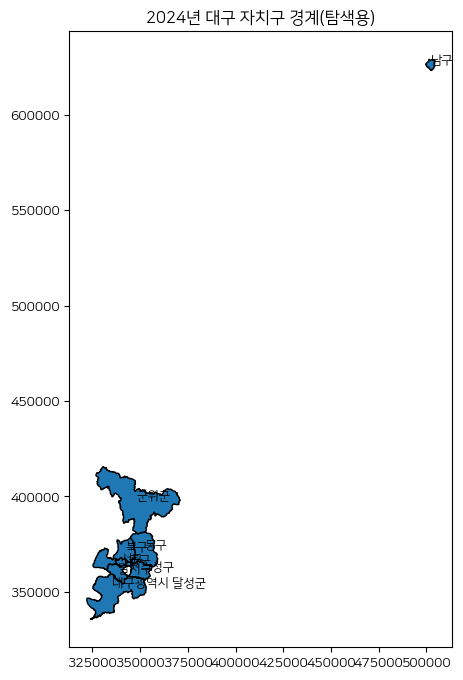

In [ ]:
ax = shp2024_daegu.plot(figsize=(8, 8), edgecolor="black")
for idx, row in shp2024_daegu.iterrows():
    if row.geometry is not None and not row.geometry.is_empty:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(x, y, row["A2"], fontsize=9)

ax.set_title("2024년 대구 자치구 경계(탐색용)")
plt.show()

##### 2-6-7. 2023년과 2024년 남구 geometry 비교용 추출

In [ ]:
shp2023_daegu = geo_daegu_dfs[2023].copy()

namgu_2023 = shp2023_daegu[shp2023_daegu["A2"] == "남구"].copy()
namgu_2024 = shp2024_daegu[shp2024_daegu["A2"] == "남구"].copy()

print("2023 남구 개수:", len(namgu_2023))
print("2024 남구 개수:", len(namgu_2024))

display(namgu_2023[["A1", "A2", "geometry"]])
display(namgu_2024[["A1", "A2", "geometry"]])

2023 남구 개수: 1
2024 남구 개수: 1


,A1,A2,geometry
4,27200,남구,"POLYGON ((342669.965 363422.142, 342980.935 363259.835, 343433.275 363314.592, 343639.273 363340.408, 343735.71 363341.566, 344012.553 363307.758, 344052.178 363302.978, 344234.428 363280.949, 344..."


,A1,A2,geometry
44,27200,남구,"POLYGON ((501419.662 629245.946, 501440.493 629234.812, 501444.147 629232.881, 501623.636 629138.052, 501780.982 629055.405, 501852.704 629017.643, 501889.413 628998.083, 501985.493 628947.658, 50..."


##### 2-6-8. 2023/2024 남구 bounds 비교

In [ ]:
if len(namgu_2023) > 0 and len(namgu_2024) > 0:
    print("2023 남구 bounds:", namgu_2023.total_bounds)
    print("2024 남구 bounds:", namgu_2024.total_bounds)

2023 남구 bounds: [340537.23878889 357827.94979677 345337.05221924 363676.03962001]
2024 남구 bounds: [499743.46420939 623401.30058488 504537.0845614  629245.94640456]


### 2-7. 2024 핵심 분석용 데이터 구조 점검 요약

In [ ]:
summary_rows = []

summary_rows.append({
    "데이터셋": "인구(2024)",
    "shape": pop.shape,
    "핵심메모": "월별 wide 구조, 대구 전체 행 포함, 문자열 숫자 정리 후 연평균 인구 계산 필요"
})

summary_rows.append({
    "데이터셋": "범죄(2024)",
    "shape": crime.shape,
    "핵심메모": "다중 헤더 구조, 자치구명 재설정 필요, '-' 값 0 처리 및 long 변환 필요"
})

summary_rows.append({
    "데이터셋": "CCTV 원본 1차 통합(탐색용)",
    "shape": cctv_origin_unified_df.shape,
    "핵심메모": "자치구별 원본 파일 구조 상이, 공통 의미 컬럼 기준 1차 통합 완료, 카메라수/설치연도/좌표 품질 차이 큼"
})

summary_rows.append({
    "데이터셋": "용도지역(2024)",
    "shape": landuse.shape,
    "핵심메모": "행=세부용도, 열=자치구 wide 구조, long 변환 및 상위 구분(주거/상업/공업) 재집계 필요"
})

summary_rows.append({
    "데이터셋": "경계(2024-원본)",
    "shape": shp2024.shape,
    "핵심메모": "전국 SIG 전체 포함, 대구 자치구만 필터링 필요, CRS 및 컬럼 구조 점검 필요"
})

if "shp2024_daegu" in globals():
    summary_rows.append({
        "데이터셋": "경계(2024-대구 필터)",
        "shape": shp2024_daegu.shape,
        "핵심메모": "대구 9개 자치구 필터링 완료, 남구 geometry 오류 검토 및 면적 계산 전 CRS 통일 필요"
    })

eda_summary_df = pd.DataFrame(summary_rows)

print("[2024 핵심 분석용 데이터 구조 점검 요약]")
display(eda_summary_df)

[2024 핵심 분석용 데이터 구조 점검 요약]


,데이터셋,shape,핵심메모
0,인구(2024),"(10, 73)","월별 wide 구조, 대구 전체 행 포함, 문자열 숫자 정리 후 연평균 인구 계산 필요"
1,범죄(2024),"(50, 12)","다중 헤더 구조, 자치구명 재설정 필요, '-' 값 0 처리 및 long 변환 필요"
2,CCTV 원본 1차 통합(탐색용),"(24485, 7)","자치구별 원본 파일 구조 상이, 공통 의미 컬럼 기준 1차 통합 완료, 카메라수/설치연도/좌표 품질 차이 큼"
3,용도지역(2024),"(21, 12)","행=세부용도, 열=자치구 wide 구조, long 변환 및 상위 구분(주거/상업/공업) 재집계 필요"
4,경계(2024-원본),"(282, 6)","전국 SIG 전체 포함, 대구 자치구만 필터링 필요, CRS 및 컬럼 구조 점검 필요"
5,경계(2024-대구 필터),"(9, 6)","대구 9개 자치구 필터링 완료, 남구 geometry 오류 검토 및 면적 계산 전 CRS 통일 필요"


# 3. 전처리

### 3-0. 전처리용 함수

##### 3-0-1. 공통함수

In [ ]:
def clean_numeric_series(series: pd.Series) -> pd.Series:
    s = series.copy()
    s = s.astype("string").str.strip()
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA,
        "-": pd.NA
    })
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")


def normalize_text_series(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA,
        "-": pd.NA
    })
    return s


def extract_admin_name(text: str) -> str:
    if pd.isna(text):
        return np.nan

    text = str(text).strip()

    m = re.match(r"대구광역시\s*(.*?)\s*\(", text)
    if m:
        name = m.group(1).strip()
        return name if name else "대구광역시"

    return text


def standardize_gu_name(name: str) -> str:
    if pd.isna(name):
        return np.nan

    name = str(name).strip()

    name = re.sub(
        r"^(대구광역시|서울특별시|부산광역시|인천광역시|광주광역시|대전광역시|울산광역시|세종특별자치시|"
        r"경기도|강원특별자치도|충청북도|충청남도|전북특별자치도|전라남도|경상북도|경상남도|제주특별자치도)\s+",
        "",
        name
    )

    mapping = {
        "중구": "중구",
        "동구": "동구",
        "서구": "서구",
        "남구": "남구",
        "북구": "북구",
        "수성": "수성구",
        "수성구": "수성구",
        "달서": "달서구",
        "달서구": "달서구",
        "달성": "달성군",
        "달성군": "달성군",
        "군위": "군위군",
        "군위군": "군위군",
        "대구광역시": "대구광역시",
    }
    return mapping.get(name, name)


def extract_install_year(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "NULL": pd.NA,
        "null": pd.NA,
        "-": pd.NA
    })

    num = pd.to_numeric(s, errors="coerce")
    year_num = num.where(num.between(1900, 2100), pd.NA)

    year_str = s.str.extract(r"(19\d{2}|20\d{2})", expand=False)
    year_str = pd.to_numeric(year_str, errors="coerce")

    return year_num.fillna(year_str)

##### 3-0-2. 5대범죄 재분류

In [ ]:
VIOLENCE_ITEMS = {
    "폭행",
    "상해",
    "협박",
    "공갈",
    "약취와 유인",
    "체포와 감금",
    "폭력행위등(손괴·강요·주거침입등)",
    "폭력행위등(단체등의구성·활동)",
}

def map_five_major_crime(crime_l3: str) -> str:
    if pd.isna(crime_l3):
        return np.nan

    crime_l3 = str(crime_l3).strip()

    if crime_l3 == "살인":
        return "살인"
    elif crime_l3 == "강도":
        return "강도"
    elif crime_l3 == "절도":
        return "절도"
    elif crime_l3 == "성폭력":
        return "성범죄"
    elif crime_l3 in VIOLENCE_ITEMS:
        return "폭력"
    else:
        return np.nan

##### 3-0-3. CCTV 설치목적 표준화

In [ ]:
def normalize_purpose_raw(x: str) -> str:
    if pd.isna(x):
        return np.nan
    x = str(x).replace("\n", " ").strip()
    x = re.sub(r"\s+", " ", x)
    return x


def map_cctv_purpose(x: str) -> str:
    x = normalize_purpose_raw(x)

    if pd.isna(x):
        return np.nan

    if x in {"방범", "생활방범", "생활안전", "차량방범"}:
        return "방범"

    if x in {"어린이보호", "어린이보호구역", "영유아 안전및보안"}:
        return "어린이 보호구역"

    if x in {"도시공원", "도시공원놀이터"}:
        return "도시공원 놀이터"

    if x in {
        "교통관리", "교통단속", "차량번호인식", "주차인식", "차번", "차번동영상",
        "불법주정차 단속", "둔치주차장 관제"
    }:
        return "교통관리"

    if x in {
        "재난안전", "재난재해", "재난재해(산불)", "재난재해(산불감시)",
        "재난재해(도로 결빙)", "재난재해(도로결빙)", "재난재해(침수)",
        "재난재해(터널)", "재난재해(하천)", "재난재해(하천감시)",
        "재난재해(둔치주차장 관제 등)"
    }:
        return "재난재해"

    if x in {
        "쓰레기단속", "쓰레기투기", "쓰레기투기 감시", "쓰레기투기감시",
        "불법쓰레기투기", "불법투기 방지", "불법투기감시", "무단투기단속"
    }:
        return "쓰레기 투기감시"

    if x in {
        "시설물관리", "시설물 관리", "시설물관리(주차장)",
        "시설물보호 및 안전사고 예방", "시설안전 및 화재 예방용",
        "안전사고 예방", "안전사고 예방 및 시설물 보호",
        "청사방호", "청사 및 민원인 방호", "동 청사 방호 등",
        "주민자치센터 안전관리", "민원실 안전한 환경조성",
        "문화재관리", "문화회관 보안용", "동 주민센터 공용주차장 관리",
        "주차장 사고 예방"
    }:
        return "청사, 시설, 문화재관리"

    if x in {"기타", "다목적"}:
        return np.nan

    return np.nan

##### 3-0-4. CCTV 원본 의미 기준 칼럼 후보

In [ ]:
CCTV_FIELD_CANDIDATES = {
    "소재지": [
        "카메라 설치위치",
        "카메라 설치위치 ",
        "설치장소(도로명주소)",
        "소새지도로명주소",
        "소재지도로명주소",
        "소재지지번주소",
        "주소",
    ],
    "설치목적구분": [
        "설치목적구분", "설치목적", "설치 목적", "목적", "용도"
    ],
    "카메라수": [
        "카메라수", "카메라대수", "카메라 대수"
    ],
    "설치연도": [
        "설치연도", "설치년도", "설치연월", "설치년월", "설치일자", "설치일", "설치년"
    ],
    "위도": [
        "위도", "WGS84위도", "Latitude", "latitude", "lat"
    ],
    "경도": [
        "경도", "WGS84경도", "Longitude", "longitude", "lon", "lng"
    ],
}

def coalesce_series(df: pd.DataFrame, candidates: list[str]) -> pd.Series:
    found = [c for c in candidates if c in df.columns]
    if not found:
        return pd.Series([pd.NA] * len(df), index=df.index, dtype="object")

    out = df[found[0]].copy()
    for c in found[1:]:
        out = out.where(out.notna() & (out.astype("string").str.strip() != ""), df[c])
    return out

##### 3-0-5. 카카오 주소검색 API

In [ ]:
KAKAO_REST_API_KEY = os.getenv("KAKAO_REST_API_KEY", "")
KAKAO_REST_API_KEY = ""

KAKAO_ADDRESS_URL = "https://dapi.kakao.com/v2/local/search/address.json"

def build_kakao_query(gu: str, address_value: str) -> str | None:
    if pd.isna(address_value):
        return None

    address_value = str(address_value).strip()
    if address_value == "":
        return None

    if "대구" in address_value:
        return address_value

    return f"대구광역시 {gu} {address_value}"


def kakao_search_address_only(query: str, session: requests.Session, rest_api_key: str, sleep_sec: float = 0.03) -> dict:
    if pd.isna(query) or str(query).strip() == "":
        return {
            "success": False,
            "x": np.nan,
            "y": np.nan,
            "address_name": None,
            "address_type": None,
            "search_method": "주소검색",
            "message": "query_is_empty"
        }

    if not rest_api_key:
        raise ValueError("KAKAO_REST_API_KEY가 설정되지 않았습니다.")

    headers = {
        "Authorization": f"KakaoAK {rest_api_key}"
    }

    allowed_types = {"ROAD_ADDR", "REGION_ADDR"}

    for analyze_type in ["exact", "similar"]:
        try:
            resp = session.get(
                KAKAO_ADDRESS_URL,
                headers=headers,
                params={
                    "query": str(query).strip(),
                    "analyze_type": analyze_type
                },
                timeout=10
            )
            resp.raise_for_status()
            data = resp.json()

            docs = data.get("documents", [])
            filtered = [doc for doc in docs if doc.get("address_type") in allowed_types]

            if len(filtered) > 0:
                doc = filtered[0]
                time.sleep(sleep_sec)
                return {
                    "success": True,
                    "x": float(doc["x"]) if doc.get("x") not in [None, ""] else np.nan,
                    "y": float(doc["y"]) if doc.get("y") not in [None, ""] else np.nan,
                    "address_name": doc.get("address_name"),
                    "address_type": doc.get("address_type"),
                    "search_method": "주소검색",
                    "message": f"ok_{analyze_type}"
                }

        except requests.HTTPError as e:
            return {
                "success": False,
                "x": np.nan,
                "y": np.nan,
                "address_name": None,
                "address_type": None,
                "search_method": "주소검색",
                "message": f"http_error: {e}"
            }
        except Exception as e:
            return {
                "success": False,
                "x": np.nan,
                "y": np.nan,
                "address_name": None,
                "address_type": None,
                "search_method": "주소검색",
                "message": f"request_error: {e}"
            }

    return {
        "success": False,
        "x": np.nan,
        "y": np.nan,
        "address_name": None,
        "address_type": None,
        "search_method": "주소검색",
        "message": "no_valid_address_result"
    }

##### 3-0-6. geometry 검증용 함수

In [ ]:
def spatial_validate_chunked(df: pd.DataFrame, lat_col: str, lon_col: str, validate_gdf: gpd.GeoDataFrame, chunk_size: int = 5000, desc: str = "좌표검증") -> pd.DataFrame:
    result = pd.DataFrame(index=df.index)
    result["검증자치구"] = pd.NA
    result["검증성공여부"] = 0
    result["검증메시지"] = "coord_missing"

    valid_idx = df.index[df[lat_col].notna() & df[lon_col].notna()]

    if len(valid_idx) == 0:
        return result

    idx_list = list(valid_idx)

    for start in tqdm(range(0, len(idx_list), chunk_size), desc=desc, unit="chunk"):
        chunk_idx = idx_list[start:start + chunk_size]
        chunk = df.loc[chunk_idx, ["자치구", lat_col, lon_col]].copy()
        chunk = chunk.rename(columns={lat_col: "위도", lon_col: "경도"})

        point_gdf = gpd.GeoDataFrame(
            chunk[["자치구"]].copy(),
            geometry=gpd.points_from_xy(chunk["경도"], chunk["위도"]),
            crs="EPSG:4326"
        ).to_crs(validate_gdf.crs)

        joined = gpd.sjoin(
            point_gdf,
            validate_gdf[["자치구", "geometry"]].rename(columns={"자치구": "경계판정자치구"}),
            how="left",
            predicate="intersects"
        ).reset_index().rename(columns={"index": "원본인덱스"})

        joined["자치구"] = joined["자치구"].apply(standardize_gu_name)
        joined["경계판정자치구"] = joined["경계판정자치구"].apply(standardize_gu_name)

        joined["우선순위"] = (joined["자치구"] == joined["경계판정자치구"]).astype(int)
        joined = (
            joined
            .sort_values(["원본인덱스", "우선순위"], ascending=[True, False])
            .drop_duplicates(subset=["원본인덱스"], keep="first")
        )

        for _, row in joined.iterrows():
            idx = row["원본인덱스"]
            judged = row["경계판정자치구"]
            origin_gu = row["자치구"]

            result.at[idx, "검증자치구"] = judged

            if pd.isna(judged):
                result.at[idx, "검증성공여부"] = 0
                result.at[idx, "검증메시지"] = "outside_daegu_gu"
            elif judged == origin_gu:
                result.at[idx, "검증성공여부"] = 1
                result.at[idx, "검증메시지"] = "inside_same_gu"
            else:
                result.at[idx, "검증성공여부"] = 0
                result.at[idx, "검증메시지"] = f"inside_other_gu:{judged}"

    return result

### 3-1. 인구 데이터 전처리

In [ ]:
population_clean_dict = {}

for year, df in population_dfs.items():
    temp = df.copy()

    # 자치구명 추출 및 표준화
    temp["자치구"] = temp["행정구역"].apply(extract_admin_name).apply(standardize_gu_name)

    # 대구 전체 행 제거
    temp = temp[temp["자치구"] != "대구광역시"].copy()

    # 해당 연도 월별 총인구수 컬럼 추출
    pop_cols = [col for col in temp.columns if re.match(rf"^{year}년\d{{2}}월_총인구수$", col)]

    # 숫자형 변환
    for col in pop_cols:
        temp[col] = clean_numeric_series(temp[col])

    # 연평균 인구
    temp["연평균인구"] = temp[pop_cols].mean(axis=1)

    # 최소 결과물
    out = temp[["자치구", "연평균인구"]].copy()
    out["연도"] = year

    # 정렬
    out = out[["연도", "자치구", "연평균인구"]].sort_values(["연도", "자치구"]).reset_index(drop=True)

    population_clean_dict[year] = out

# 통합
population_clean_df = pd.concat(population_clean_dict.values(), ignore_index=True)

# 장기 비교용(군위군 제외)
population_long_df = population_clean_df[population_clean_df["자치구"].isin(DAEGU_GU_LIST_LONG)].copy()

# 2024 핵심 분석용(군위군 포함)
population_2024_df = population_clean_df[population_clean_df["연도"] == 2024].copy()

print("[population_clean_df]")
display(population_clean_df.head(20))

[population_clean_df]


,연도,자치구,연평균인구
0,2019,남구,148814.083333
1,2019,달서구,571056.333333
2,2019,달성군,254516.583333
3,2019,동구,348538.0
4,2019,북구,438564.166667
5,2019,서구,179505.25
6,2019,수성구,430444.666667
7,2019,중구,78152.0
8,2020,남구,147372.333333
9,2020,달서구,564601.416667


### 3-2. 범죄 데이터 전처리

In [ ]:
crime_clean_dict = {}
crime_total_dict = {}
crime_five_dict = {}
crime_five_pivot_dict = {}

for year, df in crime_dfs.items():
    raw = df.copy()

    # 현재 구조:
    # columns = ['범죄별(1)', '범죄별(2)', '범죄별(3)', '2024', '2024.1', ...]
    # raw.iloc[1, 3:] = 실제 자치구명
    base_cols = list(raw.columns[:3])
    region_cols = list(raw.columns[3:])

    region_names = raw.iloc[1, 3:].astype(str).str.strip().apply(standardize_gu_name).tolist()

    # 데이터 본문
    temp = raw.iloc[2:].copy().reset_index(drop=True)
    temp.columns = base_cols + region_names

    # 컬럼명 정리
    temp = temp.rename(columns={
        base_cols[0]: "범죄별1",
        base_cols[1]: "범죄별2",
        base_cols[2]: "범죄별3"
    })

    # long 변환
    long_df = temp.melt(
        id_vars=["범죄별1", "범죄별2", "범죄별3"],
        value_vars=region_names,
        var_name="자치구",
        value_name="범죄건수"
    )

    long_df["자치구"] = long_df["자치구"].apply(standardize_gu_name)
    long_df["범죄건수"] = clean_numeric_series(long_df["범죄건수"]).fillna(0)
    long_df["연도"] = year

    # 저장
    crime_clean_dict[year] = long_df.copy()

    # 전체 범죄 합계
    total_df = (
        long_df
        .groupby(["연도", "자치구"], as_index=False)["범죄건수"]
        .sum()
        .rename(columns={"범죄건수": "전체범죄건수"})
    )
    crime_total_dict[year] = total_df

    # 5대범죄 재분류
    five_df = long_df.copy()
    five_df["5대범죄구분"] = five_df["범죄별3"].apply(map_five_major_crime)
    five_df = five_df[five_df["5대범죄구분"].notna()].copy()

    # 5대범죄 유형별
    five_pivot = (
        five_df.groupby(["연도", "자치구", "5대범죄구분"], as_index=False)["범죄건수"]
        .sum()
        .pivot(index=["연도", "자치구"], columns="5대범죄구분", values="범죄건수")
        .reset_index()
        .fillna(0)
    )

    # 5대범죄 합계
    value_cols = [c for c in five_pivot.columns if c not in ["연도", "자치구"]]
    five_pivot["5대범죄건수"] = five_pivot[value_cols].sum(axis=1)

    crime_five_dict[year] = five_df
    crime_five_pivot_dict[year] = five_pivot

crime_clean_df = pd.concat(crime_clean_dict.values(), ignore_index=True)
crime_total_df = pd.concat(crime_total_dict.values(), ignore_index=True)
crime_five_pivot_df = pd.concat(crime_five_pivot_dict.values(), ignore_index=True)

# 장기 비교용(군위군 제외)
crime_total_long_df = crime_total_df[crime_total_df["자치구"].isin(DAEGU_GU_LIST_LONG)].copy()
crime_five_long_df = crime_five_pivot_df[crime_five_pivot_df["자치구"].isin(DAEGU_GU_LIST_LONG)].copy()

# 2024 핵심 분석용
crime_total_2024_df = crime_total_df[crime_total_df["연도"] == 2024].copy()
crime_five_2024_df = crime_five_pivot_df[crime_five_pivot_df["연도"] == 2024].copy()

print("[crime_clean_df]")
display(crime_clean_df.head(20))

print("\n[crime_total_df]")
display(crime_total_df.head(20))

print("\n[crime_five_pivot_df]")
display(crime_five_pivot_df.head(20))

[crime_clean_df]


,범죄별1,범죄별2,범죄별3,자치구,범죄건수,연도
0,형법범,재산범죄,절도,중구,1482,2019
1,형법범,재산범죄,장물,중구,4,2019
2,형법범,재산범죄,사기,중구,1192,2019
3,형법범,재산범죄,횡령,중구,432,2019
4,형법범,재산범죄,배임,중구,12,2019
5,형법범,재산범죄,손괴,중구,263,2019
6,형법범,강력범죄(흉악),살인,중구,1,2019
7,형법범,강력범죄(흉악),강도,중구,4,2019
8,형법범,강력범죄(흉악),방화,중구,2,2019
9,형법범,강력범죄(흉악),성폭력,중구,207,2019



[crime_total_df]


,연도,자치구,전체범죄건수
0,2019,남구,3706
1,2019,달서구,10488
2,2019,달성군,3061
3,2019,동구,6991
4,2019,북구,7545
5,2019,서구,4141
6,2019,수성구,7176
7,2019,중구,5456
8,2020,남구,3637
9,2020,달서구,10749



[crime_five_pivot_df]


5대범죄구분,연도,자치구,강도,살인,성범죄,절도,폭력,5대범죄건수
0,2019,남구,2,4,89,726,871,1692
1,2019,달서구,8,10,276,2058,2213,4565
2,2019,달성군,2,6,92,631,746,1477
3,2019,동구,5,8,206,1265,1382,2866
4,2019,북구,3,6,183,1340,1935,3467
5,2019,서구,7,0,81,689,1055,1832
6,2019,수성구,4,7,157,1099,1238,2505
7,2019,중구,4,1,207,1482,1271,2965
8,2020,남구,4,2,69,679,696,1450
9,2020,달서구,6,6,243,1867,1987,4109


### 3-3. 경계 데이터 전처리 및 2024 남구 geometry 교체

In [ ]:
geo_clean_dict = {}

for year, gdf in geo_dfs.items():
    temp = gdf.copy()

    # 존재하는 컬럼만 문자열 정리
    existing_cols = [col for col in ["A1", "A2", "A4"] if col in temp.columns]
    for col in existing_cols:
        temp[col] = temp[col].astype(str).str.strip()

    valid_codes = set(DAEGU_SIG_MAP.keys())

    # A4 없는 연도 대비
    if "A4" not in temp.columns:
        temp["A4"] = np.nan

    # 대구 자치구만 필터링
    temp = temp[
        temp["A1"].isin(valid_codes) | temp["A4"].isin(valid_codes)
    ].copy()

    # SIG 코드 확정
    temp["SIG_CD"] = np.where(
        temp["A1"].isin(valid_codes),
        temp["A1"],
        temp["A4"]
    )

    # 자치구명 표준화
    if "A2" not in temp.columns:
        raise ValueError(f"{year}년 경계 데이터에 A2 컬럼이 없습니다.")

    temp["자치구"] = temp["A2"].apply(standardize_gu_name)

    # 필요한 컬럼만 유지
    temp = temp[["SIG_CD", "자치구", "geometry"]].copy()

    # CRS 통일
    if temp.crs is None:
        raise ValueError(f"{year}년 경계 데이터 CRS가 없습니다.")

    if temp.crs.to_epsg() != 5186:
        temp = temp.to_crs(epsg=5186)

    # invalid geometry 보정
    invalid_mask = ~temp.geometry.is_valid
    if invalid_mask.any():
        temp.loc[invalid_mask, "geometry"] = temp.loc[invalid_mask, "geometry"].buffer(0)

    geo_clean_dict[year] = temp

# 2024 남구 geometry를 2023년 남구 geometry로 교체
geo_2023 = geo_clean_dict[2023].copy()
geo_2024 = geo_clean_dict[2024].copy()

namgu_geom_2023 = geo_2023.loc[geo_2023["SIG_CD"] == "27200", "geometry"].iloc[0]
geo_2024.loc[geo_2024["SIG_CD"] == "27200", "geometry"] = namgu_geom_2023

geo_clean_dict[2024] = geo_2024

# 면적 계산
for year in geo_clean_dict.keys():
    geo_clean_dict[year]["자치구총면적_km2"] = geo_clean_dict[year].geometry.area / 1_000_000

geo_clean_df = pd.concat(
    [g.assign(연도=year) for year, g in geo_clean_dict.items()],
    ignore_index=True
)[["연도", "SIG_CD", "자치구", "자치구총면적_km2", "geometry"]]

geo_long_df = geo_clean_df[geo_clean_df["자치구"].isin(DAEGU_GU_LIST_LONG)].copy()
geo_2024_df = geo_clean_df[geo_clean_df["연도"] == 2024].copy()

# 2024 검증용 경계
validate_gdf_2024 = geo_clean_dict[2024].copy()

# sanity check
expected_gu_2024 = set(DAEGU_GU_LIST)
actual_gu_2024 = set(geo_2024_df["자치구"].astype(str).tolist())

missing_gu = expected_gu_2024 - actual_gu_2024
if missing_gu:
    raise ValueError(f"2024 경계 데이터에 누락된 자치구가 있습니다: {missing_gu}")

print("[geo_2024_df]")
display(geo_2024_df.sort_values("자치구").reset_index(drop=True))

[geo_2024_df]


,연도,SIG_CD,자치구,자치구총면적_km2,geometry
0,2024,27720,군위군,613.515544,"POLYGON ((340119.539 399102.251, 340039.873 399160.674, 339970.114 399165.158, 339863.517 399196.452, 339769.161 399175.261, 339661.122 399192.964, 339613.531 399194.323, 339573.128 399195.619, 33..."
1,2024,27200,남구,17.750966,"POLYGON ((342669.965 363422.142, 342980.935 363259.835, 343433.275 363314.592, 343639.273 363340.408, 343735.71 363341.566, 344012.553 363307.758, 344052.178 363302.978, 344234.428 363280.949, 344..."
2,2024,27290,달서구,62.294304,"POLYGON ((343464.446 357828.1, 343435.307 357781.91, 343408.181 357702.857, 343368.271 357602.103, 343391.386 357554.774, 343399.733 357497.736, 343456.951 357387.805, 343453.256 357356.276, 34344..."
3,2024,27710,달성군,418.330739,"MULTIPOLYGON (((328496.056 337675.759, 328495.188 337672.401, 328488.131 337662.156, 328482.356 337655.799, 328465.771 337641.577, 328456.764 337634.467, 328453.563 337630.465, 328453.794 337622.1..."
4,2024,27140,동구,181.815921,"POLYGON ((357205.168 373025.201, 357153.891 372935.108, 357051.672 372748.695, 357049.767 372745.262, 357028.929 372745.969, 357152.597 372687.12, 357096.055 372678.133, 357034.501 372483.989, 357..."
5,2024,27230,북구,93.689359,"POLYGON ((335892.651 367337.324, 335904.369 367341.952, 335910.968 367345.441, 335912.182 367346.236, 335909.215 367346.851, 335910.184 367415.014, 335907.381 367470.778, 335904.227 367531.625, 33..."
6,2024,27170,서구,17.366948,"POLYGON ((342696.153 365149.541, 342696.162 365151.539, 342696.33 365150.264, 342696.387 365160.538, 342698.576 365153.345, 342699.028 365140.023, 342701.816 365122.373, 342702.203 365110.554, 342..."
7,2024,27260,수성구,76.709987,"POLYGON ((356053.084 362441.04, 356053.12 362440.524, 356051.824 362418.385, 356030.22 362396.566, 356005.673 362363.583, 356006.425 362345.606, 356007.535 362327.09, 356011.54 362286.48, 356014.8..."
8,2024,27110,중구,7.053767,"POLYGON ((345421.875 364051.108, 345358.745 364063.48, 345331.182 363983.569, 345320.487 363953.437, 345313.997 363913.209, 345305.278 363824.152, 345302.486 363785.346, 345302.226 363785.342, 345..."


### 3-4. CCTV 데이터 전처리 + 카카오 주소검색 후보 생성

In [ ]:
cctv_preclean_list = []

for gu, df in cctv_dfs.items():
    temp = df.copy()
    temp.columns = [str(c).strip() for c in temp.columns]
    temp["자치구"] = gu

    소재지_raw = coalesce_series(temp, CCTV_FIELD_CANDIDATES["소재지"])
    설치목적_raw = coalesce_series(temp, CCTV_FIELD_CANDIDATES["설치목적구분"])
    카메라수_raw = coalesce_series(temp, CCTV_FIELD_CANDIDATES["카메라수"])
    설치연도_raw = coalesce_series(temp, CCTV_FIELD_CANDIDATES["설치연도"])
    위도_raw = coalesce_series(temp, CCTV_FIELD_CANDIDATES["위도"])
    경도_raw = coalesce_series(temp, CCTV_FIELD_CANDIDATES["경도"])

    temp["소재지"] = normalize_text_series(소재지_raw)
    temp["설치목적구분"] = normalize_text_series(설치목적_raw)
    temp["설치목적표준"] = temp["설치목적구분"].apply(map_cctv_purpose)
    temp["설치목적미분류여부"] = temp["설치목적표준"].isna().astype(int)

    temp["카메라수"] = clean_numeric_series(카메라수_raw)
    temp["카메라수결측대체여부"] = temp["카메라수"].isna().astype(int)
    temp["카메라수보정"] = temp["카메라수"].fillna(1)

    temp["설치연도"] = extract_install_year(설치연도_raw)
    temp["설치연도존재여부"] = temp["설치연도"].notna().astype(int)

    temp["원본위도"] = clean_numeric_series(위도_raw)
    temp["원본경도"] = clean_numeric_series(경도_raw)
    temp["원본좌표존재여부"] = (
        temp["원본위도"].notna() & temp["원본경도"].notna()
    ).astype(int)

    temp["지오코딩검색어"] = temp.apply(
        lambda r: build_kakao_query(r["자치구"], r["소재지"]),
        axis=1
    )

    cctv_preclean_list.append(
        temp[
            [
                "자치구",
                "소재지",
                "설치목적구분",
                "설치목적표준",
                "설치목적미분류여부",
                "카메라수",
                "카메라수보정",
                "카메라수결측대체여부",
                "설치연도",
                "설치연도존재여부",
                "원본위도",
                "원본경도",
                "원본좌표존재여부",
                "지오코딩검색어",
            ]
        ].copy()
    )

cctv_preclean_df = pd.concat(cctv_preclean_list, ignore_index=True)

need_geocode_mask = (
    (cctv_preclean_df["원본좌표존재여부"] == 0) &
    (cctv_preclean_df["지오코딩검색어"].notna())
)

unique_queries = (
    cctv_preclean_df.loc[need_geocode_mask, "지오코딩검색어"]
    .astype(str)
    .str.strip()
    .dropna()
    .unique()
)

geocode_results = []
session = requests.Session()

for query in tqdm(unique_queries, desc="3-4 주소검색", unit="query"):
    result = kakao_search_address_only(query, session=session, rest_api_key=KAKAO_REST_API_KEY)
    geocode_results.append({
        "지오코딩검색어": query,
        "API위도": result["y"],
        "API경도": result["x"],
        "API주소명": result["address_name"],
        "API주소유형": result["address_type"],
        "좌표검색방식": result["search_method"],
        "지오코딩성공여부": int(result["success"]),
        "지오코딩메시지": result["message"],
    })

geocode_result_df = pd.DataFrame(geocode_results)

cctv_preclean_df = cctv_preclean_df.merge(
    geocode_result_df,
    on="지오코딩검색어",
    how="left"
)

for col in ["API위도", "API경도", "API주소명", "API주소유형", "좌표검색방식", "지오코딩성공여부", "지오코딩메시지"]:
    if col not in cctv_preclean_df.columns:
        cctv_preclean_df[col] = pd.NA

cctv_preclean_df["지오코딩성공여부"] = cctv_preclean_df["지오코딩성공여부"].fillna(0).astype(int)

print("[cctv_preclean_df]")
display(cctv_preclean_df.head(20))

print("\n[cctv_preclean_df shape]")
print(cctv_preclean_df.shape)

print("\n[지오코딩 대상 요약]")
display(
    cctv_preclean_df.groupby("자치구", as_index=False).agg(
        전체행수=("자치구", "size"),
        원본좌표행수=("원본좌표존재여부", "sum"),
        지오코딩성공행수=("지오코딩성공여부", "sum"),
    )
)

3-4 주소검색:   0%|          | 0/8403 [00:00<?, ?query/s]

[cctv_preclean_df]


,자치구,소재지,설치목적구분,설치목적표준,설치목적미분류여부,카메라수,카메라수보정,카메라수결측대체여부,설치연도,설치연도존재여부,원본위도,원본경도,원본좌표존재여부,지오코딩검색어,API위도,API경도,API주소명,API주소유형,좌표검색방식,지오코딩성공여부,지오코딩메시지
0,중구,동성로2길 45,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 동성로2길 45,35.868061,128.596443,대구 중구 동성로2길 45,ROAD_ADDR,주소검색,1,ok_exact
1,중구,공평로 31,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 공평로 31,35.866579,128.599523,대구 중구 공평로 31,ROAD_ADDR,주소검색,1,ok_exact
2,중구,동성로3길 84,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 동성로3길 84,NaN,NaN,None,None,주소검색,0,no_valid_address_result
3,중구,달구벌대로447길 72-1,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 달구벌대로447길 72-1,35.865611,128.608392,대구 중구 달구벌대로447길 72-1,ROAD_ADDR,주소검색,1,ok_exact
4,중구,남성로 50,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 남성로 50,35.867169,128.592031,대구 중구 남성로 50,ROAD_ADDR,주소검색,1,ok_exact
5,중구,달구벌대로 2109-31,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 달구벌대로 2109-31,35.866723,128.593808,대구 중구 달구벌대로 2109-31,ROAD_ADDR,주소검색,1,ok_exact
6,중구,교동길 13-6,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 교동길 13-6,35.873614,128.595487,대구 중구 교동길 13-6,ROAD_ADDR,주소검색,1,ok_exact
7,중구,중앙대로 391,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 중앙대로 391,35.867984,128.593019,대구 중구 중앙대로 391,ROAD_ADDR,주소검색,1,ok_exact
8,중구,동성로3길 12-22,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 동성로3길 12-22,35.865570,128.598434,대구 중구 동성로3길 12-22,ROAD_ADDR,주소검색,1,ok_exact
9,중구,동성로3길 12-22,생활안전,방범,0,<NA>,1.0,1,<NA>,0,<NA>,<NA>,0,대구광역시 중구 동성로3길 12-22,35.865570,128.598434,대구 중구 동성로3길 12-22,ROAD_ADDR,주소검색,1,ok_exact



[cctv_preclean_df shape]
(24485, 21)

[지오코딩 대상 요약]


,자치구,전체행수,원본좌표행수,지오코딩성공행수
0,군위군,443,0,422
1,남구,2424,0,2180
2,달서구,2900,2900,0
3,달성군,2556,0,2365
4,동구,2910,0,1924
5,북구,2706,0,2004
6,서구,5249,5249,0
7,수성구,3017,3017,0
8,중구,2280,0,2043


### 3-5. geometry 기준 좌표 검증 및 최종 좌표 확정

In [ ]:
origin_valid_df = spatial_validate_chunked(
    cctv_preclean_df,
    lat_col="원본위도",
    lon_col="원본경도",
    validate_gdf=validate_gdf_2024,
    chunk_size=5000,
    desc="3-5 원본좌표 검증"
)

api_valid_df = spatial_validate_chunked(
    cctv_preclean_df,
    lat_col="API위도",
    lon_col="API경도",
    validate_gdf=validate_gdf_2024,
    chunk_size=5000,
    desc="3-5 API좌표 검증"
)

cctv_clean_df = cctv_preclean_df.copy()

cctv_clean_df["원본검증자치구"] = origin_valid_df["검증자치구"]
cctv_clean_df["원본좌표유효여부"] = origin_valid_df["검증성공여부"]
cctv_clean_df["원본좌표검증메시지"] = origin_valid_df["검증메시지"]

cctv_clean_df["API검증자치구"] = api_valid_df["검증자치구"]
cctv_clean_df["API좌표유효여부"] = api_valid_df["검증성공여부"]
cctv_clean_df["API좌표검증메시지"] = api_valid_df["검증메시지"]

cctv_clean_df["위도"] = np.nan
cctv_clean_df["경도"] = np.nan
cctv_clean_df["좌표출처"] = "없음"
cctv_clean_df["좌표유효여부"] = 0
cctv_clean_df["좌표검증메시지"] = pd.NA

use_origin_idx = cctv_clean_df.index[cctv_clean_df["원본좌표유효여부"] == 1]
cctv_clean_df.loc[use_origin_idx, "위도"] = cctv_clean_df.loc[use_origin_idx, "원본위도"]
cctv_clean_df.loc[use_origin_idx, "경도"] = cctv_clean_df.loc[use_origin_idx, "원본경도"]
cctv_clean_df.loc[use_origin_idx, "좌표출처"] = "원본"
cctv_clean_df.loc[use_origin_idx, "좌표유효여부"] = 1
cctv_clean_df.loc[use_origin_idx, "좌표검증메시지"] = cctv_clean_df.loc[use_origin_idx, "원본좌표검증메시지"]

use_api_idx = cctv_clean_df.index[
    (cctv_clean_df["원본좌표유효여부"] == 0) &
    (cctv_clean_df["API좌표유효여부"] == 1)
]
cctv_clean_df.loc[use_api_idx, "위도"] = cctv_clean_df.loc[use_api_idx, "API위도"]
cctv_clean_df.loc[use_api_idx, "경도"] = cctv_clean_df.loc[use_api_idx, "API경도"]
cctv_clean_df.loc[use_api_idx, "좌표출처"] = "카카오API"
cctv_clean_df.loc[use_api_idx, "좌표유효여부"] = 1
cctv_clean_df.loc[use_api_idx, "좌표검증메시지"] = cctv_clean_df.loc[use_api_idx, "API좌표검증메시지"]

cctv_clean_df["좌표검색방식"] = np.where(
    cctv_clean_df["좌표출처"] == "카카오API",
    "주소검색",
    pd.NA
)

cctv_clean_df = cctv_clean_df[
    [
        "자치구",
        "소재지",
        "설치목적구분",
        "설치목적표준",
        "설치목적미분류여부",
        "카메라수",
        "카메라수보정",
        "카메라수결측대체여부",
        "설치연도",
        "설치연도존재여부",
        "위도",
        "경도",
        "좌표출처",
        "좌표검색방식",
        "지오코딩검색어",
        "지오코딩성공여부",
        "지오코딩메시지",
        "좌표유효여부",
        "좌표검증메시지",
        "원본위도",
        "원본경도",
        "원본좌표유효여부",
        "API위도",
        "API경도",
        "API좌표유효여부",
    ]
].copy()

print("[cctv_clean_df]")
display(cctv_clean_df.head(20))

print("\n[cctv_clean_df shape]")
print(cctv_clean_df.shape)

coord_summary_df = (
    cctv_clean_df
    .groupby("자치구", as_index=False)
    .agg(
        전체행수=("자치구", "size"),
        원본좌표채택행수=("좌표출처", lambda x: (x == "원본").sum()),
        카카오좌표채택행수=("좌표출처", lambda x: (x == "카카오API").sum()),
        좌표없음행수=("좌표출처", lambda x: (x == "없음").sum()),
        좌표유효행수=("좌표유효여부", "sum"),
    )
)
coord_summary_df["최종좌표존재행수"] = coord_summary_df["원본좌표채택행수"] + coord_summary_df["카카오좌표채택행수"]
coord_summary_df["최종좌표존재비율"] = (
    coord_summary_df["최종좌표존재행수"] / coord_summary_df["전체행수"]
).round(4)

print("\n[자치구별 최종 좌표 요약]")
display(coord_summary_df.sort_values("자치구").reset_index(drop=True))

3-5 원본좌표 검증:   0%|          | 0/3 [00:00<?, ?chunk/s]

3-5 API좌표 검증:   0%|          | 0/3 [00:00<?, ?chunk/s]

[cctv_clean_df]


,자치구,소재지,설치목적구분,설치목적표준,설치목적미분류여부,카메라수,카메라수보정,카메라수결측대체여부,설치연도,설치연도존재여부,위도,경도,좌표출처,좌표검색방식,지오코딩검색어,지오코딩성공여부,지오코딩메시지,좌표유효여부,좌표검증메시지,원본위도,원본경도,원본좌표유효여부,API위도,API경도,API좌표유효여부
0,중구,동성로2길 45,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.868061,128.596443,카카오API,주소검색,대구광역시 중구 동성로2길 45,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.868061,128.596443,1
1,중구,공평로 31,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.866579,128.599523,카카오API,주소검색,대구광역시 중구 공평로 31,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.866579,128.599523,1
2,중구,동성로3길 84,생활안전,방범,0,<NA>,1.0,1,<NA>,0,NaN,NaN,없음,<NA>,대구광역시 중구 동성로3길 84,0,no_valid_address_result,0,<NA>,<NA>,<NA>,0,NaN,NaN,0
3,중구,달구벌대로447길 72-1,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.865611,128.608392,카카오API,주소검색,대구광역시 중구 달구벌대로447길 72-1,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.865611,128.608392,1
4,중구,남성로 50,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.867169,128.592031,카카오API,주소검색,대구광역시 중구 남성로 50,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.867169,128.592031,1
5,중구,달구벌대로 2109-31,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.866723,128.593808,카카오API,주소검색,대구광역시 중구 달구벌대로 2109-31,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.866723,128.593808,1
6,중구,교동길 13-6,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.873614,128.595487,카카오API,주소검색,대구광역시 중구 교동길 13-6,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.873614,128.595487,1
7,중구,중앙대로 391,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.867984,128.593019,카카오API,주소검색,대구광역시 중구 중앙대로 391,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.867984,128.593019,1
8,중구,동성로3길 12-22,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.865570,128.598434,카카오API,주소검색,대구광역시 중구 동성로3길 12-22,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.865570,128.598434,1
9,중구,동성로3길 12-22,생활안전,방범,0,<NA>,1.0,1,<NA>,0,35.865570,128.598434,카카오API,주소검색,대구광역시 중구 동성로3길 12-22,1,ok_exact,1,inside_same_gu,<NA>,<NA>,0,35.865570,128.598434,1



[cctv_clean_df shape]
(24485, 25)

[자치구별 최종 좌표 요약]


,자치구,전체행수,원본좌표채택행수,카카오좌표채택행수,좌표없음행수,좌표유효행수,최종좌표존재행수,최종좌표존재비율
0,군위군,443,0,420,23,420,420,0.9481
1,남구,2424,0,2180,244,2180,2180,0.8993
2,달서구,2900,2854,0,46,2854,2854,0.9841
3,달성군,2556,0,2326,230,2326,2326,0.9100
4,동구,2910,0,1791,1119,1791,1791,0.6155
5,북구,2706,0,1894,812,1894,1894,0.6999
6,서구,5249,4749,0,500,4749,4749,0.9047
7,수성구,3017,2971,0,46,2971,2971,0.9848
8,중구,2280,0,1783,497,1783,1783,0.7820


### 3-6. 용도지역 데이터 전처리

In [ ]:
landuse_long_list = []
landuse_summary_list = []

for year, df in landuse_dfs.items():
    temp = df.copy()

    # 자치구 면적 컬럼만 추출(대구 전체 제외)
    area_cols = [col for col in temp.columns if col.endswith("(m2)") and col != "대구(m2)"]

    # long 변환
    long_df = temp.melt(
        id_vars=["구분", "상세구분"],
        value_vars=area_cols,
        var_name="자치구_원본",
        value_name="면적_m2"
    )

    long_df["자치구"] = (
        long_df["자치구_원본"]
        .str.replace("(m2)", "", regex=False)
        .str.strip()
        .apply(standardize_gu_name)
    )

    long_df["면적_m2"] = clean_numeric_series(long_df["면적_m2"]).fillna(0)
    long_df["면적_km2"] = long_df["면적_m2"] / 1_000_000
    long_df["연도"] = year

    landuse_long_list.append(long_df[["연도", "자치구", "구분", "상세구분", "면적_m2", "면적_km2"]])

    # 상위 구분 기준 요약
    summary = (
        long_df.groupby(["연도", "자치구", "구분"], as_index=False)["면적_km2"]
        .sum()
        .pivot(index=["연도", "자치구"], columns="구분", values="면적_km2")
        .reset_index()
        .fillna(0)
    )

    # 핵심 변수명 정리
    rename_map = {}
    if "주거지역" in summary.columns:
        rename_map["주거지역"] = "주거지역면적_km2"
    if "상업지역" in summary.columns:
        rename_map["상업지역"] = "상업지역면적_km2"
    if "공업지역" in summary.columns:
        rename_map["공업지역"] = "공업지역면적_km2"

    summary = summary.rename(columns=rename_map)

    # 없으면 0 컬럼 생성
    for col in ["주거지역면적_km2", "상업지역면적_km2", "공업지역면적_km2"]:
        if col not in summary.columns:
            summary[col] = 0

    # 용도지역 총합(검증용)
    land_cols = [c for c in summary.columns if c not in ["연도", "자치구"]]
    summary["용도지역총합_km2"] = summary[land_cols].sum(axis=1)

    landuse_summary_list.append(summary)

landuse_long_df = pd.concat(landuse_long_list, ignore_index=True)
landuse_summary_df = pd.concat(landuse_summary_list, ignore_index=True)

# 장기 비교용(군위군 제외)
landuse_long_compare_df = landuse_summary_df[landuse_summary_df["자치구"].isin(DAEGU_GU_LIST_LONG)].copy()

# 2024 핵심 분석용
landuse_2024_summary_df = landuse_summary_df[landuse_summary_df["연도"] == 2024].copy()

print("[landuse_long_df]")
display(landuse_long_df.head(20))

print("\n[landuse_summary_df]")
display(landuse_summary_df.head(20))

[landuse_long_df]


,연도,자치구,구분,상세구분,면적_m2,면적_km2
0,2019,중구,주거지역,제1종전용주거지역,0.0,0.0
1,2019,중구,주거지역,제2종전용주거지역,0.0,0.0
2,2019,중구,주거지역,제1종일반주거지역,66328.0,0.066328
3,2019,중구,주거지역,제2종일반주거지역,1323249.0,1.323249
4,2019,중구,주거지역,제3종일반주거지역,1550257.0,1.550257
5,2019,중구,주거지역,준주거지역,437306.0,0.437306
6,2019,중구,상업지역,중심상업지역,2773759.0,2.773759
7,2019,중구,상업지역,일반상업지역,0.0,0.0
8,2019,중구,상업지역,근린상업지역,347367.0,0.347367
9,2019,중구,상업지역,유통상업지역,0.0,0.0



[landuse_summary_df]


구분,연도,자치구,공업지역면적_km2,관리지역,녹지지역,농림지역,상업지역면적_km2,자연환경보전지역,주거지역면적_km2,용도지역총합_km2
0,2019,남구,0.0,0.0,8.280301,0.0,1.045866,0.0,8.105365,17.431532
1,2019,달서구,11.402022,0.0,27.608918,0.0,2.442133,0.0,20.886684,62.339757
2,2019,달성군,19.734128,0.0,334.965022,35.892842,1.351497,13.0,21.749051,426.69254
3,2019,동구,0.979024,0.0,121.329206,0.0,3.695297,35.29562,20.846917,182.146064
4,2019,북구,5.010582,0.0,65.315116,0.0,3.49617,0.0,20.16204,93.983908
5,2019,서구,4.084592,0.0,4.329199,0.0,1.294895,0.0,7.624438,17.333124
6,2019,수성구,0.0,0.0,56.305221,0.0,1.930988,0.0,18.29906,76.535269
7,2019,중구,0.0,0.0,0.556919,0.0,3.121126,0.0,3.37714,7.055185
8,2020,남구,0.0,0.0,8.280012,0.0,1.045866,0.0,8.105365,17.431243
9,2020,달서구,11.402022,0.0,27.609203,0.0,2.442133,0.0,20.886684,62.340042


### 3-7. CCTV 자치구 단위 집계

In [ ]:
cctv_purpose_summary = (
    cctv_clean_df
    .groupby(["자치구", "설치목적표준"], dropna=False, as_index=False)["카메라수보정"]
    .sum()
)

cctv_purpose_summary["설치목적표준"] = cctv_purpose_summary["설치목적표준"].fillna("미분류")

cctv_purpose_wide = (
    cctv_purpose_summary
    .pivot(index="자치구", columns="설치목적표준", values="카메라수보정")
    .reset_index()
    .fillna(0)
)

cctv_clean_df["좌표유효CCTV수_기여값"] = cctv_clean_df["카메라수보정"] * cctv_clean_df["좌표유효여부"]
cctv_clean_df["원본좌표채택CCTV수_기여값"] = cctv_clean_df["카메라수보정"] * (cctv_clean_df["좌표출처"] == "원본").astype(int)
cctv_clean_df["카카오좌표채택CCTV수_기여값"] = cctv_clean_df["카메라수보정"] * (cctv_clean_df["좌표출처"] == "카카오API").astype(int)

cctv_summary_df = (
    cctv_clean_df
    .groupby("자치구", as_index=False)
    .agg(
        전체행수=("자치구", "size"),
        CCTV총량=("카메라수보정", "sum"),

        좌표유효행수=("좌표유효여부", "sum"),
        좌표유효CCTV수=("좌표유효CCTV수_기여값", "sum"),

        원본좌표채택행수=("좌표출처", lambda x: (x == "원본").sum()),
        카카오좌표채택행수=("좌표출처", lambda x: (x == "카카오API").sum()),

        원본좌표채택CCTV수=("원본좌표채택CCTV수_기여값", "sum"),
        카카오좌표채택CCTV수=("카카오좌표채택CCTV수_기여값", "sum"),

        설치연도존재행수=("설치연도존재여부", "sum"),
        설치목적미분류행수=("설치목적미분류여부", "sum"),
        카메라수결측대체행수=("카메라수결측대체여부", "sum"),
    )
)

# -----------------------------
# 비율 계산 수정
# -----------------------------
# 전체 행 중 좌표가 최종 유효한 행 비율
cctv_summary_df["좌표유효행비율"] = (
    cctv_summary_df["좌표유효행수"] /
    cctv_summary_df["전체행수"].replace(0, np.nan)
).round(4)

# 전체 CCTV 총량 중 좌표가 유효한 CCTV 수 비율
cctv_summary_df["좌표유효CCTV비율"] = (
    cctv_summary_df["좌표유효CCTV수"] /
    cctv_summary_df["CCTV총량"].replace(0, np.nan)
).round(4)

# 전체 행 중 카메라수 결측을 1로 대체한 행 비율
cctv_summary_df["카메라수결측대체비율"] = (
    cctv_summary_df["카메라수결측대체행수"] /
    cctv_summary_df["전체행수"].replace(0, np.nan)
).round(4)

# 목적별 수 merge
cctv_summary_df = (
    cctv_summary_df
    .merge(cctv_purpose_wide, on="자치구", how="left")
    .fillna(0)
)

purpose_cols = [
    "방범",
    "어린이 보호구역",
    "도시공원 놀이터",
    "교통관리",
    "재난재해",
    "쓰레기 투기감시",
    "청사, 시설, 문화재관리",
    "미분류",
]

for col in purpose_cols:
    if col not in cctv_summary_df.columns:
        cctv_summary_df[col] = 0

print("[cctv_summary_df]")
display(cctv_summary_df.sort_values("자치구").reset_index(drop=True))

[cctv_summary_df]


,자치구,전체행수,CCTV총량,좌표유효행수,좌표유효CCTV수,원본좌표채택행수,카카오좌표채택행수,원본좌표채택CCTV수,카카오좌표채택CCTV수,설치연도존재행수,설치목적미분류행수,카메라수결측대체행수,좌표유효행비율,좌표유효CCTV비율,카메라수결측대체비율,교통관리,도시공원 놀이터,미분류,방범,쓰레기 투기감시,어린이 보호구역,재난재해,"청사, 시설, 문화재관리"
0,군위군,443,730.0,420,694.0,0,420,0.0,694.0,0,28,0,0.9481,0.9507,0.0,0.0,0.0,137.0,506.0,36.0,42.0,9.0,0.0
1,남구,2424,2424.0,2180,2180.0,0,2180,0.0,2180.0,2424,0,2424,0.8993,0.8993,1.0,118.0,156.0,0.0,1009.0,423.0,222.0,17.0,479.0
2,달서구,2900,2900.0,2854,2854.0,2854,0,2854.0,0.0,2900,0,0,0.9841,0.9841,0.0,0.0,320.0,0.0,2163.0,0.0,417.0,0.0,0.0
3,달성군,2556,2556.0,2326,2326.0,0,2326,0.0,2326.0,2554,1314,2556,0.9100,0.91,1.0,237.0,155.0,1314.0,16.0,148.0,178.0,100.0,408.0
4,동구,2910,2910.0,1791,1791.0,0,1791,0.0,1791.0,2910,0,2910,0.6155,0.6155,1.0,173.0,246.0,0.0,1245.0,174.0,476.0,49.0,547.0
5,북구,2706,2706.0,1894,1894.0,0,1894,0.0,1894.0,2706,0,2706,0.6999,0.6999,1.0,445.0,157.0,0.0,942.0,136.0,478.0,49.0,499.0
6,서구,5249,5279.0,4749,4779.0,4749,0,4779.0,0.0,1300,296,0,0.9047,0.9053,0.0,0.0,0.0,296.0,3958.0,0.0,915.0,1.0,109.0
7,수성구,3017,3017.0,2971,2971.0,2971,0,2971.0,0.0,0,338,0,0.9848,0.9848,0.0,244.0,0.0,338.0,1574.0,44.0,458.0,81.0,278.0
8,중구,2280,2280.0,1783,1783.0,0,1783,0.0,1783.0,0,33,2280,0.7820,0.782,1.0,121.0,58.0,33.0,1231.0,164.0,165.0,2.0,506.0


### 3-8. 2024 핵심 분석용 통합 전처리 결과물 생성

In [ ]:
analysis_2024_df = (
    population_2024_df[["자치구", "연평균인구"]]
    .merge(crime_total_2024_df[["자치구", "전체범죄건수"]], on="자치구", how="left")
    .merge(crime_five_2024_df, on="자치구", how="left")
    .merge(cctv_summary_df, on="자치구", how="left")
    .merge(landuse_2024_summary_df.drop(columns=["연도"]), on="자치구", how="left")
    .merge(geo_2024_df[["자치구", "자치구총면적_km2"]], on="자치구", how="left")
)

analysis_2024_df["자치구"] = analysis_2024_df["자치구"].astype(str).str.strip().apply(standardize_gu_name)

missing_area_gu = analysis_2024_df.loc[
    analysis_2024_df["자치구총면적_km2"].isna(),
    "자치구"
].tolist()

if missing_area_gu:
    raise ValueError(f"2024 분석 테이블에서 총면적이 누락된 자치구가 있습니다: {missing_area_gu}")

for col in analysis_2024_df.columns:
    if col not in ["자치구", "자치구총면적_km2"]:
        analysis_2024_df[col] = analysis_2024_df[col].fillna(0)

print("[analysis_2024_df]")
display(analysis_2024_df.sort_values("자치구").reset_index(drop=True))

[analysis_2024_df]


,자치구,연평균인구,전체범죄건수,연도,강도,살인,성범죄,절도,폭력,5대범죄건수,전체행수,CCTV총량,좌표유효행수,좌표유효CCTV수,원본좌표채택행수,카카오좌표채택행수,원본좌표채택CCTV수,카카오좌표채택CCTV수,설치연도존재행수,설치목적미분류행수,카메라수결측대체행수,좌표유효행비율,좌표유효CCTV비율,카메라수결측대체비율,교통관리,도시공원 놀이터,미분류,방범,쓰레기 투기감시,어린이 보호구역,재난재해,"청사, 시설, 문화재관리",공업지역면적_km2,관리지역,녹지지역,농림지역,상업지역면적_km2,자연환경보전지역,주거지역면적_km2,용도지역총합_km2,자치구총면적_km2
0,군위군,22672.5,338,2024,0,0,7,93,59,159,443,730.0,420,694.0,0,420,0.0,694.0,0,28,0,0.9481,0.9507,0.0,0.0,0.0,137.0,506.0,36.0,42.0,9.0,0.0,0.0,165.02474,6.093936,418.88007,0.147666,23.189438,1.004398,614.340248,613.515544
1,남구,136934.666667,3617,2024,0,0,108,681,578,1367,2424,2424.0,2180,2180.0,0,2180,0.0,2180.0,2424,0,2424,0.8993,0.8993,1.0,118.0,156.0,0.0,1009.0,423.0,222.0,17.0,479.0,0.0,0.0,8.278096,0.0,1.045866,0.0,8.105365,17.429327,17.750966
2,달서구,524412.833333,10355,2024,1,8,326,1963,1756,4054,2900,2900.0,2854,2854.0,2854,0,2854.0,0.0,2900,0,0,0.9841,0.9841,0.0,0.0,320.0,0.0,2163.0,0.0,417.0,0.0,0.0,11.402022,0.0,27.638867,0.0,2.442133,0.0,20.886684,62.369706,62.294304
3,달성군,259352.333333,3859,2024,0,4,115,911,673,1703,2556,2556.0,2326,2326.0,0,2326,0.0,2326.0,2554,1314,2556,0.9100,0.91,1.0,237.0,155.0,1314.0,16.0,148.0,178.0,100.0,408.0,19.782892,0.0,336.691315,35.892842,1.255897,13.0,21.748914,428.37186,418.330739
4,동구,342809.333333,7371,2024,10,4,215,1272,1283,2784,2910,2910.0,1791,1791.0,0,1791,0.0,1791.0,2910,0,2910,0.6155,0.6155,1.0,173.0,246.0,0.0,1245.0,174.0,476.0,49.0,547.0,0.979024,0.0,121.298953,0.0,3.695053,35.29562,20.845992,182.114642,181.815921
5,북구,415798.25,7443,2024,2,4,204,1553,1246,3009,2706,2706.0,1894,1894.0,0,1894,0.0,1894.0,2706,0,2706,0.6999,0.6999,1.0,445.0,157.0,0.0,942.0,136.0,478.0,49.0,499.0,5.041777,0.0,65.255729,0.0,3.513338,0.0,20.145615,93.956459,93.689359
6,서구,163673.5,4263,2024,2,3,105,1025,759,1894,5249,5279.0,4749,4779.0,4749,0,4779.0,0.0,1300,296,0,0.9047,0.9053,0.0,0.0,0.0,296.0,3958.0,0.0,915.0,1.0,109.0,4.084803,0.0,4.312657,0.0,1.294895,0.0,7.624438,17.316793,17.366948
7,수성구,408687.333333,7731,2024,0,8,229,991,1146,2374,3017,3017.0,2971,2971.0,2971,0,2971.0,0.0,0,338,0,0.9848,0.9848,0.0,244.0,0.0,338.0,1574.0,44.0,458.0,81.0,278.0,0.0,0.0,55.565452,0.0,1.992468,0.0,18.979472,76.537392,76.709987
8,중구,93204.333333,4475,2024,1,2,272,1188,795,2258,2280,2280.0,1783,1783.0,0,1783,0.0,1783.0,0,33,2280,0.7820,0.782,1.0,121.0,58.0,33.0,1231.0,164.0,165.0,2.0,506.0,0.0,0.0,0.557047,0.0,3.121126,0.0,3.37714,7.055313,7.053767


### 3-9. 2019~2024 장기 비교용(군위군 제외) 전처리 결과물 생성

In [ ]:
analysis_long_df = (
    population_long_df
    .merge(crime_total_long_df, on=["연도", "자치구"], how="left")
    .merge(crime_five_long_df, on=["연도", "자치구"], how="left")
    .merge(landuse_long_compare_df, on=["연도", "자치구"], how="left")
    .merge(
        geo_long_df[["연도", "자치구", "자치구총면적_km2"]],
        on=["연도", "자치구"],
        how="left"
    )
)

missing_area_long = analysis_long_df.loc[
    analysis_long_df["자치구총면적_km2"].isna(),
    ["연도", "자치구"]
]

if len(missing_area_long) > 0:
    raise ValueError(
        "장기 비교 테이블에서 총면적이 누락된 행이 있습니다.\n"
        f"{missing_area_long.to_dict(orient='records')}"
    )

for col in analysis_long_df.columns:
    if col not in ["연도", "자치구", "자치구총면적_km2"]:
        analysis_long_df[col] = analysis_long_df[col].fillna(0)

print("[analysis_long_df]")
display(analysis_long_df.head(30))

[analysis_long_df]


,연도,자치구,연평균인구,전체범죄건수,강도,살인,성범죄,절도,폭력,5대범죄건수,공업지역면적_km2,관리지역,녹지지역,농림지역,상업지역면적_km2,자연환경보전지역,주거지역면적_km2,용도지역총합_km2,자치구총면적_km2
0,2019,남구,148814.083333,3706,2,4,89,726,871,1692,0.0,0.0,8.280301,0.0,1.045866,0.0,8.105365,17.431532,17.750816
1,2019,달서구,571056.333333,10488,8,10,276,2058,2213,4565,11.402022,0.0,27.608918,0.0,2.442133,0.0,20.886684,62.339757,62.276676
2,2019,달성군,254516.583333,3061,2,6,92,631,746,1477,19.734128,0.0,334.965022,35.892842,1.351497,13.0,21.749051,426.69254,419.374226
3,2019,동구,348538.0,6991,5,8,206,1265,1382,2866,0.979024,0.0,121.329206,0.0,3.695297,35.29562,20.846917,182.146064,181.847715
4,2019,북구,438564.166667,7545,3,6,183,1340,1935,3467,5.010582,0.0,65.315116,0.0,3.49617,0.0,20.16204,93.983908,93.711504
5,2019,서구,179505.25,4141,7,0,81,689,1055,1832,4.084592,0.0,4.329199,0.0,1.294895,0.0,7.624438,17.333124,17.372102
6,2019,수성구,430444.666667,7176,4,7,157,1099,1238,2505,0.0,0.0,56.305221,0.0,1.930988,0.0,18.29906,76.535269,76.794996
7,2019,중구,78152.0,5456,4,1,207,1482,1271,2965,0.0,0.0,0.556919,0.0,3.121126,0.0,3.37714,7.055185,7.027542
8,2020,남구,147372.333333,3637,4,2,69,679,696,1450,0.0,0.0,8.280012,0.0,1.045866,0.0,8.105365,17.431243,17.750816
9,2020,달서구,564601.416667,10749,6,6,243,1867,1987,4109,11.402022,0.0,27.609203,0.0,2.442133,0.0,20.886684,62.340042,62.276676


### 3-10. 전처리 결과 저장

In [ ]:
camera_assumption_df = (
    cctv_clean_df
    .groupby("자치구", as_index=False)
    .agg(
        전체행수=("자치구", "size"),
        카메라수결측대체행수=("카메라수결측대체여부", "sum"),
        CCTV총량_보정합=("카메라수보정", "sum")
    )
)

camera_assumption_df["카메라수결측대체비율"] = (
    camera_assumption_df["카메라수결측대체행수"] /
    camera_assumption_df["전체행수"]
).round(4)

# 인구
population_clean_df.to_csv(os.path.join(output_path, "population_clean.csv"), index=False, encoding="utf-8-sig")
population_long_df.to_csv(os.path.join(output_path, "population_long.csv"), index=False, encoding="utf-8-sig")
population_2024_df.to_csv(os.path.join(output_path, "population_2024.csv"), index=False, encoding="utf-8-sig")

# 범죄
crime_clean_df.to_csv(os.path.join(output_path, "crime_clean_long.csv"), index=False, encoding="utf-8-sig")
crime_total_df.to_csv(os.path.join(output_path, "crime_total_by_gu_year.csv"), index=False, encoding="utf-8-sig")
crime_five_pivot_df.to_csv(os.path.join(output_path, "crime_five_by_gu_year.csv"), index=False, encoding="utf-8-sig")
crime_total_2024_df.to_csv(os.path.join(output_path, "crime_total_2024.csv"), index=False, encoding="utf-8-sig")
crime_five_2024_df.to_csv(os.path.join(output_path, "crime_five_2024.csv"), index=False, encoding="utf-8-sig")

# CCTV
cctv_preclean_df.to_csv(os.path.join(output_path, "cctv_preclean.csv"), index=False, encoding="utf-8-sig")
cctv_clean_df.to_csv(os.path.join(output_path, "cctv_clean.csv"), index=False, encoding="utf-8-sig")
cctv_summary_df.to_csv(os.path.join(output_path, "cctv_summary_by_gu.csv"), index=False, encoding="utf-8-sig")
coord_summary_df.to_csv(os.path.join(output_path, "cctv_coord_summary_by_gu.csv"), index=False, encoding="utf-8-sig")
camera_assumption_df.to_csv(os.path.join(output_path, "cctv_camera_assumption_by_gu.csv"), index=False, encoding="utf-8-sig")

# 용도지역
landuse_long_df.to_csv(os.path.join(output_path, "landuse_long.csv"), index=False, encoding="utf-8-sig")
landuse_summary_df.to_csv(os.path.join(output_path, "landuse_summary_by_gu_year.csv"), index=False, encoding="utf-8-sig")
landuse_2024_summary_df.to_csv(os.path.join(output_path, "landuse_summary_2024.csv"), index=False, encoding="utf-8-sig")

# 경계
geo_clean_df.drop(columns="geometry").to_csv(os.path.join(output_path, "geo_area_by_gu_year.csv"), index=False, encoding="utf-8-sig")
geo_2024_df.drop(columns="geometry").to_csv(os.path.join(output_path, "geo_area_2024.csv"), index=False, encoding="utf-8-sig")
geo_long_df.drop(columns="geometry").to_csv(os.path.join(output_path, "geo_area_long.csv"), index=False, encoding="utf-8-sig")

# 최종 통합 분석 테이블
analysis_2024_df.to_csv(os.path.join(output_path, "analysis_2024_preprocessed.csv"), index=False, encoding="utf-8-sig")
analysis_long_df.to_csv(os.path.join(output_path, "analysis_long_preprocessed.csv"), index=False, encoding="utf-8-sig")

print("전처리 결과 저장 완료")

전처리 결과 저장 완료


# 4. 파생변수 생성

### 4-0. 파생변수 생성용 함수

In [ ]:
def safe_divide(numerator, denominator):
    """
    0으로 나누는 경우를 방지하는 안전한 나눗셈
    denominator가 0 또는 결측이면 NaN 반환
    """
    num = pd.to_numeric(numerator, errors="coerce")
    den = pd.to_numeric(denominator, errors="coerce")

    result = np.where((den.notna()) & (den != 0), num / den, np.nan)
    return result

### 4-1. 2024 단면 분석용 파생변수 생성

In [ ]:
analysis_2024_derived_df = analysis_2024_df.copy()

##### 4-1-1. 범죄 관련 파생 변수

In [ ]:
analysis_2024_derived_df["인구10만명당_전체범죄율"] = (
    safe_divide(analysis_2024_derived_df["전체범죄건수"], analysis_2024_derived_df["연평균인구"]) * 100000
)

analysis_2024_derived_df["인구10만명당_5대범죄율"] = (
    safe_divide(analysis_2024_derived_df["5대범죄건수"], analysis_2024_derived_df["연평균인구"]) * 100000
)

analysis_2024_derived_df["5대범죄비중"] = safe_divide(
    analysis_2024_derived_df["5대범죄건수"],
    analysis_2024_derived_df["전체범죄건수"]
)

if "폭력" in analysis_2024_derived_df.columns:
    analysis_2024_derived_df["폭력비중"] = safe_divide(
        analysis_2024_derived_df["폭력"],
        analysis_2024_derived_df["5대범죄건수"]
    )
else:
    analysis_2024_derived_df["폭력비중"] = np.nan

4-1-2. CCTV 관련 파생 변수

In [ ]:
analysis_2024_derived_df["인구10만명당_CCTV수"] = (
    safe_divide(analysis_2024_derived_df["CCTV총량"], analysis_2024_derived_df["연평균인구"]) * 100000
)

analysis_2024_derived_df["km2당_CCTV수"] = safe_divide(
    analysis_2024_derived_df["CCTV총량"],
    analysis_2024_derived_df["자치구총면적_km2"]
)

analysis_2024_derived_df["범죄1건당_CCTV수"] = safe_divide(
    analysis_2024_derived_df["CCTV총량"],
    analysis_2024_derived_df["전체범죄건수"]
)

analysis_2024_derived_df["5대범죄1건당_CCTV수"] = safe_divide(
    analysis_2024_derived_df["CCTV총량"],
    analysis_2024_derived_df["5대범죄건수"]
)

if "좌표유효CCTV수" in analysis_2024_derived_df.columns:
    analysis_2024_derived_df["좌표유효CCTV비율"] = safe_divide(
        analysis_2024_derived_df["좌표유효CCTV수"],
        analysis_2024_derived_df["CCTV총량"]
    )
else:
    analysis_2024_derived_df["좌표유효CCTV비율"] = np.nan

##### 4-1-3. CCTV 설치목적 비중

In [ ]:
purpose_cols = [
    "교통관리",
    "도시공원 놀이터",
    "미분류",
    "방범",
    "쓰레기 투기감시",
    "어린이 보호구역",
    "재난재해",
    "청사, 시설, 문화재관리"
]

for col in purpose_cols:
    if col not in analysis_2024_derived_df.columns:
        analysis_2024_derived_df[col] = 0

    analysis_2024_derived_df[f"{col}_비중"] = safe_divide(
        analysis_2024_derived_df[col],
        analysis_2024_derived_df["CCTV총량"]
    )

analysis_2024_derived_df["방범CCTV비중"] = analysis_2024_derived_df["방범_비중"]
analysis_2024_derived_df["교통관리CCTV비중"] = analysis_2024_derived_df["교통관리_비중"]
analysis_2024_derived_df["재난재해CCTV비중"] = analysis_2024_derived_df["재난재해_비중"]
analysis_2024_derived_df["어린이보호구역CCTV비중"] = analysis_2024_derived_df["어린이 보호구역_비중"]
analysis_2024_derived_df["청사시설문화재관리CCTV비중"] = analysis_2024_derived_df["청사, 시설, 문화재관리_비중"]
analysis_2024_derived_df["미분류CCTV비중"] = analysis_2024_derived_df["미분류_비중"]

##### 4-1-4. 용도지역 관련 파생변수

In [ ]:
analysis_2024_derived_df["주거지역비율"] = safe_divide(
    analysis_2024_derived_df["주거지역면적_km2"],
    analysis_2024_derived_df["자치구총면적_km2"]
)

analysis_2024_derived_df["상업지역비율"] = safe_divide(
    analysis_2024_derived_df["상업지역면적_km2"],
    analysis_2024_derived_df["자치구총면적_km2"]
)

analysis_2024_derived_df["공업지역비율"] = safe_divide(
    analysis_2024_derived_df["공업지역면적_km2"],
    analysis_2024_derived_df["자치구총면적_km2"]
)

##### 4-1-5. 검증용 보조 변수

In [ ]:
analysis_2024_derived_df["용도지역면적_총면적비율"] = safe_divide(
    analysis_2024_derived_df["용도지역총합_km2"],
    analysis_2024_derived_df["자치구총면적_km2"]
)

##### 4-1-6. 결과

In [ ]:
print("[analysis_2024_derived_df]")
display(analysis_2024_derived_df.sort_values("자치구").reset_index(drop=True))

[analysis_2024_derived_df]


,자치구,연평균인구,전체범죄건수,연도,강도,살인,성범죄,절도,폭력,5대범죄건수,전체행수,CCTV총량,좌표유효행수,좌표유효CCTV수,원본좌표채택행수,카카오좌표채택행수,원본좌표채택CCTV수,카카오좌표채택CCTV수,설치연도존재행수,설치목적미분류행수,카메라수결측대체행수,좌표유효행비율,좌표유효CCTV비율,카메라수결측대체비율,교통관리,도시공원 놀이터,미분류,방범,쓰레기 투기감시,어린이 보호구역,재난재해,"청사, 시설, 문화재관리",공업지역면적_km2,관리지역,녹지지역,농림지역,상업지역면적_km2,자연환경보전지역,주거지역면적_km2,용도지역총합_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,5대범죄비중,폭력비중,인구10만명당_CCTV수,km2당_CCTV수,범죄1건당_CCTV수,5대범죄1건당_CCTV수,교통관리_비중,도시공원 놀이터_비중,미분류_비중,방범_비중,쓰레기 투기감시_비중,어린이 보호구역_비중,재난재해_비중,"청사, 시설, 문화재관리_비중",방범CCTV비중,교통관리CCTV비중,재난재해CCTV비중,어린이보호구역CCTV비중,청사시설문화재관리CCTV비중,미분류CCTV비중,주거지역비율,상업지역비율,공업지역비율,용도지역면적_총면적비율
0,군위군,22672.5,338,2024,0,0,7,93,59,159,443,730.0,420,694.0,0,420,0.0,694.0,0,28,0,0.9481,0.950685,0.0,0.0,0.0,137.0,506.0,36.0,42.0,9.0,0.0,0.0,165.02474,6.093936,418.88007,0.147666,23.189438,1.004398,614.340248,613.515544,1490.792811,701.290109,0.470414,0.371069,3219.759621,1.189864,2.159763,4.591195,0.000000,0.000000,0.187671,0.693151,0.049315,0.057534,0.012329,0.000000,0.693151,0.000000,0.012329,0.057534,0.000000,0.187671,0.001637,0.000241,0.000000,1.001344
1,남구,136934.666667,3617,2024,0,0,108,681,578,1367,2424,2424.0,2180,2180.0,0,2180,0.0,2180.0,2424,0,2424,0.8993,0.899340,1.0,118.0,156.0,0.0,1009.0,423.0,222.0,17.0,479.0,0.0,0.0,8.278096,0.0,1.045866,0.0,8.105365,17.429327,17.750966,2641.405634,998.286287,0.377938,0.422824,1770.187243,136.555951,0.670169,1.773226,0.048680,0.064356,0.000000,0.416254,0.174505,0.091584,0.007013,0.197607,0.416254,0.048680,0.007013,0.091584,0.197607,0.000000,0.456615,0.058919,0.000000,0.981881
2,달서구,524412.833333,10355,2024,1,8,326,1963,1756,4054,2900,2900.0,2854,2854.0,2854,0,2854.0,0.0,2900,0,0,0.9841,0.984138,0.0,0.0,320.0,0.0,2163.0,0.0,417.0,0.0,0.0,11.402022,0.0,27.638867,0.0,2.442133,0.0,20.886684,62.369706,62.294304,1974.589358,773.055071,0.391502,0.433152,552.999434,46.553213,0.280058,0.715343,0.000000,0.110345,0.000000,0.745862,0.000000,0.143793,0.000000,0.000000,0.745862,0.000000,0.000000,0.143793,0.000000,0.000000,0.335290,0.039203,0.183035,1.001210
3,달성군,259352.333333,3859,2024,0,4,115,911,673,1703,2556,2556.0,2326,2326.0,0,2326,0.0,2326.0,2554,1314,2556,0.9100,0.910016,1.0,237.0,155.0,1314.0,16.0,148.0,178.0,100.0,408.0,19.782892,0.0,336.691315,35.892842,1.255897,13.0,21.748914,428.37186,418.330739,1487.937259,656.635696,0.441306,0.395185,985.531908,6.109998,0.662348,1.500881,0.092723,0.060642,0.514085,0.006260,0.057903,0.069640,0.039124,0.159624,0.006260,0.092723,0.039124,0.069640,0.159624,0.514085,0.051990,0.003002,0.047290,1.024003
4,동구,342809.333333,7371,2024,10,4,215,1272,1283,2784,2910,2910.0,1791,1791.0,0,1791,0.0,1791.0,2910,0,2910,0.6155,0.615464,1.0,173.0,246.0,0.0,1245.0,174.0,476.0,49.0,547.0,0.979024,0.0,121.298953,0.0,3.695053,35.29562,20.845992,182.114642,181.815921,2150.174830,812.113245,0.377696,0.460848,848.868370,16.005199,0.394790,1.045259,0.059450,0.084536,0.000000,0.427835,0.059794,0.163574,0.016838,0.187973,0.427835,0.059450,0.016838,0.163574,0.187973,0.000000,0.114654,0.020323,0.005385,1.001643
5,북구,415798.25,7443,2024,2,4,204,1553,1246,3009,2706,2706.0,1894,1894.0,0,1894,0.0,1894.0,2706,0,2706,0.6999,0.699926,1.0,445.0,157.0,0.0,942.0,136.0,478.0,49.0,499.0,5.041777,0.0,65.255729,0.0,3.513338,0.0,20.145615,93.956459,93.689359,1790.050824,723.668269,0.404272,0.414091,650.796390,28.882682,0.363563,0.899302,0.164449,0.058019,0.000000,0.348115,0.050259,0.176644,0.018108,0.184405,0.348115,0.164449,0.018108,0.176644,0.184405,0.000000,0.215026,0.037500,0.053814,1.002851
6,서구,163673.5,4263,2024,2,3,105,1025,759,1894,5249,5279.0,4749,4779.0,4749,0,4779.0,0.0,1300,296,0,0.9047,0.905285,0.0,0.0,0.0,296.0,3958.0,0.0,915.0,1.0,109.0,4.084803,0.0,4.312657,0.0,1.294895,0.0,7.624438,17.316793,17.366948,2604.575573,1157.181828,0.444288,0.400739,3225.323586,303.968197,1.238330,2.787223,0.000000,0.000000,0.056071,0.749763,0.000000,0.173328,0.000189,0.020648,0.749763,0.000000,0.000189,0.173328,0.020648,0.056071,0.439020,0.074561,0.235206,0.997112
7,수성구,408687.333333,7731,2024,0,8,229,991,1

### 4-2. 2019~2024 장기 비교용 파생변수 생성

In [ ]:
analysis_long_derived_df = analysis_long_df.copy()

##### 4-2-1. 범죄 관련 파생변수

In [ ]:
analysis_long_derived_df["인구10만명당_전체범죄율"] = (
    safe_divide(analysis_long_derived_df["전체범죄건수"], analysis_long_derived_df["연평균인구"]) * 100000
)

analysis_long_derived_df["인구10만명당_5대범죄율"] = (
    safe_divide(analysis_long_derived_df["5대범죄건수"], analysis_long_derived_df["연평균인구"]) * 100000
)

analysis_long_derived_df["5대범죄비중"] = safe_divide(
    analysis_long_derived_df["5대범죄건수"],
    analysis_long_derived_df["전체범죄건수"]
)

if "폭력" in analysis_long_derived_df.columns:
    analysis_long_derived_df["폭력비중"] = safe_divide(
        analysis_long_derived_df["폭력"],
        analysis_long_derived_df["5대범죄건수"]
    )
else:
    analysis_long_derived_df["폭력비중"] = np.nan

##### 4-2-2. 용도지역 관련 파생변수

In [ ]:
analysis_long_derived_df["주거지역비율"] = safe_divide(
    analysis_long_derived_df["주거지역면적_km2"],
    analysis_long_derived_df["자치구총면적_km2"]
)

analysis_long_derived_df["상업지역비율"] = safe_divide(
    analysis_long_derived_df["상업지역면적_km2"],
    analysis_long_derived_df["자치구총면적_km2"]
)

analysis_long_derived_df["공업지역비율"] = safe_divide(
    analysis_long_derived_df["공업지역면적_km2"],
    analysis_long_derived_df["자치구총면적_km2"]
)

analysis_long_derived_df["용도지역면적_총면적비율"] = safe_divide(
    analysis_long_derived_df["용도지역총합_km2"],
    analysis_long_derived_df["자치구총면적_km2"]
)

##### 4-2-3. 결과

In [ ]:
print("[analysis_long_derived_df]")
display(analysis_long_derived_df.head(30))

[analysis_long_derived_df]


,연도,자치구,연평균인구,전체범죄건수,강도,살인,성범죄,절도,폭력,5대범죄건수,공업지역면적_km2,관리지역,녹지지역,농림지역,상업지역면적_km2,자연환경보전지역,주거지역면적_km2,용도지역총합_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,5대범죄비중,폭력비중,주거지역비율,상업지역비율,공업지역비율,용도지역면적_총면적비율
0,2019,남구,148814.083333,3706,2,4,89,726,871,1692,0.0,0.0,8.280301,0.0,1.045866,0.0,8.105365,17.431532,17.750816,2490.355696,1136.989163,0.456557,0.514775,0.456619,0.058919,0.000000,0.982013
1,2019,달서구,571056.333333,10488,8,10,276,2058,2213,4565,11.402022,0.0,27.608918,0.0,2.442133,0.0,20.886684,62.339757,62.276676,1836.596389,799.395740,0.435259,0.484775,0.335385,0.039214,0.183087,1.001013
2,2019,달성군,254516.583333,3061,2,6,92,631,746,1477,19.734128,0.0,334.965022,35.892842,1.351497,13.0,21.749051,426.69254,419.374226,1202.672125,580.315821,0.482522,0.505078,0.051861,0.003223,0.047056,1.017451
3,2019,동구,348538.0,6991,5,8,206,1265,1382,2866,0.979024,0.0,121.329206,0.0,3.695297,35.29562,20.846917,182.146064,181.847715,2005.807114,822.291974,0.409956,0.482205,0.114639,0.020321,0.005384,1.001641
4,2019,북구,438564.166667,7545,3,6,183,1340,1935,3467,5.010582,0.0,65.315116,0.0,3.49617,0.0,20.16204,93.983908,93.711504,1720.386793,790.534262,0.459510,0.558119,0.215150,0.037308,0.053468,1.002907
5,2019,서구,179505.25,4141,7,0,81,689,1055,1832,4.084592,0.0,4.329199,0.0,1.294895,0.0,7.624438,17.333124,17.372102,2306.896316,1020.582963,0.442405,0.575873,0.438890,0.074539,0.235124,0.997756
6,2019,수성구,430444.666667,7176,4,7,157,1099,1238,2505,0.0,0.0,56.305221,0.0,1.930988,0.0,18.29906,76.535269,76.794996,1667.113233,581.956334,0.349080,0.494212,0.238285,0.025145,0.000000,0.996618
7,2019,중구,78152.0,5456,4,1,207,1482,1271,2965,0.0,0.0,0.556919,0.0,3.121126,0.0,3.37714,7.055185,7.027542,6981.267274,3793.888832,0.543438,0.428668,0.480558,0.444128,0.000000,1.003934
8,2020,남구,147372.333333,3637,4,2,69,679,696,1450,0.0,0.0,8.280012,0.0,1.045866,0.0,8.105365,17.431243,17.750816,2467.898769,983.902451,0.398680,0.480000,0.456619,0.058919,0.000000,0.981997
9,2020,달서구,564601.416667,10749,6,6,243,1867,1987,4109,11.402022,0.0,27.609203,0.0,2.442133,0.0,20.886684,62.340042,62.276676,1903.820940,727.770048,0.382268,0.483573,0.335385,0.039214,0.183087,1.001017


### 4-3. 2024 핵심 분석용 칼럼과 검증용 칼럼 분리

In [ ]:
analysis_2024_core_cols = [
    "자치구",
    "연평균인구",
    "전체범죄건수",
    "5대범죄건수",
    "강도",
    "살인",
    "성범죄",
    "절도",
    "폭력",
    "CCTV총량",
    "좌표유효CCTV수",
    "방범",
    "교통관리",
    "도시공원 놀이터",
    "쓰레기 투기감시",
    "어린이 보호구역",
    "재난재해",
    "청사, 시설, 문화재관리",
    "미분류",
    "주거지역면적_km2",
    "상업지역면적_km2",
    "공업지역면적_km2",
    "자치구총면적_km2",
    "인구10만명당_전체범죄율",
    "인구10만명당_5대범죄율",
    "인구10만명당_CCTV수",
    "km2당_CCTV수",
    "범죄1건당_CCTV수",
    "5대범죄1건당_CCTV수",
    "5대범죄비중",
    "폭력비중",
    "방범CCTV비중",
    "교통관리CCTV비중",
    "재난재해CCTV비중",
    "어린이보호구역CCTV비중",
    "청사시설문화재관리CCTV비중",
    "미분류CCTV비중",
    "주거지역비율",
    "상업지역비율",
    "공업지역비율",
]

analysis_2024_check_cols = [
    "자치구",
    "좌표유효행수",
    "좌표유효CCTV수",
    "원본좌표채택행수",
    "카카오좌표채택행수",
    "원본좌표채택CCTV수",
    "카카오좌표채택CCTV수",
    "설치연도존재행수",
    "설치목적미분류행수",
    "카메라수결측대체행수",
    "좌표유효행비율",
    "좌표유효CCTV비율",
    "카메라수결측대체비율",
    "용도지역총합_km2",
    "용도지역면적_총면적비율",
]

analysis_2024_core_cols = [c for c in analysis_2024_core_cols if c in analysis_2024_derived_df.columns]
analysis_2024_check_cols = [c for c in analysis_2024_check_cols if c in analysis_2024_derived_df.columns]

analysis_2024_core_df = analysis_2024_derived_df[analysis_2024_core_cols].copy()
analysis_2024_check_df = analysis_2024_derived_df[analysis_2024_check_cols].copy()

print("[analysis_2024_core_df]")
display(analysis_2024_core_df.sort_values("자치구").reset_index(drop=True))

print("\n[analysis_2024_check_df]")
display(analysis_2024_check_df.sort_values("자치구").reset_index(drop=True))

[analysis_2024_core_df]


,자치구,연평균인구,전체범죄건수,5대범죄건수,강도,살인,성범죄,절도,폭력,CCTV총량,좌표유효CCTV수,방범,교통관리,도시공원 놀이터,쓰레기 투기감시,어린이 보호구역,재난재해,"청사, 시설, 문화재관리",미분류,주거지역면적_km2,상업지역면적_km2,공업지역면적_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,범죄1건당_CCTV수,5대범죄1건당_CCTV수,5대범죄비중,폭력비중,방범CCTV비중,교통관리CCTV비중,재난재해CCTV비중,어린이보호구역CCTV비중,청사시설문화재관리CCTV비중,미분류CCTV비중,주거지역비율,상업지역비율,공업지역비율
0,군위군,22672.5,338,159,0,0,7,93,59,730.0,694.0,506.0,0.0,0.0,36.0,42.0,9.0,0.0,137.0,1.004398,0.147666,0.0,613.515544,1490.792811,701.290109,3219.759621,1.189864,2.159763,4.591195,0.470414,0.371069,0.693151,0.000000,0.012329,0.057534,0.000000,0.187671,0.001637,0.000241,0.000000
1,남구,136934.666667,3617,1367,0,0,108,681,578,2424.0,2180.0,1009.0,118.0,156.0,423.0,222.0,17.0,479.0,0.0,8.105365,1.045866,0.0,17.750966,2641.405634,998.286287,1770.187243,136.555951,0.670169,1.773226,0.377938,0.422824,0.416254,0.048680,0.007013,0.091584,0.197607,0.000000,0.456615,0.058919,0.000000
2,달서구,524412.833333,10355,4054,1,8,326,1963,1756,2900.0,2854.0,2163.0,0.0,320.0,0.0,417.0,0.0,0.0,0.0,20.886684,2.442133,11.402022,62.294304,1974.589358,773.055071,552.999434,46.553213,0.280058,0.715343,0.391502,0.433152,0.745862,0.000000,0.000000,0.143793,0.000000,0.000000,0.335290,0.039203,0.183035
3,달성군,259352.333333,3859,1703,0,4,115,911,673,2556.0,2326.0,16.0,237.0,155.0,148.0,178.0,100.0,408.0,1314.0,21.748914,1.255897,19.782892,418.330739,1487.937259,656.635696,985.531908,6.109998,0.662348,1.500881,0.441306,0.395185,0.006260,0.092723,0.039124,0.069640,0.159624,0.514085,0.051990,0.003002,0.047290
4,동구,342809.333333,7371,2784,10,4,215,1272,1283,2910.0,1791.0,1245.0,173.0,246.0,174.0,476.0,49.0,547.0,0.0,20.845992,3.695053,0.979024,181.815921,2150.174830,812.113245,848.868370,16.005199,0.394790,1.045259,0.377696,0.460848,0.427835,0.059450,0.016838,0.163574,0.187973,0.000000,0.114654,0.020323,0.005385
5,북구,415798.25,7443,3009,2,4,204,1553,1246,2706.0,1894.0,942.0,445.0,157.0,136.0,478.0,49.0,499.0,0.0,20.145615,3.513338,5.041777,93.689359,1790.050824,723.668269,650.796390,28.882682,0.363563,0.899302,0.404272,0.414091,0.348115,0.164449,0.018108,0.176644,0.184405,0.000000,0.215026,0.037500,0.053814
6,서구,163673.5,4263,1894,2,3,105,1025,759,5279.0,4779.0,3958.0,0.0,0.0,0.0,915.0,1.0,109.0,296.0,7.624438,1.294895,4.084803,17.366948,2604.575573,1157.181828,3225.323586,303.968197,1.238330,2.787223,0.444288,0.400739,0.749763,0.000000,0.000189,0.173328,0.020648,0.056071,0.439020,0.074561,0.235206
7,수성구,408687.333333,7731,2374,0,8,229,991,1146,3017.0,2971.0,1574.0,244.0,0.0,44.0,458.0,81.0,278.0,338.0,18.979472,1.992468,0.0,76.709987,1891.666164,580.884164,738.217154,39.329950,0.390247,1.270851,0.307075,0.482730,0.521710,0.080875,0.026848,0.151806,0.092145,0.112032,0.247419,0.025974,0.000000
8,중구,93204.333333,4475,2258,1,2,272,1188,795,2280.0,1783.0,1231.0,121.0,58.0,164.0,165.0,2.0,506.0,33.0,3.37714,3.121126,0.0,7.053767,4801.278910,2422.634141,2446.238194,323.231540,0.509497,1.009743,0.504581,0.352081,0.539912,0.053070,0.000877,0.072368,0.221930,0.014474,0.478771,0.442476,0.000000



[analysis_2024_check_df]


,자치구,좌표유효행수,좌표유효CCTV수,원본좌표채택행수,카카오좌표채택행수,원본좌표채택CCTV수,카카오좌표채택CCTV수,설치연도존재행수,설치목적미분류행수,카메라수결측대체행수,좌표유효행비율,좌표유효CCTV비율,카메라수결측대체비율,용도지역총합_km2,용도지역면적_총면적비율
0,군위군,420,694.0,0,420,0.0,694.0,0,28,0,0.9481,0.950685,0.0,614.340248,1.001344
1,남구,2180,2180.0,0,2180,0.0,2180.0,2424,0,2424,0.8993,0.899340,1.0,17.429327,0.981881
2,달서구,2854,2854.0,2854,0,2854.0,0.0,2900,0,0,0.9841,0.984138,0.0,62.369706,1.001210
3,달성군,2326,2326.0,0,2326,0.0,2326.0,2554,1314,2556,0.9100,0.910016,1.0,428.37186,1.024003
4,동구,1791,1791.0,0,1791,0.0,1791.0,2910,0,2910,0.6155,0.615464,1.0,182.114642,1.001643
5,북구,1894,1894.0,0,1894,0.0,1894.0,2706,0,2706,0.6999,0.699926,1.0,93.956459,1.002851
6,서구,4749,4779.0,4749,0,4779.0,0.0,1300,296,0,0.9047,0.905285,0.0,17.316793,0.997112
7,수성구,2971,2971.0,2971,0,2971.0,0.0,0,338,0,0.9848,0.984753,0.0,76.537392,0.997750
8,중구,1783,1783.0,0,1783,0.0,1783.0,0,33,2280,0.7820,0.782018,1.0,7.055313,1.000219


### 4-4. 장기 비교용 핵심 분석 칼럼과 검증용 칼럼 분리

In [ ]:
analysis_long_core_cols = [
    "연도",
    "자치구",
    "연평균인구",
    "전체범죄건수",
    "5대범죄건수",
    "강도",
    "살인",
    "성범죄",
    "절도",
    "폭력",
    "주거지역면적_km2",
    "상업지역면적_km2",
    "공업지역면적_km2",
    "자치구총면적_km2",
    "인구10만명당_전체범죄율",
    "인구10만명당_5대범죄율",
    "5대범죄비중",
    "폭력비중",
    "주거지역비율",
    "상업지역비율",
    "공업지역비율",
]

analysis_long_check_cols = [
    "연도",
    "자치구",
    "용도지역총합_km2",
    "용도지역면적_총면적비율",
]

analysis_long_core_cols = [c for c in analysis_long_core_cols if c in analysis_long_derived_df.columns]
analysis_long_check_cols = [c for c in analysis_long_check_cols if c in analysis_long_derived_df.columns]

analysis_long_core_df = analysis_long_derived_df[analysis_long_core_cols].copy()
analysis_long_check_df = analysis_long_derived_df[analysis_long_check_cols].copy()

print("[analysis_long_core_df]")
display(analysis_long_core_df.head(30))

print("\n[analysis_long_check_df]")
display(analysis_long_check_df.head(30))

[analysis_long_core_df]


,연도,자치구,연평균인구,전체범죄건수,5대범죄건수,강도,살인,성범죄,절도,폭력,주거지역면적_km2,상업지역면적_km2,공업지역면적_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,5대범죄비중,폭력비중,주거지역비율,상업지역비율,공업지역비율
0,2019,남구,148814.083333,3706,1692,2,4,89,726,871,8.105365,1.045866,0.0,17.750816,2490.355696,1136.989163,0.456557,0.514775,0.456619,0.058919,0.000000
1,2019,달서구,571056.333333,10488,4565,8,10,276,2058,2213,20.886684,2.442133,11.402022,62.276676,1836.596389,799.395740,0.435259,0.484775,0.335385,0.039214,0.183087
2,2019,달성군,254516.583333,3061,1477,2,6,92,631,746,21.749051,1.351497,19.734128,419.374226,1202.672125,580.315821,0.482522,0.505078,0.051861,0.003223,0.047056
3,2019,동구,348538.0,6991,2866,5,8,206,1265,1382,20.846917,3.695297,0.979024,181.847715,2005.807114,822.291974,0.409956,0.482205,0.114639,0.020321,0.005384
4,2019,북구,438564.166667,7545,3467,3,6,183,1340,1935,20.16204,3.49617,5.010582,93.711504,1720.386793,790.534262,0.459510,0.558119,0.215150,0.037308,0.053468
5,2019,서구,179505.25,4141,1832,7,0,81,689,1055,7.624438,1.294895,4.084592,17.372102,2306.896316,1020.582963,0.442405,0.575873,0.438890,0.074539,0.235124
6,2019,수성구,430444.666667,7176,2505,4,7,157,1099,1238,18.29906,1.930988,0.0,76.794996,1667.113233,581.956334,0.349080,0.494212,0.238285,0.025145,0.000000
7,2019,중구,78152.0,5456,2965,4,1,207,1482,1271,3.37714,3.121126,0.0,7.027542,6981.267274,3793.888832,0.543438,0.428668,0.480558,0.444128,0.000000
8,2020,남구,147372.333333,3637,1450,4,2,69,679,696,8.105365,1.045866,0.0,17.750816,2467.898769,983.902451,0.398680,0.480000,0.456619,0.058919,0.000000
9,2020,달서구,564601.416667,10749,4109,6,6,243,1867,1987,20.886684,2.442133,11.402022,62.276676,1903.820940,727.770048,0.382268,0.483573,0.335385,0.039214,0.183087



[analysis_long_check_df]


,연도,자치구,용도지역총합_km2,용도지역면적_총면적비율
0,2019,남구,17.431532,0.982013
1,2019,달서구,62.339757,1.001013
2,2019,달성군,426.69254,1.017451
3,2019,동구,182.146064,1.001641
4,2019,북구,93.983908,1.002907
5,2019,서구,17.333124,0.997756
6,2019,수성구,76.535269,0.996618
7,2019,중구,7.055185,1.003934
8,2020,남구,17.431243,0.981997
9,2020,달서구,62.340042,1.001017


### 4-5. 파생변수 결과 저장

In [ ]:
analysis_2024_derived_df.to_csv(
    os.path.join(output_path, "analysis_2024_derived.csv"),
    index=False,
    encoding="utf-8-sig"
)

analysis_long_derived_df.to_csv(
    os.path.join(output_path, "analysis_long_derived.csv"),
    index=False,
    encoding="utf-8-sig"
)

analysis_2024_core_df.to_csv(
    os.path.join(output_path, "analysis_2024_core.csv"),
    index=False,
    encoding="utf-8-sig"
)

analysis_2024_check_df.to_csv(
    os.path.join(output_path, "analysis_2024_check.csv"),
    index=False,
    encoding="utf-8-sig"
)

analysis_long_core_df.to_csv(
    os.path.join(output_path, "analysis_long_core.csv"),
    index=False,
    encoding="utf-8-sig"
)

analysis_long_check_df.to_csv(
    os.path.join(output_path, "analysis_long_check.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("파생변수 결과 저장 완료")

파생변수 결과 저장 완료


# 5. EDA

### 5-0. EDA용 데이터 준비

In [ ]:
eda_2024_df = analysis_2024_core_df.copy()
eda_2024_check_df = analysis_2024_check_df.copy()
eda_long_df = analysis_long_core_df.copy()

# 자치구 정렬 순서
gu_order_2024 = ["중구", "동구", "서구", "남구", "북구", "수성구", "달서구", "달성군", "군위군"]
gu_order_long = ["중구", "동구", "서구", "남구", "북구", "수성구", "달서구", "달성군"]

eda_2024_df["자치구"] = pd.Categorical(eda_2024_df["자치구"], categories=gu_order_2024, ordered=True)
eda_2024_df = eda_2024_df.sort_values("자치구").reset_index(drop=True)

eda_2024_check_df["자치구"] = pd.Categorical(eda_2024_check_df["자치구"], categories=gu_order_2024, ordered=True)
eda_2024_check_df = eda_2024_check_df.sort_values("자치구").reset_index(drop=True)

eda_long_df["자치구"] = pd.Categorical(eda_long_df["자치구"], categories=gu_order_long, ordered=True)
eda_long_df = eda_long_df.sort_values(["연도", "자치구"]).reset_index(drop=True)

print("[eda_2024_df]")
display(eda_2024_df.head())

print("\n[eda_2024_check_df]")
display(eda_2024_check_df.head())

print("\n[eda_long_df]")
display(eda_long_df.head())

[eda_2024_df]


,자치구,연평균인구,전체범죄건수,5대범죄건수,강도,살인,성범죄,절도,폭력,CCTV총량,좌표유효CCTV수,방범,교통관리,도시공원 놀이터,쓰레기 투기감시,어린이 보호구역,재난재해,"청사, 시설, 문화재관리",미분류,주거지역면적_km2,상업지역면적_km2,공업지역면적_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,범죄1건당_CCTV수,5대범죄1건당_CCTV수,5대범죄비중,폭력비중,방범CCTV비중,교통관리CCTV비중,재난재해CCTV비중,어린이보호구역CCTV비중,청사시설문화재관리CCTV비중,미분류CCTV비중,주거지역비율,상업지역비율,공업지역비율
0,중구,93204.333333,4475,2258,1,2,272,1188,795,2280.0,1783.0,1231.0,121.0,58.0,164.0,165.0,2.0,506.0,33.0,3.37714,3.121126,0.0,7.053767,4801.278910,2422.634141,2446.238194,323.231540,0.509497,1.009743,0.504581,0.352081,0.539912,0.053070,0.000877,0.072368,0.221930,0.014474,0.478771,0.442476,0.000000
1,동구,342809.333333,7371,2784,10,4,215,1272,1283,2910.0,1791.0,1245.0,173.0,246.0,174.0,476.0,49.0,547.0,0.0,20.845992,3.695053,0.979024,181.815921,2150.174830,812.113245,848.868370,16.005199,0.394790,1.045259,0.377696,0.460848,0.427835,0.059450,0.016838,0.163574,0.187973,0.000000,0.114654,0.020323,0.005385
2,서구,163673.5,4263,1894,2,3,105,1025,759,5279.0,4779.0,3958.0,0.0,0.0,0.0,915.0,1.0,109.0,296.0,7.624438,1.294895,4.084803,17.366948,2604.575573,1157.181828,3225.323586,303.968197,1.238330,2.787223,0.444288,0.400739,0.749763,0.000000,0.000189,0.173328,0.020648,0.056071,0.439020,0.074561,0.235206
3,남구,136934.666667,3617,1367,0,0,108,681,578,2424.0,2180.0,1009.0,118.0,156.0,423.0,222.0,17.0,479.0,0.0,8.105365,1.045866,0.0,17.750966,2641.405634,998.286287,1770.187243,136.555951,0.670169,1.773226,0.377938,0.422824,0.416254,0.048680,0.007013,0.091584,0.197607,0.000000,0.456615,0.058919,0.000000
4,북구,415798.25,7443,3009,2,4,204,1553,1246,2706.0,1894.0,942.0,445.0,157.0,136.0,478.0,49.0,499.0,0.0,20.145615,3.513338,5.041777,93.689359,1790.050824,723.668269,650.796390,28.882682,0.363563,0.899302,0.404272,0.414091,0.348115,0.164449,0.018108,0.176644,0.184405,0.000000,0.215026,0.037500,0.053814



[eda_2024_check_df]


,자치구,좌표유효행수,좌표유효CCTV수,원본좌표채택행수,카카오좌표채택행수,원본좌표채택CCTV수,카카오좌표채택CCTV수,설치연도존재행수,설치목적미분류행수,카메라수결측대체행수,좌표유효행비율,좌표유효CCTV비율,카메라수결측대체비율,용도지역총합_km2,용도지역면적_총면적비율
0,중구,1783,1783.0,0,1783,0.0,1783.0,0,33,2280,0.7820,0.782018,1.0,7.055313,1.000219
1,동구,1791,1791.0,0,1791,0.0,1791.0,2910,0,2910,0.6155,0.615464,1.0,182.114642,1.001643
2,서구,4749,4779.0,4749,0,4779.0,0.0,1300,296,0,0.9047,0.905285,0.0,17.316793,0.997112
3,남구,2180,2180.0,0,2180,0.0,2180.0,2424,0,2424,0.8993,0.899340,1.0,17.429327,0.981881
4,북구,1894,1894.0,0,1894,0.0,1894.0,2706,0,2706,0.6999,0.699926,1.0,93.956459,1.002851



[eda_long_df]


,연도,자치구,연평균인구,전체범죄건수,5대범죄건수,강도,살인,성범죄,절도,폭력,주거지역면적_km2,상업지역면적_km2,공업지역면적_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,5대범죄비중,폭력비중,주거지역비율,상업지역비율,공업지역비율
0,2019,중구,78152.0,5456,2965,4,1,207,1482,1271,3.37714,3.121126,0.0,7.027542,6981.267274,3793.888832,0.543438,0.428668,0.480558,0.444128,0.000000
1,2019,동구,348538.0,6991,2866,5,8,206,1265,1382,20.846917,3.695297,0.979024,181.847715,2005.807114,822.291974,0.409956,0.482205,0.114639,0.020321,0.005384
2,2019,서구,179505.25,4141,1832,7,0,81,689,1055,7.624438,1.294895,4.084592,17.372102,2306.896316,1020.582963,0.442405,0.575873,0.438890,0.074539,0.235124
3,2019,남구,148814.083333,3706,1692,2,4,89,726,871,8.105365,1.045866,0.0,17.750816,2490.355696,1136.989163,0.456557,0.514775,0.456619,0.058919,0.000000
4,2019,북구,438564.166667,7545,3467,3,6,183,1340,1935,20.16204,3.49617,5.010582,93.711504,1720.386793,790.534262,0.459510,0.558119,0.215150,0.037308,0.053468


### 5-1. 2024 기술통계량 확인

In [ ]:
eda_numeric_cols = [
    "연평균인구",
    "전체범죄건수",
    "5대범죄건수",
    "CCTV총량",
    "자치구총면적_km2",
    "인구10만명당_전체범죄율",
    "인구10만명당_5대범죄율",
    "인구10만명당_CCTV수",
    "km2당_CCTV수",
    "범죄1건당_CCTV수",
    "5대범죄1건당_CCTV수",
    "5대범죄비중",
    "폭력비중",
    "방범CCTV비중",
    "주거지역비율",
    "상업지역비율",
    "공업지역비율",
]

eda_numeric_cols = [c for c in eda_numeric_cols if c in eda_2024_df.columns]

eda_desc_df = eda_2024_df[eda_numeric_cols].describe().T
display(eda_desc_df)

,count,mean,std,min,25%,50%,75%,max
연평균인구,9.0,263060.564815,170160.833265,22672.5,136934.666667,259352.333333,408687.333333,524412.833333
전체범죄건수,9.0,5494.666667,2985.163898,338.0,3859.0,4475.0,7443.0,10355.0
5대범죄건수,9.0,2178.0,1098.996815,159.0,1703.0,2258.0,2784.0,4054.0
CCTV총량,9.0,2755.777778,1170.580922,730.0,2424.0,2706.0,2910.0,5279.0
자치구총면적_km2,9.0,165.391948,211.387574,7.053767,17.750966,76.709987,181.815921,613.515544
인구10만명당_전체범죄율,9.0,2314.71904,1020.609925,1487.937259,1790.050824,1974.589358,2604.575573,4801.27891
인구10만명당_5대범죄율,9.0,980.638757,569.119125,580.884164,701.290109,773.055071,998.286287,2422.634141
인구10만명당_CCTV수,9.0,1604.213544,1100.673549,552.999434,738.217154,985.531908,2446.238194,3225.323586
km2당_CCTV수,9.0,100.202955,127.475636,1.189864,16.005199,39.32995,136.555951,323.23154
범죄1건당_CCTV수,9.0,0.740974,0.604446,0.280058,0.390247,0.509497,0.670169,2.159763


### 5-2. 자치구별 기초 비교

##### 5-2-1. 자치구별 기초 비교

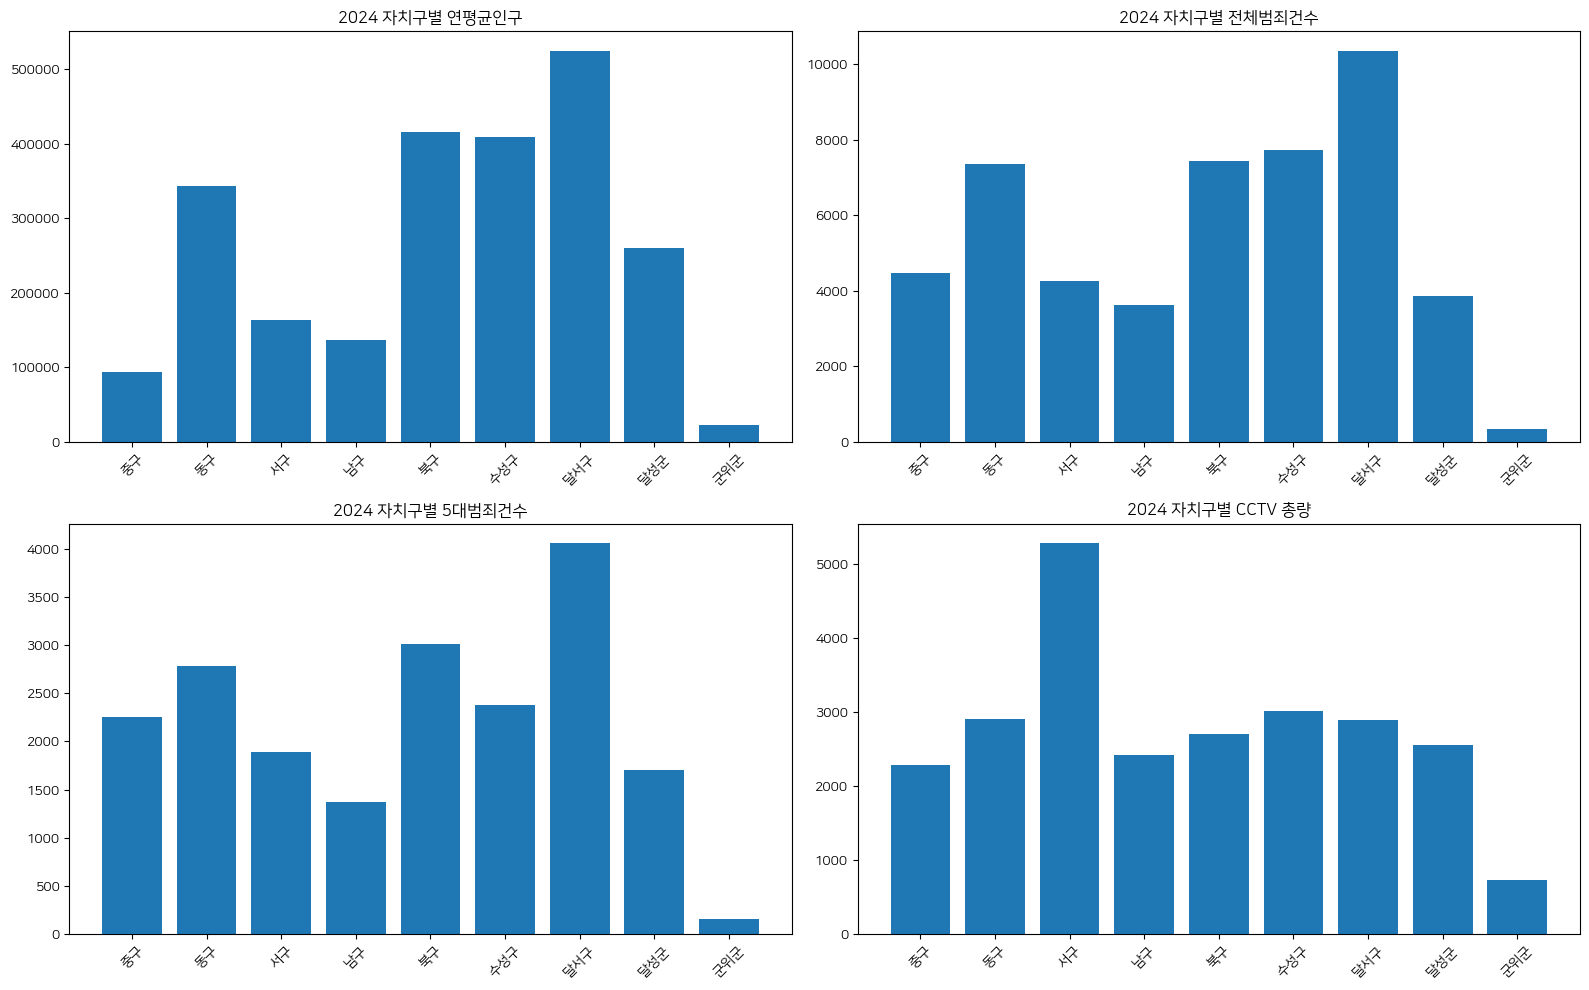

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 연평균인구
axes[0, 0].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["연평균인구"])
axes[0, 0].set_title("2024 자치구별 연평균인구")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2) 전체범죄건수
axes[0, 1].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["전체범죄건수"])
axes[0, 1].set_title("2024 자치구별 전체범죄건수")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3) 5대범죄건수
axes[1, 0].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["5대범죄건수"])
axes[1, 0].set_title("2024 자치구별 5대범죄건수")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4) CCTV총량
axes[1, 1].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["CCTV총량"])
axes[1, 1].set_title("2024 자치구별 CCTV 총량")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### 5-2-2. 전체범죄율 / 5대범죄율 / CCTV밀도 비교

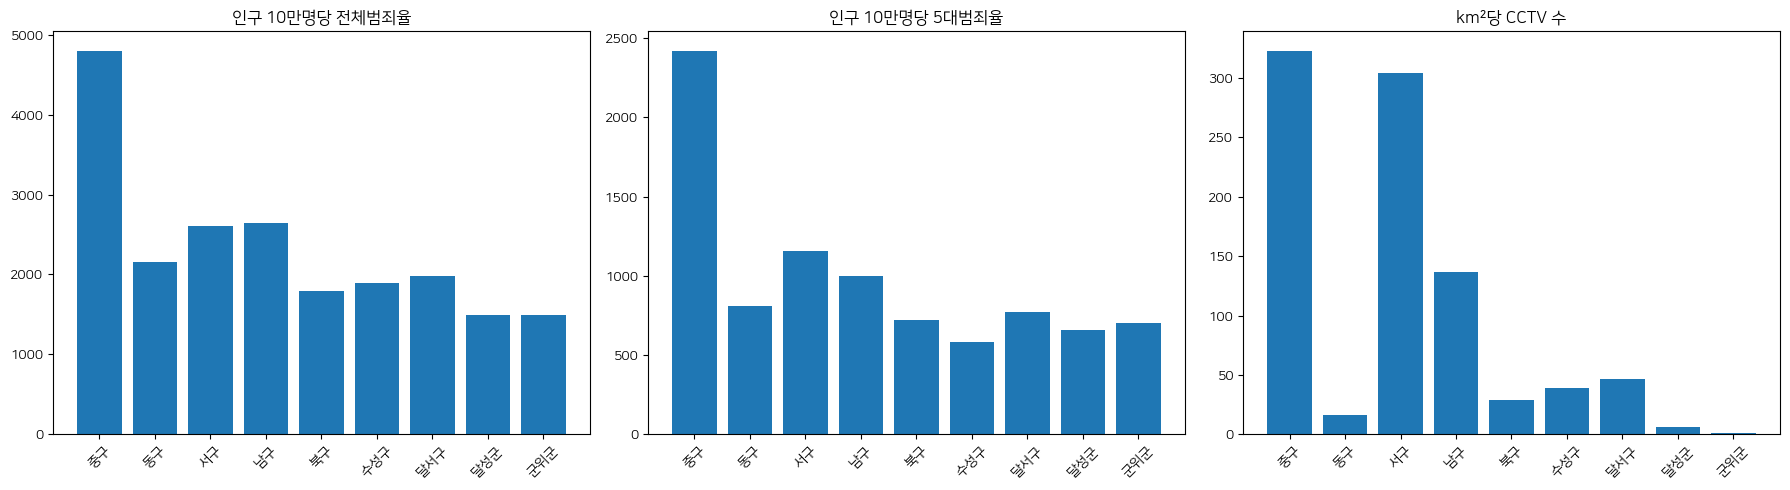

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["인구10만명당_전체범죄율"])
axes[0].set_title("인구 10만명당 전체범죄율")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["인구10만명당_5대범죄율"])
axes[1].set_title("인구 10만명당 5대범죄율")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["km2당_CCTV수"])
axes[2].set_title("km²당 CCTV 수")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 5-3. 전체 범죄와 5대범죄 구조 비교

##### 5-3-1. 전체 범죄와 5대범죄 구조 비교

In [ ]:
crime_structure_cols = ["자치구", "전체범죄건수", "5대범죄건수", "5대범죄비중", "폭력비중"]
crime_structure_cols = [c for c in crime_structure_cols if c in eda_2024_df.columns]

crime_structure_df = eda_2024_df[crime_structure_cols].copy()
display(crime_structure_df)

,자치구,전체범죄건수,5대범죄건수,5대범죄비중,폭력비중
0,중구,4475,2258,0.504581,0.352081
1,동구,7371,2784,0.377696,0.460848
2,서구,4263,1894,0.444288,0.400739
3,남구,3617,1367,0.377938,0.422824
4,북구,7443,3009,0.404272,0.414091
5,수성구,7731,2374,0.307075,0.482730
6,달서구,10355,4054,0.391502,0.433152
7,달성군,3859,1703,0.441306,0.395185
8,군위군,338,159,0.470414,0.371069


##### 5-3-2. 5대범죄 비중 / 폭력 비중 시각화

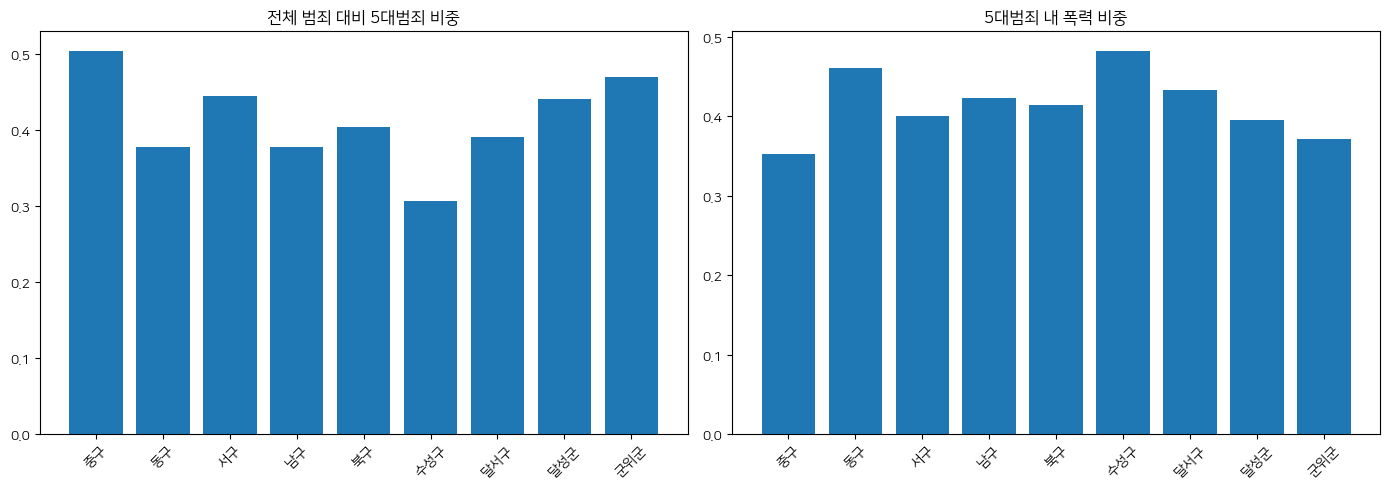

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["5대범죄비중"])
axes[0].set_title("전체 범죄 대비 5대범죄 비중")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(eda_2024_df["자치구"].astype(str), eda_2024_df["폭력비중"])
axes[1].set_title("5대범죄 내 폭력 비중")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### 5-3-3. 5대범죄 세부 구성(살인/강도/성범죄/절도/폭력) 누적막대그래프

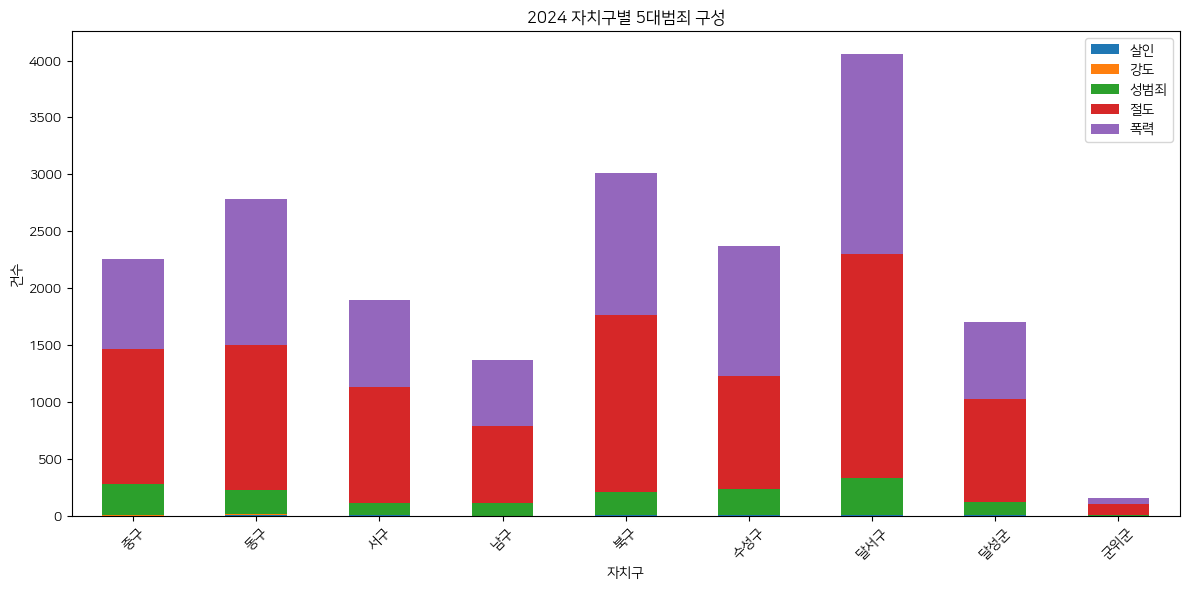

In [ ]:
five_cols = ["살인", "강도", "성범죄", "절도", "폭력"]
five_stack_df = eda_2024_df[["자치구"] + five_cols].copy().set_index("자치구")

ax = five_stack_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
ax.set_title("2024 자치구별 5대범죄 구성")
ax.set_xlabel("자치구")
ax.set_ylabel("건수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5-4. CCTV 설치목적 비교

##### 5-4-1. CCTV 설치목적 비교

In [ ]:
cctv_purpose_cols = [
    "방범",
    "교통관리",
    "어린이 보호구역",
    "재난재해",
    "도시공원 놀이터",
    "쓰레기 투기감시",
    "청사, 시설, 문화재관리",
    "미분류",
]

cctv_purpose_df = eda_2024_df[["자치구"] + cctv_purpose_cols].copy()
display(cctv_purpose_df)

,자치구,방범,교통관리,어린이 보호구역,재난재해,도시공원 놀이터,쓰레기 투기감시,"청사, 시설, 문화재관리",미분류
0,중구,1231.0,121.0,165.0,2.0,58.0,164.0,506.0,33.0
1,동구,1245.0,173.0,476.0,49.0,246.0,174.0,547.0,0.0
2,서구,3958.0,0.0,915.0,1.0,0.0,0.0,109.0,296.0
3,남구,1009.0,118.0,222.0,17.0,156.0,423.0,479.0,0.0
4,북구,942.0,445.0,478.0,49.0,157.0,136.0,499.0,0.0
5,수성구,1574.0,244.0,458.0,81.0,0.0,44.0,278.0,338.0
6,달서구,2163.0,0.0,417.0,0.0,320.0,0.0,0.0,0.0
7,달성군,16.0,237.0,178.0,100.0,155.0,148.0,408.0,1314.0
8,군위군,506.0,0.0,42.0,9.0,0.0,36.0,0.0,137.0


##### 5-4-2. 설치목적별 절대량 누적막대그래프

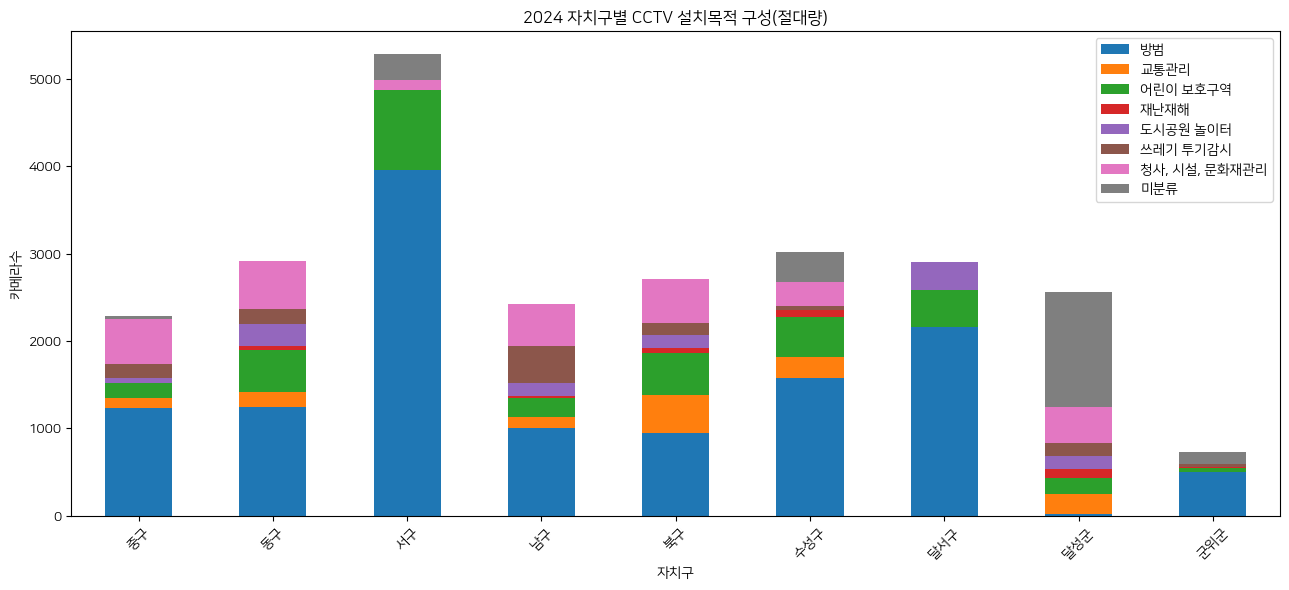

In [ ]:
ax = cctv_purpose_df.set_index("자치구").plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6)
)
ax.set_title("2024 자치구별 CCTV 설치목적 구성(절대량)")
ax.set_xlabel("자치구")
ax.set_ylabel("카메라수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 5-4-3. 설치목적 비중 비교(핵심 목적 중심)

In [ ]:
purpose_ratio_cols = [
    "방범CCTV비중",
    "교통관리CCTV비중",
    "재난재해CCTV비중",
    "어린이보호구역CCTV비중",
    "청사시설문화재관리CCTV비중",
    "미분류CCTV비중",
]
purpose_ratio_cols = [c for c in purpose_ratio_cols if c in eda_2024_df.columns]

purpose_ratio_df = eda_2024_df[["자치구"] + purpose_ratio_cols].copy()
display(purpose_ratio_df)

,자치구,방범CCTV비중,교통관리CCTV비중,재난재해CCTV비중,어린이보호구역CCTV비중,청사시설문화재관리CCTV비중,미분류CCTV비중
0,중구,0.539912,0.053070,0.000877,0.072368,0.221930,0.014474
1,동구,0.427835,0.059450,0.016838,0.163574,0.187973,0.000000
2,서구,0.749763,0.000000,0.000189,0.173328,0.020648,0.056071
3,남구,0.416254,0.048680,0.007013,0.091584,0.197607,0.000000
4,북구,0.348115,0.164449,0.018108,0.176644,0.184405,0.000000
5,수성구,0.521710,0.080875,0.026848,0.151806,0.092145,0.112032
6,달서구,0.745862,0.000000,0.000000,0.143793,0.000000,0.000000
7,달성군,0.006260,0.092723,0.039124,0.069640,0.159624,0.514085
8,군위군,0.693151,0.000000,0.012329,0.057534,0.000000,0.187671


##### 5-4-4. 방범 CCTV 비중 단독 확인

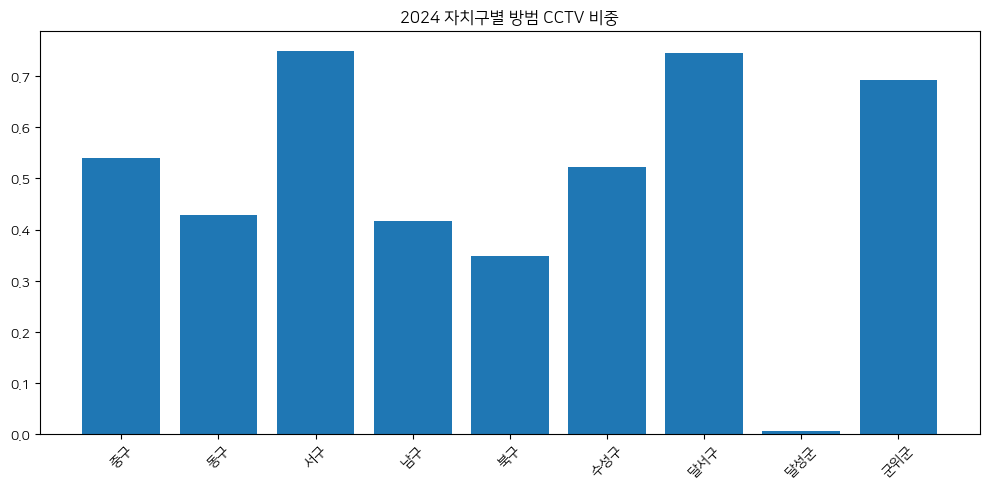

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(eda_2024_df["자치구"].astype(str), eda_2024_df["방범CCTV비중"])
plt.title("2024 자치구별 방범 CCTV 비중")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5-5. 용도지역 특성 비교

##### 5-5-1. 용도지역 특성 비교

In [ ]:
landuse_ratio_df = eda_2024_df[
    ["자치구", "주거지역비율", "상업지역비율", "공업지역비율"]
].copy()

display(landuse_ratio_df)

,자치구,주거지역비율,상업지역비율,공업지역비율
0,중구,0.478771,0.442476,0.000000
1,동구,0.114654,0.020323,0.005385
2,서구,0.439020,0.074561,0.235206
3,남구,0.456615,0.058919,0.000000
4,북구,0.215026,0.037500,0.053814
5,수성구,0.247419,0.025974,0.000000
6,달서구,0.335290,0.039203,0.183035
7,달성군,0.051990,0.003002,0.047290
8,군위군,0.001637,0.000241,0.000000


##### 5-5-2. 용도지역 비율 누적막대그래프

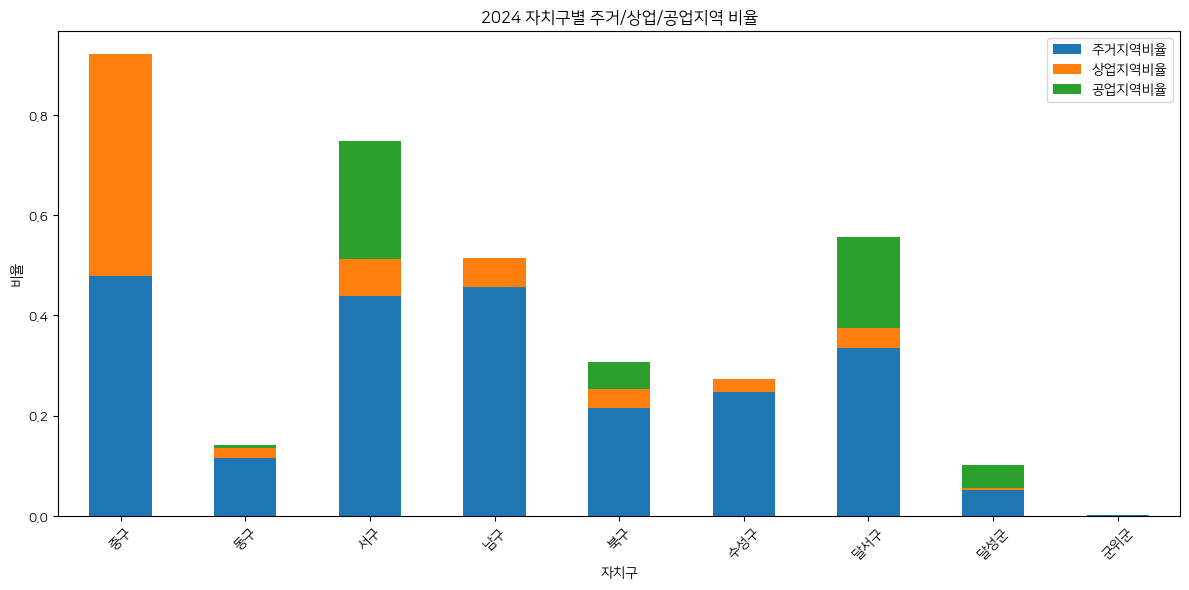

In [ ]:
ax = landuse_ratio_df.set_index("자치구").plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
ax.set_title("2024 자치구별 주거/상업/공업지역 비율")
ax.set_xlabel("자치구")
ax.set_ylabel("비율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5-6. 변수 간 관계 탐색

##### 5-6-1. 인구 10만명당 5대범죄율 vs 인구 10만명당 CCTV 수

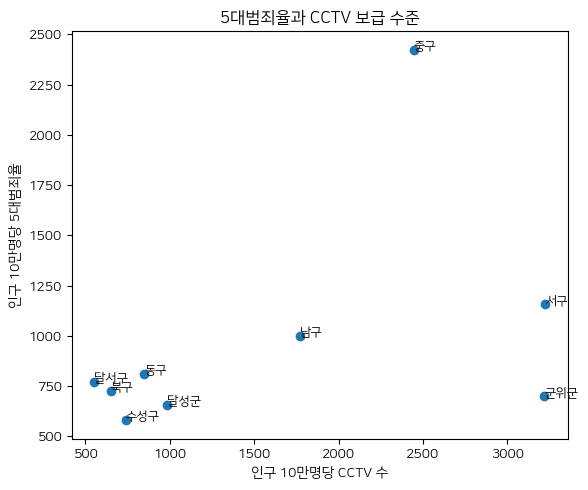

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(eda_2024_df["인구10만명당_CCTV수"], eda_2024_df["인구10만명당_5대범죄율"])
for _, row in eda_2024_df.iterrows():
    plt.text(row["인구10만명당_CCTV수"], row["인구10만명당_5대범죄율"], str(row["자치구"]), fontsize=9)
plt.xlabel("인구 10만명당 CCTV 수")
plt.ylabel("인구 10만명당 5대범죄율")
plt.title("5대범죄율과 CCTV 보급 수준")
plt.tight_layout()
plt.show()

##### 5-6-2. 인구 10만명당 5대범죄율 vs km2당 CCTV 수

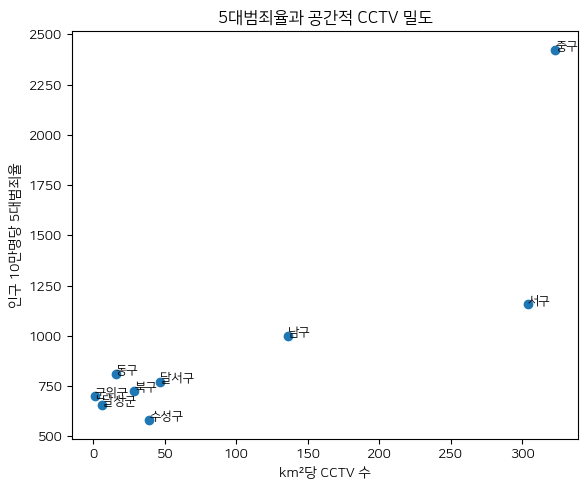

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(eda_2024_df["km2당_CCTV수"], eda_2024_df["인구10만명당_5대범죄율"])
for _, row in eda_2024_df.iterrows():
    plt.text(row["km2당_CCTV수"], row["인구10만명당_5대범죄율"], str(row["자치구"]), fontsize=9)
plt.xlabel("km²당 CCTV 수")
plt.ylabel("인구 10만명당 5대범죄율")
plt.title("5대범죄율과 공간적 CCTV 밀도")
plt.tight_layout()
plt.show()

##### 5-6-3. 인구 10만명당 5대범죄율 vs 방범 CCTV 비중

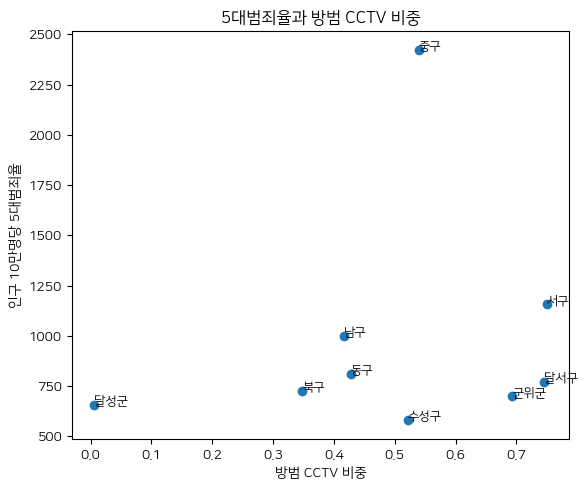

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(eda_2024_df["방범CCTV비중"], eda_2024_df["인구10만명당_5대범죄율"])
for _, row in eda_2024_df.iterrows():
    plt.text(row["방범CCTV비중"], row["인구10만명당_5대범죄율"], str(row["자치구"]), fontsize=9)
plt.xlabel("방범 CCTV 비중")
plt.ylabel("인구 10만명당 5대범죄율")
plt.title("5대범죄율과 방범 CCTV 비중")
plt.tight_layout()
plt.show()

##### 5-6-4. 인구 10만명당 전체범죄율 vs 상업지역비율

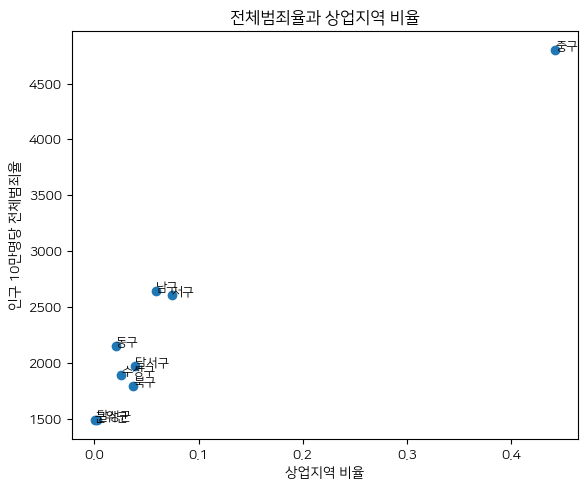

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(eda_2024_df["상업지역비율"], eda_2024_df["인구10만명당_전체범죄율"])
for _, row in eda_2024_df.iterrows():
    plt.text(row["상업지역비율"], row["인구10만명당_전체범죄율"], str(row["자치구"]), fontsize=9)
plt.xlabel("상업지역 비율")
plt.ylabel("인구 10만명당 전체범죄율")
plt.title("전체범죄율과 상업지역 비율")
plt.tight_layout()
plt.show()

##### 5-6-5. 인구 10만명당 전체범죄율 vs 주거지역비율

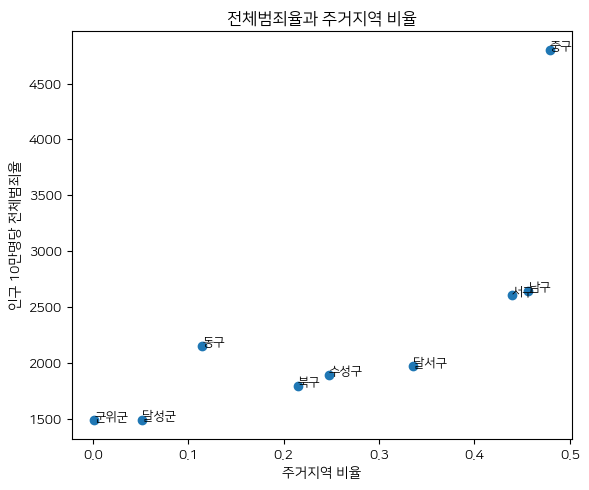

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(eda_2024_df["주거지역비율"], eda_2024_df["인구10만명당_전체범죄율"])
for _, row in eda_2024_df.iterrows():
    plt.text(row["주거지역비율"], row["인구10만명당_전체범죄율"], str(row["자치구"]), fontsize=9)
plt.xlabel("주거지역 비율")
plt.ylabel("인구 10만명당 전체범죄율")
plt.title("전체범죄율과 주거지역 비율")
plt.tight_layout()
plt.show()

### 5-7. 상관행렬 확인

##### 5-7-1. 상관행렬 확인

In [ ]:
corr_cols = [
    "인구10만명당_전체범죄율",
    "인구10만명당_5대범죄율",
    "인구10만명당_CCTV수",
    "km2당_CCTV수",
    "범죄1건당_CCTV수",
    "5대범죄1건당_CCTV수",
    "방범CCTV비중",
    "교통관리CCTV비중",
    "재난재해CCTV비중",
    "주거지역비율",
    "상업지역비율",
    "공업지역비율",
]
corr_cols = [c for c in corr_cols if c in eda_2024_df.columns]

corr_df = eda_2024_df[corr_cols].corr()
display(corr_df)

,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,범죄1건당_CCTV수,5대범죄1건당_CCTV수,방범CCTV비중,교통관리CCTV비중,재난재해CCTV비중,주거지역비율,상업지역비율,공업지역비율
인구10만명당_전체범죄율,1.000000,0.977635,0.350145,0.845639,-0.202300,-0.252165,0.204546,-0.134330,-0.564495,0.731856,0.962931,-0.085715
인구10만명당_5대범죄율,0.977635,1.000000,0.436846,0.834532,-0.082444,-0.151274,0.184912,-0.151958,-0.540963,0.631093,0.980678,-0.065458
인구10만명당_CCTV수,0.350145,0.436846,1.000000,0.590765,0.817292,0.793203,0.466384,-0.582649,-0.469942,0.191629,0.316660,0.133007
km2당_CCTV수,0.845639,0.834532,0.590765,1.000000,0.026291,-0.004823,0.361188,-0.305419,-0.642369,0.818343,0.760602,0.323487
범죄1건당_CCTV수,-0.202300,-0.082444,0.817292,0.026291,1.000000,0.992657,0.348050,-0.514620,-0.127937,-0.332777,-0.175504,0.015623
5대범죄1건당_CCTV수,-0.252165,-0.151274,0.793203,-0.004823,0.992657,1.000000,0.349733,-0.511622,-0.098343,-0.329048,-0.244231,0.002698
방범CCTV비중,0.204546,0.184912,0.466384,0.361188,0.348050,0.349733,1.000000,-0.715808,-0.801959,0.371908,0.141730,0.447485
교통관리CCTV비중,-0.134330,-0.151958,-0.582649,-0.305419,-0.514620,-0.511622,-0.715808,1.000000,0.596511,-0.196389,-0.047625,-0.405491
재난재해CCTV비중,-0.564495,-0.540963,-0.469942,-0.642369,-0.127937,-0.098343,-0.801959,0.596511,1.000000,-0.694431,-0.459019,-0.432188
주거지역비율,0.731856,0.631093,0.191629,0.818343,-0.332777,-0.329048,0.371908,-0.196389,-0.694431,1.000000,0.597368,0.335136


##### 5-7-2. matplotlib 기반 상관행렬 히트맵

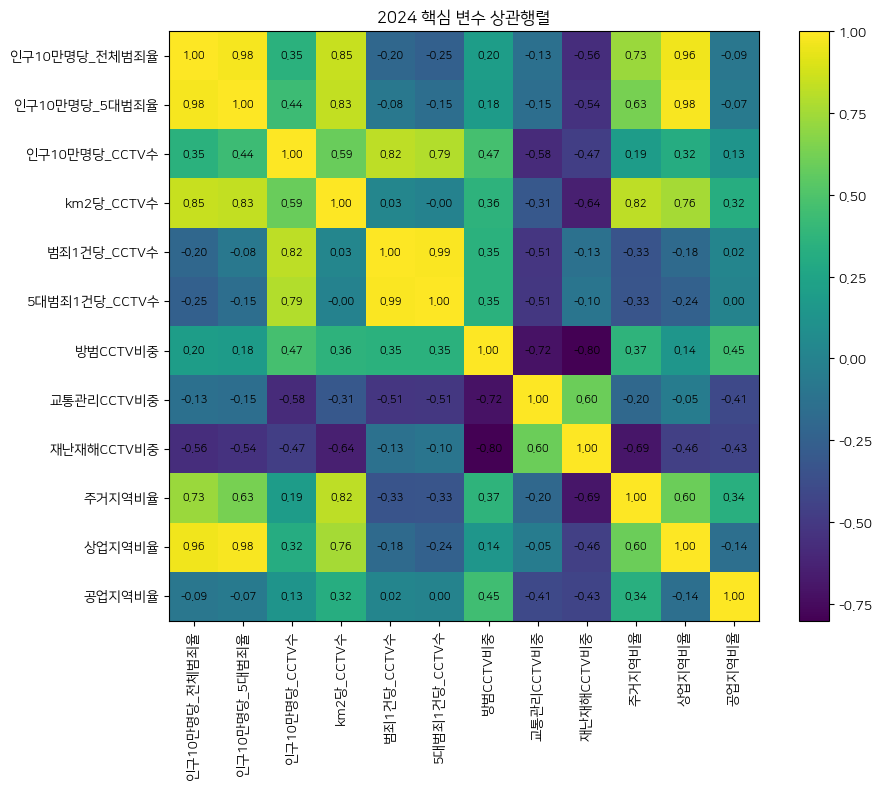

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_df.values)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticklabels(corr_df.index)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("2024 핵심 변수 상관행렬")
fig.colorbar(im)
plt.tight_layout()
plt.show()

### 5-8. 장기 비교(군위군 제외) 추이 확인

##### 5-8-1. 연도별 대구 8개 자치구 평균 전체 범죄율

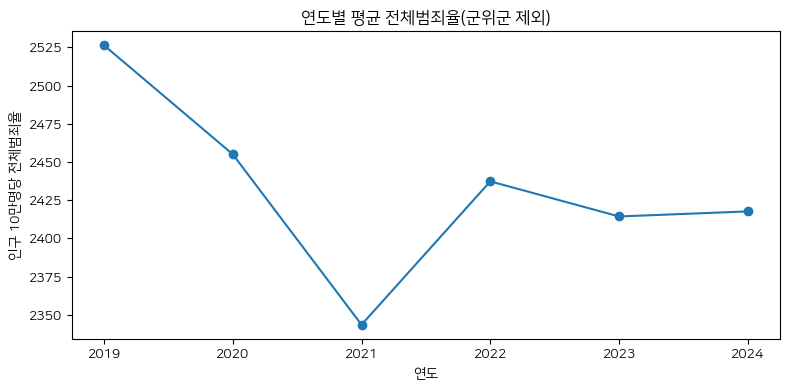

In [ ]:
yearly_avg_total = (
    eda_long_df.groupby("연도", as_index=False)["인구10만명당_전체범죄율"]
    .mean()
)

plt.figure(figsize=(8, 4))
plt.plot(yearly_avg_total["연도"], yearly_avg_total["인구10만명당_전체범죄율"], marker="o")
plt.title("연도별 평균 전체범죄율(군위군 제외)")
plt.xlabel("연도")
plt.ylabel("인구 10만명당 전체범죄율")
plt.xticks(yearly_avg_total["연도"])
plt.tight_layout()
plt.show()

##### 5-8-2. 연도별 평균 5대범죄율

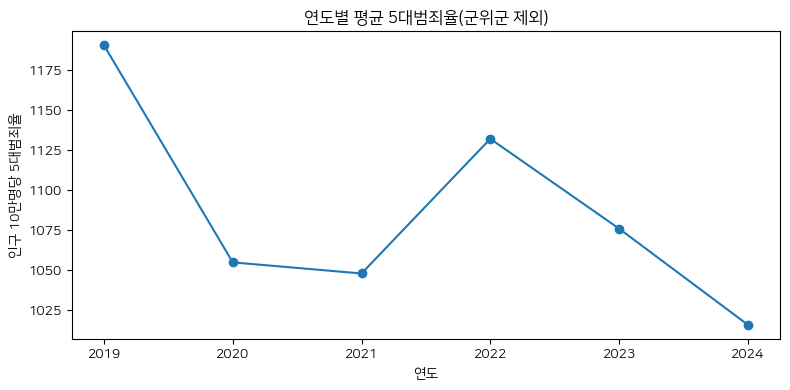

In [ ]:
yearly_avg_five = (
    eda_long_df.groupby("연도", as_index=False)["인구10만명당_5대범죄율"]
    .mean()
)

plt.figure(figsize=(8, 4))
plt.plot(yearly_avg_five["연도"], yearly_avg_five["인구10만명당_5대범죄율"], marker="o")
plt.title("연도별 평균 5대범죄율(군위군 제외)")
plt.xlabel("연도")
plt.ylabel("인구 10만명당 5대범죄율")
plt.xticks(yearly_avg_five["연도"])
plt.tight_layout()
plt.show()

##### 5-8-3. 자치구별 전체범죄율 장기 추이

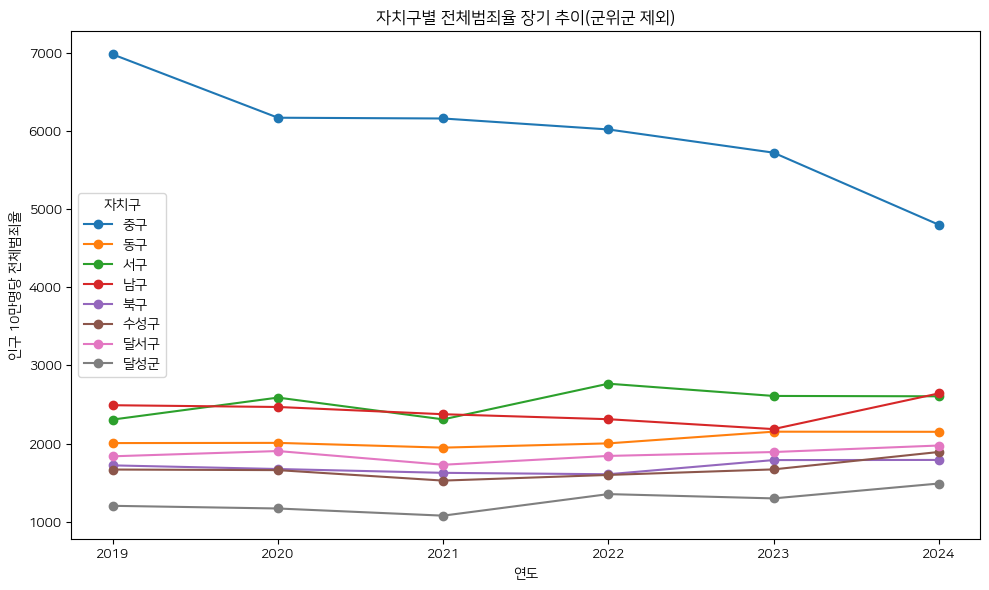

In [ ]:
pivot_total_rate = eda_long_df.pivot(index="연도", columns="자치구", values="인구10만명당_전체범죄율")

ax = pivot_total_rate.plot(figsize=(10, 6), marker="o")
ax.set_title("자치구별 전체범죄율 장기 추이(군위군 제외)")
ax.set_xlabel("연도")
ax.set_ylabel("인구 10만명당 전체범죄율")
plt.xticks(pivot_total_rate.index)
plt.tight_layout()
plt.show()

### 5-9. 2024 지도 시각화

In [ ]:
eda_map_gdf = geo_2024_df.merge(
    eda_2024_df.drop(columns=["자치구총면적_km2"]),
    on="자치구",
    how="left"
)

print("[eda_map_gdf]")
display(eda_map_gdf[["자치구", "인구10만명당_전체범죄율", "인구10만명당_5대범죄율", "km2당_CCTV수"]].head())

[eda_map_gdf]


,자치구,인구10만명당_전체범죄율,인구10만명당_5대범죄율,km2당_CCTV수
0,중구,4801.278910,2422.634141,323.231540
1,동구,2150.174830,812.113245,16.005199
2,서구,2604.575573,1157.181828,303.968197
3,남구,2641.405634,998.286287,136.555951
4,북구,1790.050824,723.668269,28.882682


##### 5-9-1. 전체범죄율 지도

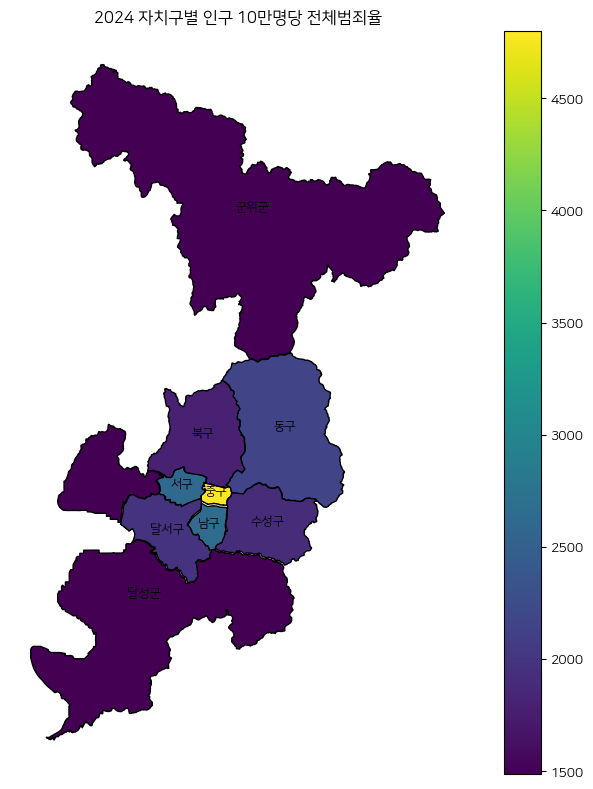

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
eda_map_gdf.plot(column="인구10만명당_전체범죄율", legend=True, ax=ax, edgecolor="black")
for _, row in eda_map_gdf.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, row["자치구"], fontsize=9, ha="center")
ax.set_title("2024 자치구별 인구 10만명당 전체범죄율")
ax.set_axis_off()
plt.tight_layout()
plt.show()

##### 5-9-2. 5대범죄율 지도

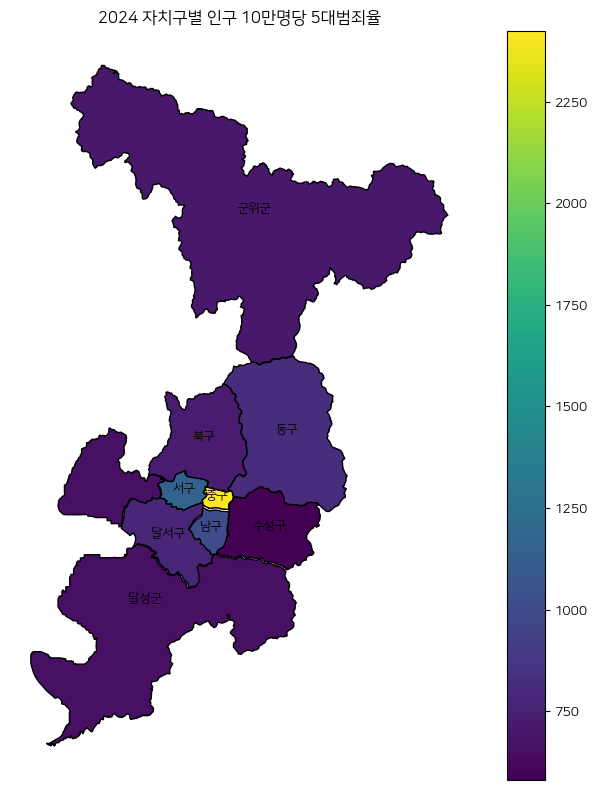

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
eda_map_gdf.plot(column="인구10만명당_5대범죄율", legend=True, ax=ax, edgecolor="black")
for _, row in eda_map_gdf.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, row["자치구"], fontsize=9, ha="center")
ax.set_title("2024 자치구별 인구 10만명당 5대범죄율")
ax.set_axis_off()
plt.tight_layout()
plt.show()

##### 5-9-3. km2당 CCTV 수 지도

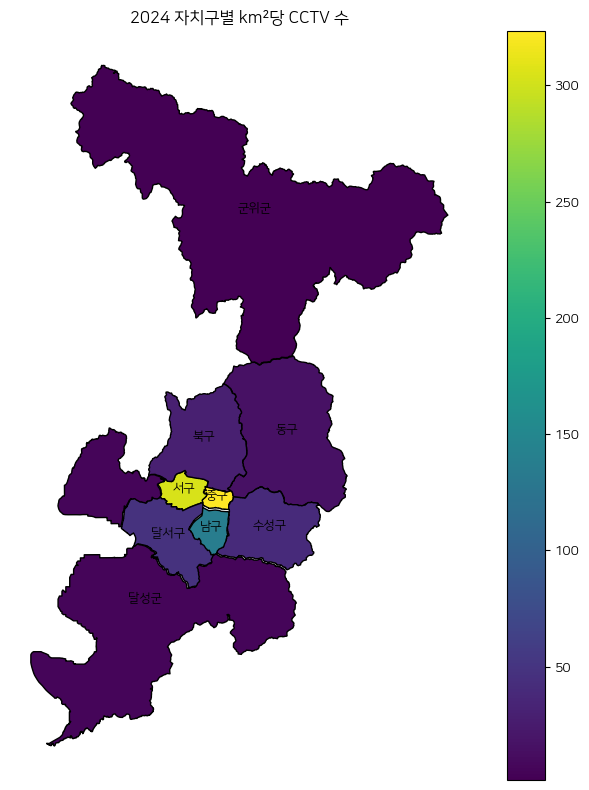

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
eda_map_gdf.plot(column="km2당_CCTV수", legend=True, ax=ax, edgecolor="black")
for _, row in eda_map_gdf.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, row["자치구"], fontsize=9, ha="center")
ax.set_title("2024 자치구별 km²당 CCTV 수")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 5-10. EDA 결과 저장용 정리 테이블

##### 5-10-1. EDA 결과 저장용 정리 테이블

In [ ]:
eda_summary_cols = [
    "자치구",
    "연평균인구",
    "전체범죄건수",
    "5대범죄건수",
    "CCTV총량",
    "자치구총면적_km2",
    "인구10만명당_전체범죄율",
    "인구10만명당_5대범죄율",
    "인구10만명당_CCTV수",
    "km2당_CCTV수",
    "5대범죄비중",
    "폭력비중",
    "방범CCTV비중",
    "상업지역비율",
    "주거지역비율",
    "공업지역비율",
]
eda_summary_cols = [c for c in eda_summary_cols if c in eda_2024_df.columns]

eda_summary_2024_df = eda_2024_df[eda_summary_cols].copy()
display(eda_summary_2024_df.sort_values("자치구").reset_index(drop=True))

,자치구,연평균인구,전체범죄건수,5대범죄건수,CCTV총량,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,5대범죄비중,폭력비중,방범CCTV비중,상업지역비율,주거지역비율,공업지역비율
0,중구,93204.333333,4475,2258,2280.0,7.053767,4801.278910,2422.634141,2446.238194,323.231540,0.504581,0.352081,0.539912,0.442476,0.478771,0.000000
1,동구,342809.333333,7371,2784,2910.0,181.815921,2150.174830,812.113245,848.868370,16.005199,0.377696,0.460848,0.427835,0.020323,0.114654,0.005385
2,서구,163673.5,4263,1894,5279.0,17.366948,2604.575573,1157.181828,3225.323586,303.968197,0.444288,0.400739,0.749763,0.074561,0.439020,0.235206
3,남구,136934.666667,3617,1367,2424.0,17.750966,2641.405634,998.286287,1770.187243,136.555951,0.377938,0.422824,0.416254,0.058919,0.456615,0.000000
4,북구,415798.25,7443,3009,2706.0,93.689359,1790.050824,723.668269,650.796390,28.882682,0.404272,0.414091,0.348115,0.037500,0.215026,0.053814
5,수성구,408687.333333,7731,2374,3017.0,76.709987,1891.666164,580.884164,738.217154,39.329950,0.307075,0.482730,0.521710,0.025974,0.247419,0.000000
6,달서구,524412.833333,10355,4054,2900.0,62.294304,1974.589358,773.055071,552.999434,46.553213,0.391502,0.433152,0.745862,0.039203,0.335290,0.183035
7,달성군,259352.333333,3859,1703,2556.0,418.330739,1487.937259,656.635696,985.531908,6.109998,0.441306,0.395185,0.006260,0.003002,0.051990,0.047290
8,군위군,22672.5,338,159,730.0,613.515544,1490.792811,701.290109,3219.759621,1.189864,0.470414,0.371069,0.693151,0.000241,0.001637,0.000000


##### 5-10-2. 저장

In [ ]:
eda_summary_2024_df.to_csv(
    os.path.join(output_path, "eda_summary_2024.csv"),
    index=False,
    encoding="utf-8-sig"
)

corr_df.to_csv(
    os.path.join(output_path, "eda_corr_2024.csv"),
    encoding="utf-8-sig"
)

print("EDA 요약 결과 저장 완료")

EDA 요약 결과 저장 완료


# 6. 결과 정리 및 인사이트 도출

### 6-0. 결과 정리용 데이터 준비

In [ ]:
result_2024_df = (
    analysis_2024_core_df
    .merge(analysis_2024_check_df, on="자치구", how="left")
    .copy()
)
if "좌표유효CCTV수_x" in result_2024_df.columns and "좌표유효CCTV수_y" in result_2024_df.columns:
    result_2024_df["좌표유효CCTV수"] = result_2024_df["좌표유효CCTV수_y"]
    result_2024_df = result_2024_df.drop(columns=["좌표유효CCTV수_x", "좌표유효CCTV수_y"])


result_long_df = analysis_long_core_df.copy()

# 좌표/품질 보조 지표
result_2024_df["원본좌표CCTV비중"] = safe_divide(
    result_2024_df["원본좌표채택CCTV수"],
    result_2024_df["CCTV총량"]
)

result_2024_df["카카오좌표CCTV비중"] = safe_divide(
    result_2024_df["카카오좌표채택CCTV수"],
    result_2024_df["CCTV총량"]
)

# CCTV 총량 해석 주의 등급
result_2024_df["CCTV해석주의등급"] = np.select(
    [
        result_2024_df["카메라수결측대체비율"] >= 0.8,
        result_2024_df["카메라수결측대체비율"] >= 0.3,
    ],
    [
        "높음",
        "중간",
    ],
    default="낮음"
)

# 좌표 활용 가능성 등급
result_2024_df["좌표활용등급"] = np.select(
    [
        result_2024_df["좌표유효CCTV비율"] >= 0.90,
        result_2024_df["좌표유효CCTV비율"] >= 0.70,
    ],
    [
        "양호",
        "보통",
    ],
    default="제한적"
)

print("[result_2024_df]")
display(result_2024_df.sort_values("자치구").reset_index(drop=True))

print("\n[result_long_df]")
display(result_long_df.head(20))

[result_2024_df]


,자치구,연평균인구,전체범죄건수,5대범죄건수,강도,살인,성범죄,절도,폭력,CCTV총량,방범,교통관리,도시공원 놀이터,쓰레기 투기감시,어린이 보호구역,재난재해,"청사, 시설, 문화재관리",미분류,주거지역면적_km2,상업지역면적_km2,공업지역면적_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,범죄1건당_CCTV수,5대범죄1건당_CCTV수,5대범죄비중,폭력비중,방범CCTV비중,교통관리CCTV비중,재난재해CCTV비중,어린이보호구역CCTV비중,청사시설문화재관리CCTV비중,미분류CCTV비중,주거지역비율,상업지역비율,공업지역비율,좌표유효행수,원본좌표채택행수,카카오좌표채택행수,원본좌표채택CCTV수,카카오좌표채택CCTV수,설치연도존재행수,설치목적미분류행수,카메라수결측대체행수,좌표유효행비율,좌표유효CCTV비율,카메라수결측대체비율,용도지역총합_km2,용도지역면적_총면적비율,좌표유효CCTV수,원본좌표CCTV비중,카카오좌표CCTV비중,CCTV해석주의등급,좌표활용등급
0,군위군,22672.5,338,159,0,0,7,93,59,730.0,506.0,0.0,0.0,36.0,42.0,9.0,0.0,137.0,1.004398,0.147666,0.0,613.515544,1490.792811,701.290109,3219.759621,1.189864,2.159763,4.591195,0.470414,0.371069,0.693151,0.000000,0.012329,0.057534,0.000000,0.187671,0.001637,0.000241,0.000000,420,0,420,0.0,694.0,0,28,0,0.9481,0.950685,0.0,614.340248,1.001344,694.0,0.000000,0.950685,낮음,양호
1,남구,136934.666667,3617,1367,0,0,108,681,578,2424.0,1009.0,118.0,156.0,423.0,222.0,17.0,479.0,0.0,8.105365,1.045866,0.0,17.750966,2641.405634,998.286287,1770.187243,136.555951,0.670169,1.773226,0.377938,0.422824,0.416254,0.048680,0.007013,0.091584,0.197607,0.000000,0.456615,0.058919,0.000000,2180,0,2180,0.0,2180.0,2424,0,2424,0.8993,0.899340,1.0,17.429327,0.981881,2180.0,0.000000,0.899340,높음,보통
2,달서구,524412.833333,10355,4054,1,8,326,1963,1756,2900.0,2163.0,0.0,320.0,0.0,417.0,0.0,0.0,0.0,20.886684,2.442133,11.402022,62.294304,1974.589358,773.055071,552.999434,46.553213,0.280058,0.715343,0.391502,0.433152,0.745862,0.000000,0.000000,0.143793,0.000000,0.000000,0.335290,0.039203,0.183035,2854,2854,0,2854.0,0.0,2900,0,0,0.9841,0.984138,0.0,62.369706,1.001210,2854.0,0.984138,0.000000,낮음,양호
3,달성군,259352.333333,3859,1703,0,4,115,911,673,2556.0,16.0,237.0,155.0,148.0,178.0,100.0,408.0,1314.0,21.748914,1.255897,19.782892,418.330739,1487.937259,656.635696,985.531908,6.109998,0.662348,1.500881,0.441306,0.395185,0.006260,0.092723,0.039124,0.069640,0.159624,0.514085,0.051990,0.003002,0.047290,2326,0,2326,0.0,2326.0,2554,1314,2556,0.9100,0.910016,1.0,428.37186,1.024003,2326.0,0.000000,0.910016,높음,양호
4,동구,342809.333333,7371,2784,10,4,215,1272,1283,2910.0,1245.0,173.0,246.0,174.0,476.0,49.0,547.0,0.0,20.845992,3.695053,0.979024,181.815921,2150.174830,812.113245,848.868370,16.005199,0.394790,1.045259,0.377696,0.460848,0.427835,0.059450,0.016838,0.163574,0.187973,0.000000,0.114654,0.020323,0.005385,1791,0,1791,0.0,1791.0,2910,0,2910,0.6155,0.615464,1.0,182.114642,1.001643,1791.0,0.000000,0.615464,높음,제한적
5,북구,415798.25,7443,3009,2,4,204,1553,1246,2706.0,942.0,445.0,157.0,136.0,478.0,49.0,499.0,0.0,20.145615,3.513338,5.041777,93.689359,1790.050824,723.668269,650.796390,28.882682,0.363563,0.899302,0.404272,0.414091,0.348115,0.164449,0.018108,0.176644,0.184405,0.000000,0.215026,0.037500,0.053814,1894,0,1894,0.0,1894.0,2706,0,2706,0.6999,0.699926,1.0,93.956459,1.002851,1894.0,0.000000,0.699926,높음,제한적
6,서구,163673.5,4263,1894,2,3,105,1025,759,5279.0,3958.0,0.0,0.0,0.0,915.0,1.0,109.0,296.0,7.624438,1.294895,4.084803,17.366948,2604.575573,1157.181828,3225.323586,303.968197,1.238330,2.787223,0.444288,0.400739,0.749763,0.000000,0.000189,0.173328,0.020648,0.056071,0.439020,0.074561,0.235206,4749,4749,0,4779.0,0.0,1300,296,0,0.9047,0.905285,0.0,17.316793,0.997112,4779.0,0.905285,0.000000,낮음,양호
7,수성구,408687.333333,7731,2374,0,8,229,991,1146,3017.0,1574.0,244.0,0.0,44.0,458.0,81.0,278.0,338.0,18.979472,1.992468,0.0,76.709987,1891.666164,580.884164,738.217154,39.329950,0.390247,1.270851,0.307075,0.482730,0.521710,0.080875,0.026848,0.151806,0.092145,0.112032,0.247419,0.025974,0.000000,2971,2971,0,2971.0,0.0,0,338,0,0.9848,0.984753,0.0,76.537392,0.997750,2971.0,0.984753,0.000000,낮음,양호
8,중구,93204.333333,4475,2258,1,2,272,1188,795,2280.0,1231.0,121.0,58.0,164.0,165.0,2.0,506.0,33.0,3.37714,3.121126,0.0,7.053767,4801.278910,2422.634141,2446.238194,323.231540,0.509497,1.009743,0.504581,0.352081,0.539912,0.053070,0.000877,0.072368,0.221930,0.014474,0.478771,0.442476,0.000000,1783,0,1783,0.0,178


[result_long_df]


,연도,자치구,연평균인구,전체범죄건수,5대범죄건수,강도,살인,성범죄,절도,폭력,주거지역면적_km2,상업지역면적_km2,공업지역면적_km2,자치구총면적_km2,인구10만명당_전체범죄율,인구10만명당_5대범죄율,5대범죄비중,폭력비중,주거지역비율,상업지역비율,공업지역비율
0,2019,남구,148814.083333,3706,1692,2,4,89,726,871,8.105365,1.045866,0.0,17.750816,2490.355696,1136.989163,0.456557,0.514775,0.456619,0.058919,0.000000
1,2019,달서구,571056.333333,10488,4565,8,10,276,2058,2213,20.886684,2.442133,11.402022,62.276676,1836.596389,799.395740,0.435259,0.484775,0.335385,0.039214,0.183087
2,2019,달성군,254516.583333,3061,1477,2,6,92,631,746,21.749051,1.351497,19.734128,419.374226,1202.672125,580.315821,0.482522,0.505078,0.051861,0.003223,0.047056
3,2019,동구,348538.0,6991,2866,5,8,206,1265,1382,20.846917,3.695297,0.979024,181.847715,2005.807114,822.291974,0.409956,0.482205,0.114639,0.020321,0.005384
4,2019,북구,438564.166667,7545,3467,3,6,183,1340,1935,20.16204,3.49617,5.010582,93.711504,1720.386793,790.534262,0.459510,0.558119,0.215150,0.037308,0.053468
5,2019,서구,179505.25,4141,1832,7,0,81,689,1055,7.624438,1.294895,4.084592,17.372102,2306.896316,1020.582963,0.442405,0.575873,0.438890,0.074539,0.235124
6,2019,수성구,430444.666667,7176,2505,4,7,157,1099,1238,18.29906,1.930988,0.0,76.794996,1667.113233,581.956334,0.349080,0.494212,0.238285,0.025145,0.000000
7,2019,중구,78152.0,5456,2965,4,1,207,1482,1271,3.37714,3.121126,0.0,7.027542,6981.267274,3793.888832,0.543438,0.428668,0.480558,0.444128,0.000000
8,2020,남구,147372.333333,3637,1450,4,2,69,679,696,8.105365,1.045866,0.0,17.750816,2467.898769,983.902451,0.398680,0.480000,0.456619,0.058919,0.000000
9,2020,달서구,564601.416667,10749,4109,6,6,243,1867,1987,20.886684,2.442133,11.402022,62.276676,1903.820940,727.770048,0.382268,0.483573,0.335385,0.039214,0.183087


### 6-1. 2024 핵심 지표 순위 정리

In [ ]:
ranking_df = result_2024_df[
    [
        "자치구",
        "연평균인구",
        "전체범죄건수",
        "5대범죄건수",
        "CCTV총량",
        "인구10만명당_전체범죄율",
        "인구10만명당_5대범죄율",
        "인구10만명당_CCTV수",
        "km2당_CCTV수",
        "방범CCTV비중",
        "주거지역비율",
        "상업지역비율",
        "공업지역비율",
        "좌표유효CCTV비율",
        "카메라수결측대체비율",
        "CCTV해석주의등급",
        "좌표활용등급",
    ]
].copy()

rank_desc_cols = [
    "전체범죄건수",
    "5대범죄건수",
    "CCTV총량",
    "인구10만명당_전체범죄율",
    "인구10만명당_5대범죄율",
    "인구10만명당_CCTV수",
    "km2당_CCTV수",
    "방범CCTV비중",
    "상업지역비율",
]

for col in rank_desc_cols:
    ranking_df[f"{col}_순위"] = ranking_df[col].rank(method="min", ascending=False)

print("[ranking_df]")
display(ranking_df.sort_values("인구10만명당_전체범죄율_순위").reset_index(drop=True))

[ranking_df]


,자치구,연평균인구,전체범죄건수,5대범죄건수,CCTV총량,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,방범CCTV비중,주거지역비율,상업지역비율,공업지역비율,좌표유효CCTV비율,카메라수결측대체비율,CCTV해석주의등급,좌표활용등급,전체범죄건수_순위,5대범죄건수_순위,CCTV총량_순위,인구10만명당_전체범죄율_순위,인구10만명당_5대범죄율_순위,인구10만명당_CCTV수_순위,km2당_CCTV수_순위,방범CCTV비중_순위,상업지역비율_순위
0,중구,93204.333333,4475,2258,2280.0,4801.278910,2422.634141,2446.238194,323.231540,0.539912,0.478771,0.442476,0.000000,0.782018,1.0,높음,보통,5.0,5.0,8.0,1.0,1.0,3.0,1.0,4.0,1.0
1,남구,136934.666667,3617,1367,2424.0,2641.405634,998.286287,1770.187243,136.555951,0.416254,0.456615,0.058919,0.000000,0.899340,1.0,높음,보통,8.0,8.0,7.0,2.0,3.0,4.0,3.0,7.0,3.0
2,서구,163673.5,4263,1894,5279.0,2604.575573,1157.181828,3225.323586,303.968197,0.749763,0.439020,0.074561,0.235206,0.905285,0.0,낮음,양호,6.0,6.0,1.0,3.0,2.0,1.0,2.0,1.0,2.0
3,동구,342809.333333,7371,2784,2910.0,2150.174830,812.113245,848.868370,16.005199,0.427835,0.114654,0.020323,0.005385,0.615464,1.0,높음,제한적,4.0,3.0,3.0,4.0,4.0,6.0,7.0,6.0,7.0
4,달서구,524412.833333,10355,4054,2900.0,1974.589358,773.055071,552.999434,46.553213,0.745862,0.335290,0.039203,0.183035,0.984138,0.0,낮음,양호,1.0,1.0,4.0,5.0,5.0,9.0,4.0,2.0,4.0
5,수성구,408687.333333,7731,2374,3017.0,1891.666164,580.884164,738.217154,39.329950,0.521710,0.247419,0.025974,0.000000,0.984753,0.0,낮음,양호,2.0,4.0,2.0,6.0,9.0,7.0,5.0,5.0,6.0
6,북구,415798.25,7443,3009,2706.0,1790.050824,723.668269,650.796390,28.882682,0.348115,0.215026,0.037500,0.053814,0.699926,1.0,높음,제한적,3.0,2.0,5.0,7.0,6.0,8.0,6.0,8.0,5.0
7,군위군,22672.5,338,159,730.0,1490.792811,701.290109,3219.759621,1.189864,0.693151,0.001637,0.000241,0.000000,0.950685,0.0,낮음,양호,9.0,9.0,9.0,8.0,7.0,2.0,9.0,3.0,9.0
8,달성군,259352.333333,3859,1703,2556.0,1487.937259,656.635696,985.531908,6.109998,0.006260,0.051990,0.003002,0.047290,0.910016,1.0,높음,양호,7.0,7.0,6.0,9.0,8.0,5.0,8.0,9.0,8.0


### 6-2. 자치구 우선관리 점수 산정

##### 기준.
##### - 높을수록 위험:
- 인구 10만명당 전체범죄율
- 인구 10만명당 5대범죄율
- 상업지역 비율

##### - 낮을수록 관리 필요:
- km2당 CCTV 수
- 방범 CCTV 비중

In [ ]:
priority_df = result_2024_df[
    [
        "자치구",
        "인구10만명당_전체범죄율",
        "인구10만명당_5대범죄율",
        "km2당_CCTV수",
        "방범CCTV비중",
        "상업지역비율",
        "좌표유효CCTV비율",
        "카메라수결측대체비율",
        "CCTV해석주의등급",
        "좌표활용등급",
    ]
].copy()

priority_df["전체범죄율_위험순위"] = priority_df["인구10만명당_전체범죄율"].rank(method="min", ascending=False)
priority_df["5대범죄율_위험순위"] = priority_df["인구10만명당_5대범죄율"].rank(method="min", ascending=False)
priority_df["상업지역비율_위험순위"] = priority_df["상업지역비율"].rank(method="min", ascending=False)

priority_df["CCTV밀도_부족순위"] = priority_df["km2당_CCTV수"].rank(method="min", ascending=True)
priority_df["방범비중_부족순위"] = priority_df["방범CCTV비중"].rank(method="min", ascending=True)

priority_df["우선관리점수"] = (
    priority_df["전체범죄율_위험순위"] +
    priority_df["5대범죄율_위험순위"] +
    priority_df["상업지역비율_위험순위"] +
    priority_df["CCTV밀도_부족순위"] +
    priority_df["방범비중_부족순위"]
)

priority_df["관리등급"] = np.select(
    [
        priority_df["우선관리점수"] >= 28,
        priority_df["우선관리점수"] >= 23,
    ],
    [
        "우선관리",
        "주의관리",
    ],
    default="상대적 안정"
)

priority_df["최종해석메모"] = np.select(
    [
        (priority_df["CCTV해석주의등급"] == "높음") & (priority_df["좌표활용등급"] == "제한적"),
        (priority_df["CCTV해석주의등급"] == "높음"),
        (priority_df["좌표활용등급"] == "제한적"),
    ],
    [
        "CCTV 총량·좌표 모두 해석주의",
        "CCTV 총량 해석주의",
        "좌표 기반 해석 제한",
    ],
    default="핵심지표 해석 가능"
)

print("[priority_df]")
display(priority_df.sort_values(["우선관리점수", "인구10만명당_전체범죄율"], ascending=[False, False]).reset_index(drop=True))

[priority_df]


,자치구,인구10만명당_전체범죄율,인구10만명당_5대범죄율,km2당_CCTV수,방범CCTV비중,상업지역비율,좌표유효CCTV비율,카메라수결측대체비율,CCTV해석주의등급,좌표활용등급,전체범죄율_위험순위,5대범죄율_위험순위,상업지역비율_위험순위,CCTV밀도_부족순위,방범비중_부족순위,우선관리점수,관리등급,최종해석메모
0,군위군,1490.792811,701.290109,1.189864,0.693151,0.000241,0.950685,0.0,낮음,양호,8.0,7.0,9.0,1.0,7.0,32.0,우선관리,핵심지표 해석 가능
1,수성구,1891.666164,580.884164,39.329950,0.521710,0.025974,0.984753,0.0,낮음,양호,6.0,9.0,6.0,5.0,5.0,31.0,우선관리,핵심지표 해석 가능
2,달서구,1974.589358,773.055071,46.553213,0.745862,0.039203,0.984138,0.0,낮음,양호,5.0,5.0,4.0,6.0,8.0,28.0,우선관리,핵심지표 해석 가능
3,달성군,1487.937259,656.635696,6.109998,0.006260,0.003002,0.910016,1.0,높음,양호,9.0,8.0,8.0,2.0,1.0,28.0,우선관리,CCTV 총량 해석주의
4,서구,2604.575573,1157.181828,303.968197,0.749763,0.074561,0.905285,0.0,낮음,양호,3.0,2.0,2.0,8.0,9.0,24.0,주의관리,핵심지표 해석 가능
5,북구,1790.050824,723.668269,28.882682,0.348115,0.037500,0.699926,1.0,높음,제한적,7.0,6.0,5.0,4.0,2.0,24.0,주의관리,CCTV 총량·좌표 모두 해석주의
6,동구,2150.174830,812.113245,16.005199,0.427835,0.020323,0.615464,1.0,높음,제한적,4.0,4.0,7.0,3.0,4.0,22.0,상대적 안정,CCTV 총량·좌표 모두 해석주의
7,중구,4801.278910,2422.634141,323.231540,0.539912,0.442476,0.782018,1.0,높음,보통,1.0,1.0,1.0,9.0,6.0,18.0,상대적 안정,CCTV 총량 해석주의
8,남구,2641.405634,998.286287,136.555951,0.416254,0.058919,0.899340,1.0,높음,보통,2.0,3.0,3.0,7.0,3.0,18.0,상대적 안정,CCTV 총량 해석주의


### 6-2A. 좌표 기반 CCTV 활용 가능성 점검

In [ ]:
coord_use_df = result_2024_df[
    [
        "자치구",
        "CCTV총량",
        "원본좌표채택CCTV수",
        "카카오좌표채택CCTV수",
        "좌표유효CCTV비율",
        "카메라수결측대체비율",
        "CCTV해석주의등급",
        "좌표활용등급",
    ]
].copy()

coord_use_df["원본좌표CCTV비중"] = safe_divide(
    coord_use_df["원본좌표채택CCTV수"],
    coord_use_df["CCTV총량"]
)

coord_use_df["카카오보완CCTV비중"] = safe_divide(
    coord_use_df["카카오좌표채택CCTV수"],
    coord_use_df["CCTV총량"]
)

coord_use_df["좌표기반활용판단"] = np.select(
    [
        (coord_use_df["좌표유효CCTV비율"] >= 0.90) & (coord_use_df["카메라수결측대체비율"] < 0.30),
        (coord_use_df["좌표유효CCTV비율"] >= 0.70) & (coord_use_df["카메라수결측대체비율"] < 0.80),
    ],
    [
        "좌표 활용 양호",
        "좌표 활용 가능",
    ],
    default="좌표 활용 제한적"
)

print("[coord_use_df]")
display(coord_use_df.sort_values(["좌표기반활용판단", "좌표유효CCTV비율"], ascending=[True, False]).reset_index(drop=True))

[coord_use_df]


,자치구,CCTV총량,원본좌표채택CCTV수,카카오좌표채택CCTV수,좌표유효CCTV비율,카메라수결측대체비율,CCTV해석주의등급,좌표활용등급,원본좌표CCTV비중,카카오보완CCTV비중,좌표기반활용판단
0,수성구,3017.0,2971.0,0.0,0.984753,0.0,낮음,양호,0.984753,0.000000,좌표 활용 양호
1,달서구,2900.0,2854.0,0.0,0.984138,0.0,낮음,양호,0.984138,0.000000,좌표 활용 양호
2,군위군,730.0,0.0,694.0,0.950685,0.0,낮음,양호,0.000000,0.950685,좌표 활용 양호
3,서구,5279.0,4779.0,0.0,0.905285,0.0,낮음,양호,0.905285,0.000000,좌표 활용 양호
4,달성군,2556.0,0.0,2326.0,0.910016,1.0,높음,양호,0.000000,0.910016,좌표 활용 제한적
5,남구,2424.0,0.0,2180.0,0.899340,1.0,높음,보통,0.000000,0.899340,좌표 활용 제한적
6,중구,2280.0,0.0,1783.0,0.782018,1.0,높음,보통,0.000000,0.782018,좌표 활용 제한적
7,북구,2706.0,0.0,1894.0,0.699926,1.0,높음,제한적,0.000000,0.699926,좌표 활용 제한적
8,동구,2910.0,0.0,1791.0,0.615464,1.0,높음,제한적,0.000000,0.615464,좌표 활용 제한적


### 6-3. 자치구 유형화

In [ ]:
type_df = result_2024_df[
    [
        "자치구",
        "인구10만명당_5대범죄율",
        "km2당_CCTV수",
        "방범CCTV비중",
        "상업지역비율",
    ]
].copy()

# 중앙값 기준 분류
five_median = type_df["인구10만명당_5대범죄율"].median()
cctv_median = type_df["km2당_CCTV수"].median()
defense_median = type_df["방범CCTV비중"].median()
commercial_median = type_df["상업지역비율"].median()

type_df["5대범죄수준"] = np.where(type_df["인구10만명당_5대범죄율"] >= five_median, "고", "저")
type_df["CCTV밀도수준"] = np.where(type_df["km2당_CCTV수"] >= cctv_median, "고", "저")
type_df["방범비중수준"] = np.where(type_df["방범CCTV비중"] >= defense_median, "고", "저")
type_df["상업지역수준"] = np.where(type_df["상업지역비율"] >= commercial_median, "고", "저")

def classify_area(row):
    if row["5대범죄수준"] == "고" and row["상업지역수준"] == "고":
        return "상업지역 중심 위험형"
    elif row["5대범죄수준"] == "고" and row["CCTV밀도수준"] == "저":
        return "고범죄·저CCTV형"
    elif row["5대범죄수준"] == "고" and row["방범비중수준"] == "저":
        return "고범죄·저방범형"
    elif row["5대범죄수준"] == "저" and row["CCTV밀도수준"] == "고":
        return "저범죄·고CCTV형"
    else:
        return "혼합형"

type_df["자치구유형"] = type_df.apply(classify_area, axis=1)

display(type_df.sort_values("자치구").reset_index(drop=True))

,자치구,인구10만명당_5대범죄율,km2당_CCTV수,방범CCTV비중,상업지역비율,5대범죄수준,CCTV밀도수준,방범비중수준,상업지역수준,자치구유형
0,군위군,701.290109,1.189864,0.693151,0.000241,저,저,고,저,혼합형
1,남구,998.286287,136.555951,0.416254,0.058919,고,고,저,고,상업지역 중심 위험형
2,달서구,773.055071,46.553213,0.745862,0.039203,고,고,고,고,상업지역 중심 위험형
3,달성군,656.635696,6.109998,0.006260,0.003002,저,저,저,저,혼합형
4,동구,812.113245,16.005199,0.427835,0.020323,고,저,저,저,고범죄·저CCTV형
5,북구,723.668269,28.882682,0.348115,0.037500,저,저,저,고,혼합형
6,서구,1157.181828,303.968197,0.749763,0.074561,고,고,고,고,상업지역 중심 위험형
7,수성구,580.884164,39.329950,0.521710,0.025974,저,고,고,저,저범죄·고CCTV형
8,중구,2422.634141,323.231540,0.539912,0.442476,고,고,고,고,상업지역 중심 위험형


### 6-4. 장기 변화량 정의(2019 -> 2024)

In [ ]:
long_change_base = result_long_df[
    result_long_df["연도"].isin([2019, 2024])
][
    [
        "연도",
        "자치구",
        "인구10만명당_전체범죄율",
        "인구10만명당_5대범죄율",
        "주거지역비율",
        "상업지역비율",
        "공업지역비율",
    ]
].copy()

long_change_pivot = long_change_base.pivot(index="자치구", columns="연도")
long_change_pivot.columns = [f"{col}_{year}" for col, year in long_change_pivot.columns]
long_change_pivot = long_change_pivot.reset_index()

# 변화량 계산
long_change_pivot["전체범죄율_변화량"] = (
    long_change_pivot["인구10만명당_전체범죄율_2024"]
    - long_change_pivot["인구10만명당_전체범죄율_2019"]
)

long_change_pivot["5대범죄율_변화량"] = (
    long_change_pivot["인구10만명당_5대범죄율_2024"]
    - long_change_pivot["인구10만명당_5대범죄율_2019"]
)

display(long_change_pivot.sort_values("전체범죄율_변화량"))

,자치구,인구10만명당_전체범죄율_2019,인구10만명당_전체범죄율_2024,인구10만명당_5대범죄율_2019,인구10만명당_5대범죄율_2024,주거지역비율_2019,주거지역비율_2024,상업지역비율_2019,상업지역비율_2024,공업지역비율_2019,공업지역비율_2024,전체범죄율_변화량,5대범죄율_변화량
7,중구,6981.267274,4801.278910,3793.888832,2422.634141,0.480558,0.478771,0.444128,0.442476,0.000000,0.000000,-2179.988364,-1371.254691
4,북구,1720.386793,1790.050824,790.534262,723.668269,0.215150,0.215026,0.037308,0.037500,0.053468,0.053814,69.664031,-66.865993
1,달서구,1836.596389,1974.589358,799.395740,773.055071,0.335385,0.335290,0.039214,0.039203,0.183087,0.183035,137.992969,-26.340669
3,동구,2005.807114,2150.174830,822.291974,812.113245,0.114639,0.114654,0.020321,0.020323,0.005384,0.005385,144.367716,-10.178729
0,남구,2490.355696,2641.405634,1136.989163,998.286287,0.456619,0.456615,0.058919,0.058919,0.000000,0.000000,151.049938,-138.702875
6,수성구,1667.113233,1891.666164,581.956334,580.884164,0.238285,0.247419,0.025145,0.025974,0.000000,0.000000,224.552930,-1.072169
2,달성군,1202.672125,1487.937259,580.315821,656.635696,0.051861,0.051990,0.003223,0.003002,0.047056,0.047290,285.265135,76.319875
5,서구,2306.896316,2604.575573,1020.582963,1157.181828,0.438890,0.439020,0.074539,0.074561,0.235124,0.235206,297.679256,136.598865


### 6-5. 핵심 결과 요약 테이블 만들기

In [ ]:
summary_2024_df = result_2024_df[
    [
        "자치구",
        "인구10만명당_전체범죄율",
        "인구10만명당_5대범죄율",
        "인구10만명당_CCTV수",
        "km2당_CCTV수",
        "방범CCTV비중",
        "상업지역비율",
        "주거지역비율",
        "공업지역비율",
    ]
].copy()

summary_2024_df = summary_2024_df.merge(
    priority_df[["자치구", "우선관리점수", "관리등급"]],
    on="자치구",
    how="left"
)

summary_2024_df = summary_2024_df.merge(
    type_df[["자치구", "자치구유형"]],
    on="자치구",
    how="left"
)

display(summary_2024_df.sort_values("우선관리점수", ascending=False).reset_index(drop=True))

,자치구,인구10만명당_전체범죄율,인구10만명당_5대범죄율,인구10만명당_CCTV수,km2당_CCTV수,방범CCTV비중,상업지역비율,주거지역비율,공업지역비율,우선관리점수,관리등급,자치구유형
0,군위군,1490.792811,701.290109,3219.759621,1.189864,0.693151,0.000241,0.001637,0.000000,32.0,우선관리,혼합형
1,수성구,1891.666164,580.884164,738.217154,39.329950,0.521710,0.025974,0.247419,0.000000,31.0,우선관리,저범죄·고CCTV형
2,달서구,1974.589358,773.055071,552.999434,46.553213,0.745862,0.039203,0.335290,0.183035,28.0,우선관리,상업지역 중심 위험형
3,달성군,1487.937259,656.635696,985.531908,6.109998,0.006260,0.003002,0.051990,0.047290,28.0,우선관리,혼합형
4,북구,1790.050824,723.668269,650.796390,28.882682,0.348115,0.037500,0.215026,0.053814,24.0,주의관리,혼합형
5,서구,2604.575573,1157.181828,3225.323586,303.968197,0.749763,0.074561,0.439020,0.235206,24.0,주의관리,상업지역 중심 위험형
6,동구,2150.174830,812.113245,848.868370,16.005199,0.427835,0.020323,0.114654,0.005385,22.0,상대적 안정,고범죄·저CCTV형
7,남구,2641.405634,998.286287,1770.187243,136.555951,0.416254,0.058919,0.456615,0.000000,18.0,상대적 안정,상업지역 중심 위험형
8,중구,4801.278910,2422.634141,2446.238194,323.231540,0.539912,0.442476,0.478771,0.000000,18.0,상대적 안정,상업지역 중심 위험형


### 6-6. 결과 저장

In [ ]:
result_2024_df.to_csv(
    os.path.join(output_path, "result_2024_summary.csv"),
    index=False,
    encoding="utf-8-sig"
)

result_long_df.to_csv(
    os.path.join(output_path, "result_long_summary.csv"),
    index=False,
    encoding="utf-8-sig"
)

ranking_df.to_csv(
    os.path.join(output_path, "result_2024_ranking.csv"),
    index=False,
    encoding="utf-8-sig"
)

priority_df.to_csv(
    os.path.join(output_path, "result_2024_priority.csv"),
    index=False,
    encoding="utf-8-sig"
)

coord_use_df.to_csv(
    os.path.join(output_path, "result_2024_coordinate_quality.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("결과 정리 및 인사이트 도출용 테이블 저장 완료")

결과 정리 및 인사이트 도출용 테이블 저장 완료
